# Analysis of antigenic diversity within PPE18 recombinant sequences

# Import Statements (libraries + Functions)

In [1]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

%matplotlib inline

In [2]:
#import sklearn

In [3]:
import scipy.stats
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import spearmanr
from scipy.stats import ranksums

In [4]:
from typing import Iterable
from typing import Optional, Tuple, Dict


In [5]:
from pathlib import Path


In [6]:
from typing import Optional, Tuple, Dict
import matplotlib.ticker as mticker
import seaborn as sns
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
#from Bio import SeqIO

In [8]:
#import io

In [9]:
import json

In [10]:
# import screed
# import mmh3

In [11]:
#import subprocess

In [12]:
#from pycirclize import Circos

In [13]:
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker


In [14]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [15]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [16]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

#### Define sets of coord cols for using BioFrame

In [17]:
Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
HmReg_CoordCols = ("Chr", "Start", "End")
HmRegion_CoordCols = HmReg_CoordCols
Epitope_CoordCols = ("Chrom", "Rv_Start", "Rv_End")
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")


#### Pandas Viewing Settings

In [18]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Import custom utils functions (`GCutils`)

In [19]:
%load_ext autoreload
%autoreload 2

from gcutils.general import Rv_dist

from gcutils.eventtoparalogcomparison import genViz_RecombEvent_Vs_Paralogs_V3
from gcutils.eventtoparalogcomparison import process_and_visualize_event

### Import `DNA-Features-Viewer` Results Viz Functions

In [20]:
%load_ext autoreload
%autoreload 2

from gcutils.genomeviz_utils import generate_SNP_GraphicFeatures, generate_SNP_GraphicFeatures_HighlightMissense

from gcutils.genomeviz_utils import generate_GCEvent_GraphicFeatures, generate_AssayedPeptide_GraphicFeatures


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import function for plotting Gene Annotations + Results (GCEs + Epitopes, MutFreq, etc)

In [21]:
%load_ext autoreload
%autoreload 2

from gcutils.genomeviz_utils import add_cdseffect_legend, pack_intervals_greedy
from gcutils.genomeviz_utils import plot_multi_event_snp_packed_on_ax_V2, plot_Anno_with_GCE_V3

#from gcutils.genomeviz_utils import _____

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# `plot_baseline_sb_with_heatmap_on_axes()`

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_baseline_sb_with_heatmap_on_axes(
    ax_top: plt.Axes,
    ax_bot: plt.Axes,
    MainResults_Dict: dict,
    seq_key: str = "H37Rv",
    *,
    allele_order: list[str] | None = None,
    xlim: tuple[int, int] | None = None,
    in_ylim=(-5, 5),
    allele_labelsize: int = 12,
    cmap=None,
    norm=None,
    scatter_only_nonzero: bool = True,
    title: str | None = None,
):
    # --- pull inputs
    sb_df = MainResults_Dict[seq_key]["sum"]["by_pos"].copy()
    pivot = MainResults_Dict[seq_key]["pivot"].copy()

    # ensure numeric 'start' and column names
    sb_df["start"] = pd.to_numeric(sb_df["start"], errors="coerce").astype(int)
    pivot.columns = pd.Index(pd.to_numeric(pivot.columns, errors="coerce").astype(int))

    # full set of starts
    starts = np.array(sorted(set(sb_df["start"]).union(set(pivot.columns))), dtype=int)

    # fill missing positions in sb_df with 0
    full = pd.DataFrame({"start": starts})
    sb_df = (full.merge(sb_df, on="start", how="left")
                  .fillna({"SB_count": 0})
                  .astype({"SB_count": int})
                  .sort_values("start"))

    # ensure pivot has all starts in the same order and is numeric
    pivot = pivot.reindex(columns=starts, fill_value=0)
    pivot = pivot.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

    pivot = pivot.sort_index(ascending=True)
    
    # resolve row (allele) order robustly
    if allele_order is None:
        allele_order_used = list(pivot.index)
    else:
        # keep only alleles that actually exist in the pivot, preserving requested order
        present = [a for a in allele_order if a in pivot.index]
        allele_order_used = present
        # (optional) you could warn if some requested alleles were missing

    # reindex rows to EXACT order you intend to label
    pivot = pivot.loc[allele_order_used]

    allele_order_use_reverse = allele_order_used[::-1]
    
    # default colormap/norm for {0,1}
    if cmap is None or norm is None:
        cmap = ListedColormap(["#f0f0f0", "#4a4e69"]) #ListedColormap(["#f0f0f0", "#1f77b4"])
        norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

    sb_point_color = cmap(norm(1.0))

    # --- top: line + scatter of SB_count
    ax_top.plot(sb_df["start"], sb_df["SB_count"], linewidth=1, color="grey")
    if scatter_only_nonzero:
        nz = sb_df.loc[sb_df["SB_count"] > 0]
        if not nz.empty:
            ax_top.scatter(nz["start"], nz["SB_count"], s=14, color=sb_point_color)
    else:
        ax_top.scatter(sb_df["start"], sb_df["SB_count"], s=14, color=sb_point_color)
    ax_top.set_ylabel("Strong Binder\nPredictions Count")
    ymax = max(1, int(sb_df["SB_count"].max()))
    ax_top.set_ylim(0, ymax + 0.5)
    ax_top.grid(True, axis="x", linestyle=":", alpha=0.35)

    # --- bottom: heatmap (rows == allele_order_used)
    img = pivot.to_numpy()  # row 0 == allele_order_used[0]
    n_rows = img.shape[0]
    extent = [starts.min() - 0.5, starts.max() + 0.5, -0.5, n_rows - 0.5]

    ax_bot.imshow(img, aspect="auto", origin="upper", extent=extent, cmap=cmap, norm=norm)

    ax_bot.set_yticks(np.arange(n_rows))
    ax_bot.set_yticklabels(allele_order_use_reverse, fontsize=allele_labelsize)
    ax_bot.set_xlabel("Peptide start (of 15-mer peptide)")
    ax_bot.set_ylabel("HLA Allele")

    for x in starts:
        ax_bot.axvline(x, color="k", linewidth=0.15, alpha=0.25)

    # hide top x tick labels
    plt.setp(ax_top.get_xticklabels(), visible=False)

    # x limits
    if xlim:
        ax_top.set_xlim(*xlim)
        ax_bot.set_xlim(*xlim)
    else:
        ax_top.set_xlim(starts.min(), starts.max())
        ax_bot.set_xlim(starts.min(), starts.max())

    if title:
        ax_top.set_title(title)

    # return final resolved order so you can double-check if needed
    return ax_top, ax_bot, sb_df, allele_order_used


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_baseline_sb_top(
    ax: plt.Axes,
    MainResults_Dict: dict,
    seq_key: str = "H37Rv",
    *,
    xlim: tuple[int, int] | None = None,
    scatter_only_nonzero: bool = True,
    title: str | None = None,
    line_color: str = "grey",
    point_color: str | None = None,
):
    """
    Draw into an existing axis:

    ax : line+scatter of SB load per peptide start (sum across alleles).

    Expects in MainResults_Dict:
      MainResults_Dict[seq_key]["sum"]["by_pos"] -> DataFrame with ['start','SB_count']
      MainResults_Dict[seq_key]["pivot"]         -> DataFrame (index=allele, columns=start, values in {0,1})
        (pivot is only used here to define the full set of starts so we fill missing with zeros)
    """
    # --- pull inputs
    sb_df = MainResults_Dict[seq_key]["sum"]["by_pos"].copy()
    pivot = MainResults_Dict[seq_key]["pivot"].copy()

    # ensure integer starts
    sb_df["start"] = sb_df["start"].astype(int)
    pivot.columns = pivot.columns.astype(int)

    # use union of starts so the top trace covers every heatmap column (if present)
    starts = np.array(sorted(set(sb_df["start"]).union(set(pivot.columns))), dtype=int)

    # fill any missing positions in sb_df with zeros
    full = pd.DataFrame({"start": starts})
    sb_df = (
        full.merge(sb_df, on="start", how="left")
            .fillna({"SB_count": 0})
            .astype({"SB_count": int})
            .sort_values("start")
            .reset_index(drop=True)
    )

    # default point color (matches your heatmap's "1" color previously)
    if point_color is None:
        point_color = "#1f77b4"

    # --- plot: line + scatter of SB_count
    ax.plot(sb_df["start"], sb_df["SB_count"], linewidth=1, color=line_color)

    if scatter_only_nonzero:
        nz = sb_df.query("SB_count > 0")
        if not nz.empty:
            ax.scatter(nz["start"], nz["SB_count"], s=14, color=point_color)
    else:
        ax.scatter(sb_df["start"], sb_df["SB_count"], s=14, color=point_color)

    ax.set_ylabel("Strong Binder\nPredictions Count")

    ymax = max(1, int(sb_df["SB_count"].max()))
    ax.set_ylim(0, ymax + 0.5)
    ax.grid(True, axis="x", linestyle=":", alpha=0.35)

    # x-limits and labels
    if xlim:
        ax.set_xlim(*xlim)
    else:
        ax.set_xlim(starts.min(), starts.max())

    if title:
        ax.set_title(title)

    return ax, sb_df


In [24]:
def plot_event_WiSBBaseline_4panel(
    in_Genome_Graphic_Record,
    in_EventID,
    in_GCEvents_All_DF,
    in_Gubbins_SNPs_DF,
    MainResults_Dict,
    Viz_Start,
    Viz_End,
    in_ylim=(-5, 5),
    i_figsize=(15, 9),
    show_snp_labels=False,
    add_CDSeffect_legend=True,
    fig_heightratios = (2, 2, 2, 12),
    # GC-event track style
    GCE_color_by_CDSeffect = True,
    gce_min_rows = None,
    gce_min_gap: int = 0,
    gce_bar_height: float = 0.5,
    gce_snp_line_width: float = 1.2,
    gce_label_fontsize: int = 8,
    show_xlabel_on_gce: bool = True,
    add_ParalogMatchNames_ToGCELabel = False,
    tight_layout: bool = True,
    *,
    allele_order=None,
    cmap=None,
    norm=None,
    scatter_only_nonzero=True,
    title=None,
    allele_labelsize=8,

):
    """
    Same layout as plot_event_WiSBChangeVsRef_4panel, but the bottom two panels show
    baseline strong-binder information for the event sequence (in_EventID) rather
    than SB changes vs reference.
    """

    # Subset event-specific data
    in_GCE_ForEventID_DF = in_GCEvents_All_DF.query(f"EventID == '{in_EventID}'")
    in_GCE_EventID_SNPs_DF = in_Gubbins_SNPs_DF.query(f"EventID == '{in_EventID}'")

    # Crop genome record to region
    Genome_Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

    # Build SNP features & graphic record for plotting (assumes these utilities exist)
    i_Event_SNP_GFeats = generate_SNP_GraphicFeatures_HighlightMissense(
        in_GCE_EventID_SNPs_DF, show_snp_labels
    )

    i_Event_SNPs_GraphicRecord = GraphicRecord(
        sequence_length=4411532,
        features=i_Event_SNP_GFeats
    )
    i_Event_SNPs_GraphicRecord.labels_spacing = 20
    i_Event_SNPs_GraphicRecord_cropped = i_Event_SNPs_GraphicRecord.crop((Viz_Start, Viz_End + 1))

    # Figure & axes
    fig, axs = plt.subplots(
        4, 1, figsize=i_figsize,
        gridspec_kw={'height_ratios': fig_heightratios}
    )
    Genome_Anno_ax, GCE_ax, ax_3, ax_4 = axs

    # Top: gene annotations (genome + overlayed event SNPs)
    Graphic_Record_cropped_WiEventSNPs = Genome_Graphic_Record_cropped  # keep naming parity
    Graphic_Record_cropped_WiEventSNPs.plot(strand_in_label_threshold=5, ax=Genome_Anno_ax)
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])
    Genome_Anno_ax.set_xlabel("")

    # GC events + SNPs (packed bars + markers)
    plot_multi_event_snp_packed_on_ax_V2(
        GCE_ax,
        region_start1=Viz_Start, region_end1=Viz_End,
        pGCE_df=in_GCEvents_All_DF,
        snps_df=in_Gubbins_SNPs_DF,
        add_legend=False,
        title=None,
        min_gap=gce_min_gap,
        bar_height=gce_bar_height,
        snp_line_width=gce_snp_line_width,
        label_fontsize=gce_label_fontsize,
        show_xlabel=show_xlabel_on_gce,
        color_by_CDSeffect = GCE_color_by_CDSeffect,
        add_ParalogMatchNames_ToLabel = add_ParalogMatchNames_ToGCELabel,
        min_rows=gce_min_rows,
    )

    # Protein W/ Event SNPs diff plots
    plot_baseline_sb_with_heatmap_on_axes(
        ax_top = ax_3,
        ax_bot = ax_4,
        MainResults_Dict = MainResults_Dict,
        seq_key = in_EventID,
        allele_labelsize=8,
        in_ylim=in_ylim,
        allele_order = allele_order,
        #title = title,
    )
    
    return fig


# Dev functions to viz individual GC event mutations + HLA Binding Consequences

In [25]:
def plot_event_WiSBChangeVsRef_4panel(
    in_Genome_Graphic_Record,
    in_EventID,
    in_GCEvents_All_DF,
    in_Gubbins_SNPs_DF,
    MainResults_Dict,
    Viz_Start,
    Viz_End,
    in_ylim=(-5, 5),
    i_figsize = (15, 9),
    show_snp_labels=False,
    add_CDSeffect_legend = True,
):

    # Subset event-specific data
    in_GCE_ForEventID_DF = in_GCEvents_All_DF.query(f"EventID == '{in_EventID}'")
    in_GCE_EventID_SNPs_DF = in_Gubbins_SNPs_DF.query(f"EventID == '{in_EventID}'")

    
    # Crop genome record to region
    Genome_Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

    i_Event_SNP_GFeats = generate_SNP_GraphicFeatures_HighlightMissense(in_GCE_EventID_SNPs_DF,
                                                                        show_snp_labels)

    
    i_Event_SNPs_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                               features = i_Event_SNP_GFeats)
    i_Event_SNPs_GraphicRecord.labels_spacing = 20
    i_Event_SNPs_GraphicRecord_cropped = i_Event_SNPs_GraphicRecord.crop((Viz_Start, Viz_End + 1))
    
    # Figure & axes
    fig, axs = plt.subplots(
        4, 1, figsize = i_figsize,
        gridspec_kw={'height_ratios': (3.0, 1, 2, 12)}
    )
    Genome_Anno_ax, GCE_ax, ax_3, ax_4 = axs

    # Top: gene annotations
    Graphic_Record_cropped_WiEventSNPs.plot(strand_in_label_threshold=5,
                                            ax=Genome_Anno_ax)
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])
    Genome_Anno_ax.set_xlabel("")

    # GC events + SNPs
    plot_multi_event_snp_packed_on_ax_V2(
        GCE_ax,
        region_start1=Viz_Start, region_end1=Viz_End,
        pGCE_df=in_GCE_ForEventID_DF,
        snps_df=in_GCE_EventID_SNPs_DF,
        bar_height = 1,
        add_legend=False,
        title=None,
        color_by_CDSeffect = True,
    )

    # Event diff plots
    plot_event_diff_aligned_on_axes_V2(
        ax_top=ax_3,
        ax_bot=ax_4,
        MainResults_Dict=MainResults_Dict,
        event_key=in_EventID,
        allele_labelsize=8,
        ylim=in_ylim,
        
    )

    return fig


In [26]:
def plot_event_WiSBChangeVsRef_3panel(
    in_Genome_Graphic_Record,
    in_EventID,
    in_GCEvents_All_DF,
    in_Gubbins_SNPs_DF,
    i_MainResults_Dict,
    Viz_Start,
    Viz_End,
    in_ylim=(-5, 5),
    i_figsize = (15, 9),
    show_snp_labels=False,
    add_CDSeffect_legend = True,
    allele_order = None,
):

    # Subset event-specific data
    in_GCE_ForEventID_DF = in_GCEvents_All_DF.query(f"EventID == '{in_EventID}'")
    in_GCE_EventID_SNPs_DF = in_Gubbins_SNPs_DF.query(f"EventID == '{in_EventID}'")

    
    # Crop genome record to region
    Genome_Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

    # Genome_Graphic_Record_cropped_WiEventSNPs = AddSNPs_HighlightMissense_ToGraphicRecord(Genome_Graphic_Record_cropped,
    #                                                                                       in_GCE_EventID_SNPs_DF,
    #                                                                                       show_snp_labels = show_snp_labels)


    i_Event_SNP_GFeats = generate_SNP_GraphicFeatures_HighlightMissense(in_GCE_EventID_SNPs_DF,
                                                                        show_snp_labels)

    
    i_Event_SNPs_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                               features = i_Event_SNP_GFeats)
    i_Event_SNPs_GraphicRecord.labels_spacing = 30
    i_Event_SNPs_GraphicRecord_cropped = i_Event_SNPs_GraphicRecord.crop((Viz_Start, Viz_End + 1))

    
    # Figure & axes
    fig, axs = plt.subplots(
        3, 1, figsize = i_figsize,
        gridspec_kw={'height_ratios': (3.0, 2, 12)}
    )
    Genome_Anno_ax, ax_3, ax_4 = axs

    # Top: gene annotations
    Genome_Graphic_Record_cropped.plot(strand_in_label_threshold=5,
                                            ax=Genome_Anno_ax)

    sf = mticker.ScalarFormatter(useOffset=False)
    sf.set_scientific(False)
    Genome_Anno_ax.xaxis.set_major_formatter(sf)
    
    i_Event_SNPs_GraphicRecord_cropped.plot(strand_in_label_threshold=5,
                                            ax=Genome_Anno_ax)
    
    if add_CDSeffect_legend:
        add_cdseffect_legend(Genome_Anno_ax)

    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])
    Genome_Anno_ax.set_xlabel("")


    # Event diff plots
    plot_event_diff_aligned_on_axes_V2(
        ax_top=ax_3,
        ax_bot=ax_4,
        MainResults_Dict = i_MainResults_Dict,
        event_key=in_EventID,
        allele_labelsize=8,
        ylim=in_ylim,
        allele_order = allele_order,
    )

    return fig


In [27]:
def plot_event_WiSBChangeVsRef_2panel(
    in_Genome_Graphic_Record,
    in_EventID,
    in_GCEvents_All_DF,
    in_Gubbins_SNPs_DF,
    i_MainResults_Dict,
    Viz_Start,
    Viz_End,
    in_ylim=(-5, 5),
    i_figsize = (10, 4),
    show_snp_labels=False,
    add_CDSeffect_legend = True,
):

    # Subset event-specific data
    in_GCE_ForEventID_DF = in_GCEvents_All_DF.query(f"EventID == '{in_EventID}'")
    in_GCE_EventID_SNPs_DF = in_Gubbins_SNPs_DF.query(f"EventID == '{in_EventID}'")

    
    # Crop genome record to region
    Genome_Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

    # Genome_Graphic_Record_cropped_WiEventSNPs = AddSNPs_HighlightMissense_ToGraphicRecord(Genome_Graphic_Record_cropped,
    #                                                                                       in_GCE_EventID_SNPs_DF,
    #                                                                                       show_snp_labels = show_snp_labels)


    i_Event_SNP_GFeats = generate_SNP_GraphicFeatures_HighlightMissense(in_GCE_EventID_SNPs_DF,
                                                                        show_snp_labels)

    
    i_Event_SNPs_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                               features = i_Event_SNP_GFeats)
    i_Event_SNPs_GraphicRecord.labels_spacing = 30
    i_Event_SNPs_GraphicRecord_cropped = i_Event_SNPs_GraphicRecord.crop((Viz_Start, Viz_End + 1))
    
    # Figure & axes
    fig, axs = plt.subplots(
        2, 1, figsize = i_figsize,
        gridspec_kw={'height_ratios': (3.0, 2)}
    )
    Genome_Anno_ax, ax_2, = axs

    # Top: gene annotations
    Genome_Graphic_Record_cropped.plot(strand_in_label_threshold=5,
                                            ax=Genome_Anno_ax)

    sf = mticker.ScalarFormatter(useOffset=False)
    sf.set_scientific(False)
    Genome_Anno_ax.xaxis.set_major_formatter(sf)
    
    i_Event_SNPs_GraphicRecord_cropped.plot(strand_in_label_threshold=5,
                                            ax=Genome_Anno_ax)

    if add_CDSeffect_legend:
        add_cdseffect_legend(Genome_Anno_ax)

    
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])
    Genome_Anno_ax.set_xlabel("")


    # Event diff plot (Just total Gain vs Loss per codon position)
    plot_event_SBdiff_gainandloss_on_ax_from_dict(ax_2,
                                        i_MainResults_Dict,
                                        event_key = in_EventID,
                                        ylim=in_ylim)
                                        #title = f"ΔSB per position ({i_eventid} vs H37Rv)")
    
    return fig


In [28]:
def plot_EventWiAnno_WiSBPred_Baseline_3panel(
    in_Genome_Graphic_Record,
    in_EventID,
    in_GCEvents_All_DF,
    in_Gubbins_SNPs_DF,
    i_MainResults_Dict,
    Viz_Start,
    Viz_End,
    in_ylim=(-5, 5),
    i_figsize = (15, 9),
    show_snp_labels=False,
    add_CDSeffect_legend = True,
    allele_order = None,
    title = None,
):
    # Subset event-specific data
    in_GCE_ForEventID_DF = in_GCEvents_All_DF.query(f"EventID == '{in_EventID}'")
    in_GCE_EventID_SNPs_DF = in_Gubbins_SNPs_DF.query(f"EventID == '{in_EventID}'")

    # Crop genome record to region
    Genome_Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

    # Genome_Graphic_Record_cropped_WiEventSNPs = AddSNPs_HighlightMissense_ToGraphicRecord(Genome_Graphic_Record_cropped,
    #                                                                                       in_GCE_EventID_SNPs_DF,
    #                                                                                       show_snp_labels = show_snp_labels)


    i_Event_SNP_GFeats = generate_SNP_GraphicFeatures_HighlightMissense(in_GCE_EventID_SNPs_DF,
                                                                        show_snp_labels)

    
    i_Event_SNPs_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                               features = i_Event_SNP_GFeats)
    i_Event_SNPs_GraphicRecord.labels_spacing = 30
    i_Event_SNPs_GraphicRecord_cropped = i_Event_SNPs_GraphicRecord.crop((Viz_Start, Viz_End + 1))

    # Figure & axes
    fig, axs = plt.subplots(
        3, 1, figsize = i_figsize,
        gridspec_kw={'height_ratios': (3.0, 2, 12)}
    )
    Genome_Anno_ax, ax_3, ax_4 = axs

    # Top: gene annotations
    Genome_Graphic_Record_cropped.plot(strand_in_label_threshold=5,
                                            ax=Genome_Anno_ax)

    sf = mticker.ScalarFormatter(useOffset=False)
    sf.set_scientific(False)
    Genome_Anno_ax.xaxis.set_major_formatter(sf)
    
    i_Event_SNPs_GraphicRecord_cropped.plot(strand_in_label_threshold=5,
                                            ax=Genome_Anno_ax)
    
    if add_CDSeffect_legend:
        add_cdseffect_legend(Genome_Anno_ax)

    
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])
    Genome_Anno_ax.set_xlabel("")
    

    # Protein W/ Event SNPs diff plots
    plot_baseline_sb_with_heatmap_on_axes(
        ax_top = ax_3,
        ax_bot = ax_4,
        MainResults_Dict = i_MainResults_Dict,
        seq_key=in_EventID,
        allele_labelsize=8,
        in_ylim=in_ylim,
        allele_order = allele_order,
        #title = title,
    )

    if title is not None:
        fig.suptitle(title)
    
    return fig


In [29]:
def plot_EventWiAnno_WiSBPred_Baseline_2panel(
    in_Genome_Graphic_Record,
    in_EventID,
    in_GCEvents_All_DF,
    in_Gubbins_SNPs_DF,
    i_MainResults_Dict,
    Viz_Start,
    Viz_End,
    in_ylim=(-5, 5),
    i_figsize = (15, 5),
    show_snp_labels=False,
    add_CDSeffect_legend = True,
    title = None,
):
    # Subset event-specific data
    in_GCE_ForEventID_DF = in_GCEvents_All_DF.query(f"EventID == '{in_EventID}'")
    in_GCE_EventID_SNPs_DF = in_Gubbins_SNPs_DF.query(f"EventID == '{in_EventID}'")

    # Crop genome record to region
    Genome_Graphic_Record_cropped = in_Genome_Graphic_Record.crop((Viz_Start, Viz_End + 1))

    # Genome_Graphic_Record_cropped_WiEventSNPs = AddSNPs_HighlightMissense_ToGraphicRecord(Genome_Graphic_Record_cropped,
    #                                                                                       in_GCE_EventID_SNPs_DF,
    #                                                                                       show_snp_labels = show_snp_labels)


    i_Event_SNP_GFeats = generate_SNP_GraphicFeatures_HighlightMissense(in_GCE_EventID_SNPs_DF,
                                                                        show_snp_labels)

    
    i_Event_SNPs_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                               features = i_Event_SNP_GFeats)
    i_Event_SNPs_GraphicRecord.labels_spacing = 30
    i_Event_SNPs_GraphicRecord_cropped = i_Event_SNPs_GraphicRecord.crop((Viz_Start, Viz_End + 1))

    # Figure & axes
    fig, axs = plt.subplots(
        2, 1, figsize = i_figsize,
        gridspec_kw={'height_ratios': (3, 3)}
    )
    Genome_Anno_ax, ax_3 = axs

    # Top: gene annotations
    Genome_Graphic_Record_cropped.plot(strand_in_label_threshold=5,
                                            ax=Genome_Anno_ax)

    sf = mticker.ScalarFormatter(useOffset=False)
    sf.set_scientific(False)
    Genome_Anno_ax.xaxis.set_major_formatter(sf)
    
    i_Event_SNPs_GraphicRecord_cropped.plot(strand_in_label_threshold=5,
                                            ax=Genome_Anno_ax)
    
    if add_CDSeffect_legend:
        add_cdseffect_legend(Genome_Anno_ax)

    
    Genome_Anno_ax.set_xlim(Viz_Start, Viz_End)
    Genome_Anno_ax.set_xticks([])
    Genome_Anno_ax.set_xlabel("")
    

    # Protein W/ Event SNPs diff plots
    plot_baseline_sb_top(
        ax = ax_3,
        MainResults_Dict = i_MainResults_Dict,
        seq_key=in_EventID,
        #title = title,
    )

    if title is not None:
        fig.suptitle(title)
    
    return fig


# netMHCpan parse and viz functions

### Define helper functions

In [30]:
# ---- Helpers ------------------------------------------------------------

def load_netmhcpanii_peptides_Basic(tsv_path: str | Path,
                              sb_threshold: float = 1.0,
                              rank_col: str = "netmhciipan_el percentile") -> pd.DataFrame:
    """Read netMHCpanII TSV and add boolean is_SB (EL percentile ≤ sb_threshold)."""

    
    df = pd.read_csv(tsv_path, sep="\t")
    needed = {"allele", "start", "peptide", rank_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{Path(tsv_path).name} missing required columns: {missing}")
    df = df.copy()
    df["allele"] = df["allele"].astype(str).str.strip()
    df["start"]  = pd.to_numeric(df["start"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["start"])
    df[rank_col]   = pd.to_numeric(df[rank_col], errors="coerce")
    df["is_SB"]    = (df[rank_col] <= sb_threshold).fillna(False)
    df["SB_Int"] = df["is_SB"].astype(int)

    df = df.sort_values(["start", "end"])
    
    return df



def load_netmhcpanii_peptides(
    tsv_path: str | Path,
    sb_threshold: float = 1.0,
    rank_col: str = "netmhciipan_el percentile",
    target_alleles: Iterable[str] | None = None,
) -> pd.DataFrame:
    """Read netMHCpanII TSV and add boolean is_SB (EL percentile ≤ sb_threshold).
    
    If `alleles` is provided (list/set/iterable of allele IDs), only rows with
    `allele` in that collection are kept.
    """
    df = pd.read_csv(tsv_path, sep="\t")

    # required columns, "end" optional but normalize if absent
    needed = {"allele", "start", "end", "peptide", rank_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{Path(tsv_path).name} missing required columns: {missing}")

    df = df.copy()
    df["allele"] = df["allele"].astype(str).str.strip()
    df["start"]  = pd.to_numeric(df["start"], errors="coerce").astype("Int64")
    df["end"]    = pd.to_numeric(df["end"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["start", "end"])
    df[rank_col] = pd.to_numeric(df[rank_col], errors="coerce")
    df["is_SB"]  = (df[rank_col] <= sb_threshold).fillna(False)
    df["SB_Int"] = df["is_SB"].astype(int)

    # Optional allele filter
    if target_alleles is not None:
        allow = {str(a).strip() for a in target_alleles}
        df = df[df["allele"].isin(allow)]

    # Consistent sort
    df = df.sort_values(["start", "end"])

    return df



def peptide_set(df: pd.DataFrame) -> set:
    return set(df["peptide"].astype(str))

def exclusive_peptides(event_df: pd.DataFrame, ref_df: pd.DataFrame) -> tuple[set, set]:
    """(event_only, ref_only) peptide sequences (sequence-level exclusivity)."""
    ev = peptide_set(event_df)
    rf = peptide_set(ref_df)
    return ev - rf, rf - ev

def status_by_pos(df: pd.DataFrame) -> dict[str, pd.Series]:
    """allele -> Series(index=start, values=bool is_SB)"""
    out = {}
    for allele, g in df.groupby("allele"):
        out[allele] = g.groupby("start")["is_SB"].max()
    return out

def compare_sb(ref_df, evt_df,
               rank_col: str = "netmhciipan_el percentile"):
    """
    Compare SB status per allele & peptide start between H37Rv and one Event.
    Returns:
      summary_df: one row per allele (gains, losses, total positions, positions_different)
      details: dict allele -> DataFrame of changed positions with min percentiles & peptides
    """
    ref_map = status_by_pos(ref_df)
    evt_map = status_by_pos(evt_df)
    common = sorted(set(ref_map) & set(evt_map))

    rows = []
    detail = {}

    for allele in common:
        r = ref_map[allele]
        e = evt_map[allele]
        all_pos = sorted(set(r.index) | set(e.index))
        rA = pd.Series({p: bool(r.get(p, False)) for p in all_pos})
        eA = pd.Series({p: bool(e.get(p, False)) for p in all_pos})

        gains  = (~rA) & (eA)   # Non-SB -> SB
        losses = (rA)  & (~eA)  # SB -> Non-SB

        rows.append({
            "allele": allele,
            "total_positions": len(all_pos),
            "gains_Not_to_SB": int(gains.sum()),
            "losses_SB_to_Not": int(losses.sum()),
            "positions_different": int((gains | losses).sum()),
        })

        if (gains | losses).any():
            pos_changes = [p for p in all_pos if gains.get(p, False) or losses.get(p, False)]

            def min_val(df, a, p, col):
                s = df.loc[(df["allele"]==a) & (df["start"]==p), col]
                return s.min() if len(s) else pd.NA

            def first_val(df, a, p, col):
                s = df.loc[(df["allele"]==a) & (df["start"]==p), col]
                return s.iloc[0] if len(s) else pd.NA

            det_rows = []
            for p in pos_changes:
                det_rows.append({
                    "allele": allele,
                    "start": int(p),
                    "H37Rv_is_SB": bool(rA.loc[p]),
                    "Event_is_SB": bool(eA.loc[p]),
                    "change": "gain" if gains.loc[p] else "loss",
                    "H37Rv_pct":  min_val(ref_df, allele, p, rank_col),
                    "Event_pct":  min_val(evt_df,  allele, p, rank_col),
                    "H37Rv_peptide":  first_val(ref_df, allele, p, "peptide"),
                    "Event_peptide":  first_val(evt_df,  allele, p, "peptide"),
                })
            detail[allele] = pd.DataFrame(det_rows).sort_values("start")

    return (pd.DataFrame(rows)
              .sort_values(["positions_different","allele"], ascending=[False, True])
              .reset_index(drop=True),
            detail)

In [31]:
# ---------- summarizer ----------
def summarize_netmhcpan_peptides_df(df: pd.DataFrame) -> dict:
    """
    Returns:
      - raw: original rows (with is_SB, SB_Int)
      - collapsed: one row per (allele,start) with max SB_Int
      - pivot: allele x start grid (0/1)
      - sum: {'by_pos': Series, 'by_allele': Series}
    """
    collapsed = (
        df.groupby(["allele", "start"], as_index=False)["SB_Int"]
          .max()
          .sort_values(["allele", "start"])
    )

    pivot = (
        collapsed.pivot_table(
            index="allele", columns="start", values="SB_Int",
            aggfunc="max", fill_value=0
        )
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

# --- sums as DataFrames ---
    sb_by_pos = pivot.sum(axis=0).astype(int)
    sb_by_pos_df = (
        sb_by_pos.rename("SB_count")
                 .rename_axis("start")
                 .reset_index()
                 .sort_values("start")
                 .reset_index(drop=True)
    )

    sb_by_allele = pivot.sum(axis=1).astype(int)
    sb_by_allele_df = (
        sb_by_allele.rename("SB_count")
                    .rename_axis("allele")
                    .reset_index()
                    .sort_values("allele")
                    .reset_index(drop=True)
    )

    
    sums = {
        "by_pos":    sb_by_pos_df,     # SB count per start (across alleles)
        "by_allele": sb_by_allele_df,  # SB count per allele (across starts)
    }

    return {"raw": df, "collapsed": collapsed, "pivot": pivot, "sum": sums}



def build_sb_diff_per_pos(i_MainResults_Dict: dict, event_key: str, ref_key: str = "H37Rv") -> pd.DataFrame:
    """
    Return a tidy DataFrame with per-position SB differences (event - ref).
    Columns:
      ['start', f'SB_count_{event_key}', f'SB_count_{ref_key}', 'SB_diff']
    """
    ref_df = i_MainResults_Dict[ref_key]["sum"]['by_pos']
    
    evt_df = i_MainResults_Dict[event_key]["sum"]['by_pos']

    merged = (pd.merge(evt_df, ref_df, on="start", how="outer", suffixes=(f"_EventSeq", f"_RefSeq"))
                .fillna(0))
    
    merged[f"SB_count_EventSeq"] = merged[f"SB_count_EventSeq"].astype(int)
    merged[f"SB_count_RefSeq"]   = merged[f"SB_count_RefSeq"].astype(int)
    
    merged["SB_diff"] = merged[f"SB_count_EventSeq"] - merged[f"SB_count_RefSeq"]
    SB_DiffPerPos_DF = merged.sort_values("start").reset_index(drop=True)
    return SB_DiffPerPos_DF




In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Expected columns in df:
#   allele, start, peptide, netmhciipan_el percentile
# Optional:
#   is_SB  (bool); if missing, it will be computed from the percentile

def plot_sb_for_allele(
    df: pd.DataFrame,
    allele: str,
    *,
    sb_threshold: float = 1.0,
    allele_col: str = "allele",
    start_col: str = "start",
    rank_col: str = "netmhciipan_el percentile",
    title: str | None = None,
    ax=None,
    save_path: str | Path | None = None,
):
    """
    Plot SB status (1=SB, 0=Not) by peptide start for a single HLA allele.

    Parameters
    ----------
    df : pd.DataFrame
        Parsed netMHCpanII results.
    allele : str
        HLA allele to plot (e.g., 'HLA-DRB1*03:01').
    sb_threshold : float, optional
        EL percentile cutoff for "strong binder" (default 1.0).
    allele_col, start_col, rank_col : str, optional
        Column names in df.
    title : str, optional
        Custom title. If None, a default is used.
    ax : matplotlib.axes.Axes, optional
        Existing axes to draw on. If None, a new figure/axes is created.
    save_path : str | Path, optional
        If provided, save the figure to this path.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes containing the plot.
    sb_by_pos : pd.Series
        Series indexed by start position with values 0/1 for Not/SB.
    """
    # Basic checks + copy
    if allele_col not in df.columns or start_col not in df.columns:
        raise ValueError(f"DataFrame must contain '{allele_col}' and '{start_col}' columns.")
    sdf = df.copy()

    # Ensure SB flag exists or compute it
    if "is_SB" not in sdf.columns:
        if rank_col not in sdf.columns:
            raise ValueError("DataFrame lacks 'is_SB' and rank column; provide one or precompute is_SB.")
        sdf[rank_col] = pd.to_numeric(sdf[rank_col], errors="coerce")
        sdf["is_SB"] = (sdf[rank_col] <= sb_threshold).fillna(False)

    # Filter to allele
    mask = sdf[allele_col].astype(str).str.strip() == allele
    sdf = sdf.loc[mask].copy()
    if sdf.empty:
        raise ValueError(f"No rows found for allele '{allele}'.")

    # Clean/aggregate
    sdf[start_col] = pd.to_numeric(sdf["start"], errors="coerce")
    sdf = sdf.dropna(subset=["start"])
    # Collapse duplicates at the same start: any SB at that start -> SB
    sb_by_pos = (sdf.groupby("start")["is_SB"].max().sort_index().astype(int))

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(sb_by_pos.index.values, sb_by_pos.values, marker="o", linewidth=1)
    ax.set_ylim(-0.2, 1.2)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Not SB", "SB"])
    ax.set_xlabel("Peptide start position (AA index)")
    ax.set_ylabel(allele)
    ax.grid(True, axis="x", linestyle=":", alpha=0.4)

    if title is None:
        title = f"{allele} • SB by peptide start (EL ≤ {sb_threshold}%)"
    ax.set_title(title)

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        ax.figure.savefig(save_path, dpi=160)

    return ax, sb_by_pos


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_SB_changes(df, title=None):
    # Melt into long format for seaborn
    df_long = df.melt(
        id_vars="event_id",
        value_vars=["gains_Not_to_SB", "losses_SB_to_Not"],
        var_name="ChangeType",
        value_name="Count"
    )

    # Prettier labels
    df_long["ChangeType"] = df_long["ChangeType"].map({
        "gains_Not_to_SB": "Gains (Not->SB)",
        "losses_SB_to_Not": "Losses (SB->Not)"
    })

    fig, ax = plt.subplots(figsize=(6, 2))

    # Grouped barplot
    sns.barplot(
        data=df_long,
        x="event_id",
        y="Count",
        hue="ChangeType",
        palette={"Gains (Not->SB)": "#1f77b4", "Losses (SB->Not)": "#d62728"},
        ax=ax
    )

    #plt.title("Predicted HLA-II binding changes per event")
    # Apply optional title
    if title is not None:
        ax.set_title(title)
    
    ax.set_xlabel("Event")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle=":", alpha=0.35)
    ax.legend(title="", loc="upper right")
    sns.despine()

    fig.tight_layout()
    return fig, ax


## Define color map for plotting heatmaps of epitope binding predictions

In [34]:
import matplotlib.colors as mcolors

# Define mapping: -1 = black, 0 = white, 1 = red (example)
# Define the bins so -1, 0, 1 are always mapped consistently

Binary_cmap = mcolors.ListedColormap(["black", "white", "red"])
Binary_bounds = [-1.5, -0.5, 0.5, 1.5]
Binary_norm = mcolors.BoundaryNorm(Binary_bounds, Binary_cmap.N)


### Define heatmap and Strong binder prediction difference viz

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_event_diff_aligned(
    MainResults_Dict: dict,
    event_key: str,
    *,
    ref_key: str = "H37Rv",
    allele_order: list[str] | None = None,
    xlim: tuple[int, int] | None = None,
    cmap=None,
    norm=None,
    figsize=(20, 6),
    title: str | None = None,
    allele_labelsize: int = 12,
):
    """
    Top: line+scatter of per-position SB_diff (event - ref)
    Bottom: heatmap of per-allele, per-position diffs (event - ref), aligned to the same x axis.
    """
    # ---- fetch inputs
    Z = MainResults_Dict[event_key]["SB_DiffToRef_PerPos"].copy()          # ['start','SB_diff', ...]
    Mdf = MainResults_Dict[event_key]["SB_DiffToRef_Pivot_DF"].copy()      # alleles x starts

    # Ensure integer columns order and cover all starts in Z
    starts = np.array(sorted(set(Z["start"].astype(int)).union(set(Mdf.columns.astype(int)))), dtype=int)
    Mdf = Mdf.reindex(columns=starts, fill_value=0)

    # Row order (alleles)
    if allele_order is None:
        allele_order = list(Mdf.index.sort_values(ascending=True))
    Mdf = Mdf.loc[allele_order]

    # Default discrete cmap/norm for {-1,0,1} if not provided
    if cmap is None or norm is None:
        cmap = ListedColormap(["#d62728", "#f7f7f7", "#1f77b4"])  # -1, 0, +1
        norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

    # Colors for scatter that match the heatmap
    gain_color = cmap(norm(1.0))   # same as +1 bin (blue)
    loss_color = cmap(norm(-1.0))  # same as -1 bin (red)

    # ---- figure with shared x
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 3])
    ax_top = fig.add_subplot(gs[0, 0])
    ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)

    # ---- top: line + scatter
    Z = Z.sort_values("start")
    ax_top.plot(Z["start"], Z["SB_diff"], linewidth=1, color = "grey")

    nz = Z.query("SB_diff != 0")
    if not nz.empty:
        pos = nz["SB_diff"] > 0
        neg = nz["SB_diff"] < 0
        if pos.any():
            ax_top.scatter(nz.loc[pos, "start"], nz.loc[pos, "SB_diff"], s=14, color=gain_color, label="Gain (+)")
        if neg.any():
            ax_top.scatter(nz.loc[neg, "start"], nz.loc[neg, "SB_diff"], s=14, color=loss_color, label="Loss (−)")
    
    # Always show legend for Gain/Loss using proxy handles
    proxy_gain = Line2D([0], [0], marker="o", 
                        linestyle="none",
                        markerfacecolor=gain_color, markeredgecolor="none",
                        markersize=6, label="Gain (+)")
    proxy_loss = Line2D([0], [0], marker="o", 
                        linestyle="none",
                        markerfacecolor=loss_color, markeredgecolor="none",
                        markersize=6, label="Loss (−)")
    ax_top.legend(handles=[proxy_gain, proxy_loss], frameon=False, ncol=2, fontsize=10)

    
    ax_top.set_ylabel("Net change (Event − Ref)")
    ax_top.set_ylim(-2.1, 2.1)
    ax_top.grid(True, axis="x", linestyle=":", alpha=0.35)

    # ---- bottom: heatmap aligned to integer positions
    n_rows, n_cols = Mdf.shape
    extent = [starts.min() - 0.5, starts.max() + 0.5, -0.5, n_rows - 0.5]
    ax_bot.imshow(Mdf.values, aspect="auto", origin="upper", extent=extent, cmap=cmap, norm=norm)

    # y-ticks at row centers with allele labels
    ax_bot.set_yticks(np.arange(n_rows))
    ax_bot.set_yticklabels(allele_order, fontsize=allele_labelsize)
    ax_bot.set_xlabel("Peptide start (AA index)")
    ax_bot.set_ylabel("Allele")

    # cosmetic vertical gridlines at integer starts (optional)
    for x in starts:
        ax_bot.axvline(x, color="k", linewidth=0.15, alpha=0.25)

    # remove shared x tick labels on top axis (keep only bottom)
    plt.setp(ax_top.get_xticklabels(), visible=False)

    # x limits
    if xlim:
        ax_top.set_xlim(*xlim)
    else:
        ax_top.set_xlim(starts.min(), starts.max())

    if title is None:
        title = f"{event_key} vs {ref_key}: per-position SB change (top) and per-allele ΔSB heatmap (bottom)"
    fig.suptitle(title, y=1.02)

    return fig, (ax_top, ax_bot)


In [36]:

def summarize_sb_changes_with_direction(MainResults_Dict: dict, ref_key: str = "H37Rv"):
    """
    Build two DataFrames summarizing SB changes vs reference (values from
    MainResults_Dict[event]['SB_DiffToRef_Pivot_DF'] which should be {-1,0,1} per allele×start):
      - SB_Changes_PerAlleleEvent_DF: one row per (event_id, allele)
      - SB_Changes_PerEvent_Totals_DF: one row per event_id (summed across alleles)

    Both outputs include a 'direction' column with values:
      {'no change', 'only gains', 'only losses', 'mixed'}
    """
    def label_direction(gains: int, losses: int) -> str:
        if gains == 0 and losses == 0:
            return "no change"
        if gains > 0 and losses == 0:
            return "only gains"
        if losses > 0 and gains == 0:
            return "only losses"
        return "mixed"

    # Gather per-allele×event rows
    per_allele_rows = []
    for ev, entry in MainResults_Dict.items():
        if ev == ref_key:
            continue
        diff = entry.get("SB_DiffToRef_Pivot_DF", None)
        if diff is None or diff.empty:
            continue

        diff = diff.fillna(0).astype(int).clip(-1, 1)
        gains  = (diff == 1).sum(axis=1).astype(int)   # Non-SB → SB
        losses = (diff == -1).sum(axis=1).astype(int)  # SB → Non-SB
        posdiff = (gains + losses).astype(int)
        net = (gains - losses).astype(int)

        per_ev = pd.DataFrame({
            "event_id": ev,
            "allele": gains.index.astype(str),
            "gains_Not_to_SB": gains.values,
            "losses_SB_to_Not": losses.values,
            "positions_different": posdiff.values,
            "net_gains_minus_losses": net.values,
        })
        # add direction
        per_ev["direction"] = [
            label_direction(g, l) for g, l in zip(per_ev["gains_Not_to_SB"], per_ev["losses_SB_to_Not"])
        ]
        # (optional) make direction an ordered categorical for nicer sorting/plotting
        per_ev["direction"] = pd.Categorical(
            per_ev["direction"],
            categories=["no change", "only gains", "only losses", "mixed"],
            ordered=True,
        )
        per_allele_rows.append(per_ev)

    SB_Changes_PerAlleleEvent_DF = (
        pd.concat(per_allele_rows, ignore_index=True)
        if per_allele_rows else
        pd.DataFrame(columns=[
            "event_id","allele","gains_Not_to_SB","losses_SB_to_Not",
            "positions_different","net_gains_minus_losses","direction"
        ])
    )

    # Per-event totals (across alleles) + direction
    if not SB_Changes_PerAlleleEvent_DF.empty:
        totals = (SB_Changes_PerAlleleEvent_DF
                  .groupby("event_id", as_index=False)
                  .agg(gains_Not_to_SB=("gains_Not_to_SB","sum"),
                       losses_SB_to_Not=("losses_SB_to_Not","sum"),
                       positions_different=("positions_different","sum")))
        totals["net_gains_minus_losses"] = (
            totals["gains_Not_to_SB"] - totals["losses_SB_to_Not"]
        ).astype(int)
        totals["direction"] = [
            label_direction(g, l) for g, l in zip(totals["gains_Not_to_SB"], totals["losses_SB_to_Not"])
        ]
        totals["direction"] = pd.Categorical(
            totals["direction"],
            categories=["no change", "only gains", "only losses", "mixed"],
            ordered=True,
        )
    else:
        totals = pd.DataFrame(columns=[
            "event_id","gains_Not_to_SB","losses_SB_to_Not",
            "positions_different","net_gains_minus_losses","direction"
        ])

    return SB_Changes_PerAlleleEvent_DF, totals

In [37]:
def plot_sb_by_pos_singleseq(
    MainResults_Dict: dict,
    seq_key: str = "H37Rv",
    *,
    figsize=(16, 3.5),
    title: str | None = None,
    xlim: tuple[int, int] | None = None,
    scatter_only_nonzero: bool = True,
):
    """
    Plot the baseline H37Rv strong-binder load per peptide start (sum across alleles).
    Returns the (fig, ax, sb_df) where sb_df has columns ['start','SB_count'].
    """

    # entry = MainResults_Dict[ref_key]
    
    sb_df = MainResults_Dict[seq_key]['sum']['by_pos'].sort_values("start").reset_index(drop=True)

    # (Optional) fill missing positions within the observed range with zeros
    xmin, xmax = int(sb_df["start"].min()), int(sb_df["start"].max())
    full = pd.DataFrame({"start": np.arange(xmin, xmax + 1, dtype=int)})
    sb_df = full.merge(sb_df, on="start", how="left").fillna({"SB_count": 0})
    sb_df["SB_count"] = sb_df["SB_count"].astype(int)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(x="start", y="SB_count", data=sb_df, ax=ax)

    if scatter_only_nonzero:
        nz = sb_df.query("SB_count > 0")
        if not nz.empty:
            sns.scatterplot(x="start", y="SB_count", data=nz, ax=ax, s=14)
    else:
        sns.scatterplot(x="start", y="SB_count", data=sb_df, ax=ax, s=14)

    # Cosmetics / axes
    if xlim:
        ax.set_xlim(*xlim)
    else:
        ax.set_xlim(xmin, xmax)

    # y max ~ number of alleles; infer from pivot if available
    try:
        n_alleles = int(entry["pivot"].shape[0])
        ax.set_ylim(0, max(sb_df["SB_count"].max(), 1) + 0.5)
    except Exception:
        pass

    ax.set_xlabel("Peptide start (AA index)")
    ax.set_ylabel("Strong binder count (alleles)")
    if title is None:
        title = f"{seq_key}: sum of strong binders per position (EL ≤ 1.0%)"
    ax.set_title(title)
    ax.grid(True, axis="x", linestyle=":", alpha=0.35)
    sns.despine()

    return fig, ax, sb_df

# Rewrite of plot event diff + Gene Anno - V2

In [38]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D


def plot_event_SBdiff_gainandloss_on_ax_from_dict(
    ax: plt.Axes,
    MainResults_Dict: dict,
    event_key: str,
    *,
    ylim: tuple[float, float] | None = None,
    xlim: tuple[int, int] | None = None,
    title: str | None = None,
):
    """
    Plot on ax: gain and loss counts per position for an event vs ref.

    Expects:
      MainResults_Dict[event_key]["SB_DiffToRef_PerPos"] with columns:
        ['start', 'SB_count_EventSeq', 'SB_count_RefSeq', 'SB_diff']
    """

    # pull data
    Z = MainResults_Dict[event_key]["SB_DiffToRef_PerPos"].copy()
    Z = Z.sort_values("start")

    # derive gain/loss counts explicitly
    Z["gain"] = Z["SB_count_EventSeq"] - Z["SB_count_RefSeq"]
    Z["loss"] = -Z["gain"].clip(upper=0)   # positive numbers for loss
    Z["gain"] = Z["gain"].clip(lower=0)

    # line plots (neutral grey)
    ax.plot(Z["start"], Z["gain"], color="grey", linewidth=1)
    ax.plot(Z["start"], -Z["loss"], color="grey", linewidth=1)  # plot losses as negative

    # add points only where counts non-zero
    if (Z["gain"] > 0).any():
        ax.scatter(Z.loc[Z["gain"] > 0, "start"], Z.loc[Z["gain"] > 0, "gain"],
                   color="blue", s=14)
    if (Z["loss"] > 0).any():
        ax.scatter(Z.loc[Z["loss"] > 0, "start"], -Z.loc[Z["loss"] > 0, "loss"],
                   color="red", s=14)

    # axis labels and limits
    ax.set_ylabel("Gain / Loss counts")
    if ylim:
        ax.set_ylim(*ylim)
    else:
        maxv = max(Z["gain"].max(), Z["loss"].max(), 1)
        ax.set_ylim(-maxv - 1, maxv + 1)

    if xlim:
        ax.set_xlim(*xlim)
    else:
        ax.set_xlim(Z["start"].min(), Z["start"].max())

    ax.grid(True, axis="x", linestyle=":", alpha=0.35)

    # manual legend (upper right)
    proxy_gain = Line2D([0], [0], marker="o", linestyle="none",
                        markerfacecolor="blue", markeredgecolor="none",
                        markersize=6, label="Gain")
    proxy_loss = Line2D([0], [0], marker="o", linestyle="none",
                        markerfacecolor="red", markeredgecolor="none",
                        markersize=6, label="Loss")

    ax.legend(handles=[proxy_gain, proxy_loss],
              loc="upper right", frameon=False, fontsize=10)

    if title:
        ax.set_title(title)

    return ax, Z


# ---------- BOTTOM PANEL (from dict) ----------
def plot_event_SBdiff_heatmap_on_ax_from_dict(
    ax_bot: plt.Axes,
    MainResults_Dict: dict,
    event_key: str,
    *,
    ref_key: str = "H37Rv",
    allele_order: list[str] | None = None,
    xlim: tuple[int, int] | None = None,
    cmap=None,
    norm=None,
    allele_labelsize: int = 12,
    title: str | None = None,
):
    """
    Draw per-allele per-position ΔSB heatmap on ax_bot.
    Uses MainResults_Dict[event_key]["SB_DiffToRef_Pivot_DF"] (alleles x starts, values in {-1,0,1}).
    """
    Mdf = MainResults_Dict[event_key]["SB_DiffToRef_Pivot_DF"].copy()
    starts = np.array(sorted(Mdf.columns.astype(int)), dtype=int)
    Mdf = Mdf.reindex(columns=starts, fill_value=0)
    # Get a sorted row order without overwriting the DF
    row_order = Mdf.index.sort_values(ascending=True)

    Mdf = Mdf.sort_index(ascending=True)
    
    # If no external allele order is given, use the sorted order
    if allele_order is None:
        allele_order_used = list(Mdf.index)
    else:
        # keep only those alleles that exist in Mdf, preserving requested order
        present = [a for a in allele_order if a in Mdf.index]
        allele_order_used = present

    
    # reindex rows to EXACT order you intend to label
    Mdf = Mdf.loc[allele_order_used]

    #allele_order_use_reverse = allele_order_used[::-1]

    
    if cmap is None or norm is None:
        cmap = ListedColormap(["#d62728", "#f7f7f7", "#1f77b4"])
        norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

    # --- heatmap (rows == allele_order_used)
    img = Mdf.to_numpy()   # row 0 == allele_order_used[0]
    n_rows = img.shape[0]
    extent = [starts.min() - 0.5, starts.max() + 0.5, -0.5, n_rows - 0.5]

    ax_bot.imshow(img, aspect="auto", origin="upper",
                  extent=extent, cmap=cmap, norm=norm)
    
    ax_bot.set_yticks(np.arange(n_rows))
    ax_bot.set_yticklabels(allele_order_used, fontsize=allele_labelsize)
    ax_bot.set_xlabel("Peptide start (AA index)")
    ax_bot.set_ylabel("Allele")

    for x in starts:
        ax_bot.axvline(x, color="k", linewidth=0.15, alpha=0.25)

    if xlim is not None:
        ax_bot.set_xlim(*xlim)
    else:
        ax_bot.set_xlim(starts.min(), starts.max())

    if title:
        ax_bot.set_title(title)

    return ax_bot, Mdf


# ---------- WRAPPER (calls both) ----------
def plot_event_diff_aligned_on_axes_V2(
    ax_top: plt.Axes,
    ax_bot: plt.Axes,
    MainResults_Dict: dict,
    event_key: str,
    *,
    ref_key: str = "H37Rv",
    ylim: tuple[float, float] | None = None,
    xlim: tuple[int, int] | None = None,
    allele_order: list[str] | None = None,
    cmap=None,
    norm=None,
    allele_labelsize: int = 12,
    title: str | None = None,
):
    """
    Convenience wrapper that calls the two layer-specific functions above.
    """
    ax_top, Z = plot_event_SBdiff_gainandloss_on_ax_from_dict(
        ax_top, MainResults_Dict, event_key,
        ylim=ylim, xlim=xlim, title=title
    )
    
    ax_bot, Mdf = plot_event_SBdiff_heatmap_on_ax_from_dict(
                                        ax_bot,
                                        MainResults_Dict,
                                        event_key,
                                        ref_key = ref_key,
                                        allele_order = allele_order,
                                        xlim = xlim,
                                        cmap = cmap,
                                        norm = norm,
                                        allele_labelsize = allele_labelsize
    )
    return ax_top, ax_bot, Z, Mdf


# Parse `Mtb151CI` Isolate Metadata

In [39]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [40]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [41]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  
ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


# Import/parse processed H37rv genome annotations

In [42]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [43]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


### Parse the WHO AR Variant Catalog (Mtb)

In [44]:
WHO_ResVar_DF = pd.read_csv("../../References/WHO_MtbAMR_Catalog/WHO_resistance_variants_all.csv", sep =",")
WHO_ResVar_LVL1_DF = WHO_ResVar_DF[ WHO_ResVar_DF["confidence"] == '1) Assoc w R']
WHO_ResVar_DF.shape

(17419, 5)

In [45]:
WHO_ResVar_LVL1_DF.shape

(201, 5)

In [46]:
WHO_ConfResGenes = list(WHO_ResVar_LVL1_DF["gene"].unique())
print(len(WHO_ConfResGenes))
print( WHO_ConfResGenes )

15
['inhA', 'rrs', 'eis', 'tlyA', 'embB', 'embA', 'ethA', 'katG', 'gyrA', 'rplC', 'gyrB', 'pncA', 'rpoB', 'rpsL', 'gid']


# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [47]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [48]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")
#HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"] = HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [49]:
Rv_HHR_DF = HmMapRegs_ParaRegs_k19w19_DF
Rv_HHR_DF.shape

(200, 15)

In [50]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")

#HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"] = HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [51]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

In [52]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2


#### Peak at head of each HmMap Regions DFs

In [53]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [54]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [55]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [56]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [57]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

In [58]:
HmMap_Aln_PR_ExactCopy_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1.0")
print(HmMap_Aln_PR_ExactCopy_DF.shape)

(255, 38)


In [59]:
HmMap_Aln_PR_NoPerfAln_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID != 1.0")
print(HmMap_Aln_PR_NoPerfAln_DF.shape)

(385, 38)


In [60]:

HmMap_Aln_PR_MaxSeqID99_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID <= 0.99")
print(HmMap_Aln_PR_MaxSeqID99_DF.shape)

(331, 38)


### Parse in HomologyMap Alignment Variants DFs

In [61]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

In [62]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(52699, 6)

In [63]:
Mtb_HM_Var_DF.shape

(79508, 14)

In [64]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 14)

# Parse curated TB antigens + epitopes (T-cell, CD4+)
Source Datasets: (Panda-24, Lindestam-16)

In [65]:
Repo_Epitope_MainDir = "../../Data/220813_MtbEpitopes"

#LPM_AllAssayedPeptides_Mapped_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.AllAssayed.V1.tsv" 
Lind16_Peptides_HLAInfo_TSV = f"{Repo_Epitope_MainDir}/240815.Lindestram2016.HLA_ResponseInfo.V1.tsv" 

LPM_AllAssayedPeptides_WiMutInfo_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv" 

Rv_Genes_Epitope_SummStats_TSV = f"{Repo_Epitope_MainDir}/240820.RvGene.EpitopeMappingStats.V1.tsv"


In [66]:
!du -sh $Rv_Genes_Epitope_SummStats_TSV $LPM_AllAssayedPeptides_WiMutInfo_TSV

615K	../../Data/220813_MtbEpitopes/240820.RvGene.EpitopeMappingStats.V1.tsv
3.7M	../../Data/220813_MtbEpitopes/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv


### Parse in DF of all epitope mapping results (all assayed peptides, N = `18741`)

In [67]:
LPM_AllPep_V2_DF = pd.read_csv(LPM_AllAssayedPeptides_WiMutInfo_TSV, sep = "\t")
LPM_AllPep_V2_DF["Reactivity"] = LPM_AllPep_V2_DF["PosEpitope_Any"].replace(True, "Positive").replace(False, "Negative")
LPM_AllPep_V2_DF.shape

(18741, 31)

In [68]:
LPM_AllPep_V2_DF.columns

Index(['Epitope_ID', 'Epitope_Seq', 'Epitope_Len', 'RvID', 'Symbol', 'AA_Start', 'AA_End', 'Chrom', 'Rv_Start', 'Rv_End', 'EpitopeSeqFreqInAntigen', 'Dataset', 'Assayed_Panda24', 'PosEpitope_Panda24', 'Assayed_Lindestam16', 'PosEpitope_Lindestam16', 'PosEpitope_Any', 'EpitopeSymbol_ID', 'N_HmRegion', 'HasHmRegion', 'Antigen_LVL2', 'N_NSMut_Total', 'N_NSMut_mGCE', 'IsMutBymGCE', 'N_NSMut_pGCE', 'IsMutBypGCE', 'N_mGCEs_WiNS', 'WiNS_mGC_EventIDs', 'N_pGCEs_WiNS', 'WiNS_pGC_EventIDs', 'Reactivity'], dtype='object')

### Create a Dict that maps each epitope sequence to all gene's that contain the sequence

In [69]:
# Group by 'Epitope_Seq' and aggregate the unique 'Symbol' values into a string
EpiSeq_to_Symbols_dict = (
    LPM_AllPep_V2_DF.groupby('Epitope_Seq')['Symbol']
    .apply(lambda x: ', '.join(x.unique()))
    .to_dict()
)    

In [70]:
EpiSeq_to_Symbols_dict["DLYSKIESLPASQRD"]

'icd2'

### Subset DF for only POSITIVE EPITOPES or NEGATIVE PEPTIDES 

In [71]:
LPM_AllPep_V2_DF.shape

(18741, 31)

In [72]:
LPM_PosEpi_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == True")
LPM_PosEpi_V2_DF.shape

(424, 31)

In [73]:
LPM_PosEpi_InL2Antigen_V2_DF = LPM_PosEpi_V2_DF.query("Antigen_LVL2 == True")
LPM_PosEpi_InL2Antigen_V2_DF.shape

(342, 31)

In [74]:
LPM_NegPep_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == False")
LPM_NegPep_V2_DF.shape

(18317, 31)

## Parse gene-level epitope mapping summary for all H37Rv genes

In [75]:
Rv_Genes_EpitopeSummary_DF = pd.read_csv(Rv_Genes_Epitope_SummStats_TSV, sep="\t")
Rv_Genes_EpitopeSummary_DF.shape

(3841, 20)

In [76]:
Rv_Genes_EpitopeSummary_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb
0,NC_000962.3,0,1524,+,CDS,Rv0001,dnaA,information pathways,information pathways,0,8,8,0.0,762.0,1524,False,False,0,False,NonReactive-Unq
1,NC_000962.3,2051,3260,+,CDS,Rv0002,dnaN,information pathways,information pathways,0,6,6,0.0,2655.5,1209,False,False,0,False,NonReactive-Unq
2,NC_000962.3,3279,4437,+,CDS,Rv0003,recF,information pathways,information pathways,0,6,6,0.0,3858.0,1158,False,False,0,False,NonReactive-Unq
3,NC_000962.3,4433,4997,+,CDS,Rv0004,Rv0004,conserved hypotheticals,conserved hypotheticals,0,3,3,0.0,4715.0,564,False,False,0,False,NonReactive-Unq
4,NC_000962.3,5239,7267,+,CDS,Rv0005,gyrB,information pathways,information pathways,0,8,8,0.0,6253.0,2028,False,False,0,False,NonReactive-Unq


### `Lind-16` - parse and process HLA and epitope positivity info in 63 ZA individuals

In [77]:
Lind16_IEDB_AllPeptides_HLAInfo_DF = pd.read_csv(Lind16_Peptides_HLAInfo_TSV, sep = "\t")

Lind16_IEDB_AllPeptides_HLAInfo_DF["Gene(s)"] = Lind16_IEDB_AllPeptides_HLAInfo_DF["Epitope_Seq"].map(EpiSeq_to_Symbols_dict)

Lind16_IEDB_PosEpitopes_HLAInfo_DF = Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Status == 'Positive' ")


# Group by "Epitope_Seq" and sum the relevant numeric columns
Lind16_EpiPosFreq_DF = Lind16_IEDB_AllPeptides_HLAInfo_DF.groupby("Epitope_Seq")["Num_Positive"].sum()
Lind16_EpiPosFreq_DF = Lind16_EpiPosFreq_DF.reset_index()

Lind16_EpiPosFreq_DF["Num_Assayed"] = 63

# Assuming Num_Assayed is 63 for each epitope, calculate the fraction of individuals positive for each epitope
Lind16_EpiPosFreq_DF['Fraction_Positive'] = Lind16_EpiPosFreq_DF['Num_Positive'] / 63

Lind16_EpiPosFreq_DF["Gene(s)"] = Lind16_EpiPosFreq_DF["Epitope_Seq"].map(EpiSeq_to_Symbols_dict)

Lind16_EpiPosFreq_DF["Gene(s)"] = Lind16_EpiPosFreq_DF["Gene(s)"].fillna("")


In [78]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.head(3)

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
0,DAHGAMIRAQAGSLE,Positive,HLA-DQB1*06:02,5,5,1.0,"esxI, esxV"
1,ISTNIRQAGVQYSRA,Positive,HLA-DQB1*06:02,4,4,1.0,esxB
2,MHVSFVMAYPEMLAA,Positive,HLA-DQB1*06:02,4,4,1.0,NaN


In [79]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.shape

(1025, 7)

In [80]:
Lind16_IEDB_PosEpitopes_HLAInfo_DF.shape

(499, 7)

In [81]:
Lind16_EpiPosFreq_DF["Epitope_Seq"].nunique()

761

In [82]:
Lind16_IEDB_AllPeptides_HLAInfo_DF["Epitope_Seq"].nunique()

761

In [83]:
Lind16_IEDB_PosEpitopes_HLAInfo_DF["Epitope_Seq"].nunique()

235

# Parse gene-level epitope + mutation + GCE stats - (antigen/epitope info, GCE info, Mutational Burden, etc)

In [84]:
Repo_AntigenMut_MainDir = "../../Data/250609.AntigenMutationalBurdenAnalysis"

Rv_Gene_MutStats_V1_TSV     = f"{Repo_AntigenMut_MainDir}/250808.RvGenes.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

Rv_Antigens_MutStats_V1_TSV = f"{Repo_AntigenMut_MainDir}/250808.RvL2Antigens.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

PerRvPosition_EpitopeCovStats_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvPos.EpitopeCoverage.AssayedPosOnly.V1.tsv.gz"

PerRvCodon_MutationFreq_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz"

### a) Parse gene-level - mutational burden and epitope mapping summary DFs

In [85]:
Genes_GCandMutFreqStats_DF = pd.read_csv(Rv_Gene_MutStats_V1_TSV,
                                           sep = "\t")

Genes_GCandMutFreqStats_DF.shape

(3841, 36)

In [86]:
Antigen_GCandMutFreqStats_DF = pd.read_csv(Rv_Antigens_MutStats_V1_TSV,
                                           sep = "\t")

Antigen_GCandMutFreqStats_DF.shape

(53, 38)

In [87]:
Antigen_GCandMutFreqStats_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.250000,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,141.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594
1,NC_000962.3,1341005,1341290,+,CDS,Rv1198,esxL,cell wall and cell processes,esx,9,7,16,0.562500,1341147.5,285,True,True,1,True,Antigen-HHR,10,7,30.0,27.0,13.0,20.0,13.0,30.0,31.578947,28.421053,True,True,True,True,True,True,225,0.789474
2,NC_000962.3,2626222,2626519,-,CDS,Rv2347c,esxP,cell wall and cell processes,esx,10,6,16,0.625000,2626370.5,297,True,True,1,True,Antigen-HHR,9,9,17.0,2.0,12.0,12.0,12.0,17.0,17.171717,2.020202,True,True,True,True,True,True,210,0.707071
3,NC_000962.3,1339348,1340524,+,CDS,Rv1196,PPE18,PE/PPE,PE/PPE,27,56,83,0.325301,1339936.0,1176,True,True,2,True,Antigen-HHR,8,7,61.0,44.0,45.0,46.0,45.0,61.0,15.561224,11.224490,True,True,True,True,True,True,705,0.599490
4,NC_000962.3,1532442,1533633,-,CDS,Rv1361c,PPE19,PE/PPE,PE/PPE,16,21,37,0.432432,1533037.5,1191,True,True,1,True,Antigen-HHR,5,5,61.0,9.0,36.0,36.0,36.0,61.0,15.365239,2.267003,True,True,True,True,True,True,390,0.327456


In [88]:
Antigen_GCandMutFreqStats_DF["Length"].sum()

48474

#### How much oftthe genome is an epitope genome-wide (HHR + Unique)

In [89]:
Antigen_GCandMutFreqStats_DF["Length_WiPosEpitope"].sum()

9117

#### How much of genome is an epitope in an HHR?

In [90]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR'")["Length_WiPosEpitope"].sum()


4395

#### How much of genome is an HHR?

In [91]:
Rv_HHR_DF["Length"].sum()

256568

In [92]:
4411532

4411532

#### How much of genome is an HHR-antigen?

In [93]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR'")["Length"].sum()

14304

In [94]:
Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-Unq'")["Length"].sum()

34170

In [95]:
Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'NonReactive-HHR'")["Length"].sum()

326052

In [96]:
Genes_GCandMutFreqStats_DF["AntigenLVL2_And_HHR_Comb"].value_counts()

AntigenLVL2_And_HHR_Comb
NonReactive-Unq    3584
NonReactive-HHR     204
Antigen-Unq          33
Antigen-HHR          20
Name: count, dtype: int64

In [97]:
# Antigen_GCandMutFreqStats_DF = Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True")
# Antigen_GCandMutFreqStats_DF.shape

### b) Parse Per Codon Position Mutation Freq (Across Gubbins ASR SNP Events) + Epitope mapping coverage DFs

In [98]:
RvPerCodon_NSMutFreq_DF = pd.read_csv(PerRvCodon_MutationFreq_TSV,
                                  sep = "\t")
RvPerCodon_NSMutFreq_DF.shape 

(12132, 4)

In [99]:
RvPerCodon_NSMutFreq_DF.head(1)

,Symbol,Codon,Mutation_Count,Pos_0based
0,35kd_ag,230.0,1,3057374


### c) Parse Per Genome Position  Epitope mapping coverage DF

In [100]:
Rv_EpitopeCov_NonZero_DF = pd.read_csv(PerRvPosition_EpitopeCovStats_TSV,
                                  sep = "\t")

Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [101]:
Rv_EpitopeCov_NonZero_DF.head(2)

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1
1,NC_000962.3,538,539,0,1


# Parse `Mtb151CI` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [102]:
AnalysisName = "250901.WGA151CI.V9"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

WGA151_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = WGA151_Gubbins_V1_OutputDir

WGA151_Gubbins_OutPrefix = "Gubbins"

WGA151_Gubbins_FullPrefix_PATH  = f"{WGA151_Gubbins_V1_OutputDir}/{WGA151_Gubbins_OutPrefix}"

WGA151_Gubbins_FilePath_Dict = {}

WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{WGA151_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{WGA151_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
WGA151_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
WGA151_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

WGA151_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{WGA151_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
WGA151_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"

WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSandEpitope.All.V2.tsv"  


RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV = f"{Gubbins_V1_OutputDir}/Gubbins.All_GCEs.AnnoBy.EpitopeEffect.V3.tsv"

WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"] = RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV



######### Add Event to Paralog Mapping Results File Paths ##########

EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


WGA151_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
WGA151_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
WGA151_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

WGA151_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
WGA151_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

####################################################################


## Parse Gene Conv Event Info (pGCEs + mGCEs)

In [103]:
pGCE_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"],
                         sep = "\t")

pGCE_DF.shape

(324, 51)

In [104]:
pGCE_EventIDs = pGCE_DF["EventID"].unique()
len(pGCE_EventIDs)

324

#### Filter All putative GC events to MAPPED GC events

In [105]:
mGCE_DF = pGCE_DF.query("(Max_KmerMatch_ToHm > 0.5)")
mGCE_DF.shape

(213, 51)

In [106]:
mGCE_EventIDs = mGCE_DF["EventID"].unique()
len(mGCE_EventIDs)

213

In [107]:
pGCE_DF.head(1)

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
0,NC_000962.3,103600,104478,0.0,.,Node_148,Node_133,1737.432787,10,"['mada_2-31', 'mada_1-41', 'MT_0080', 'mada_10...",103599,104038.5,879,NaN,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",False,False,True,False,Event_001,2,1,0,0,PR_HmRegion_002,0,0,1,1,130,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,True,False,0,0,0,.


## F) Parse `Event-to-Paralog-Mapping` results

### F.1) Event table anno by paralog match

In [108]:
GRE_AnnoByMatch_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"],
                                 sep = "\t")

#GRE_AnnoByMatch_DF["Overlap_Genes"] = GRE_AnnoByMatch_DF["Overlap_Genes"].fillna("None")
#GRE_AnnoByMatch_DF["MaxJC_ToAnyRvGene"] = GRE_AnnoByMatch_DF["MaxJC_ToAnyRvGene"].fillna(0)

GRE_ABM_DF = GRE_AnnoByMatch_DF
GRE_ABM_DF.shape

(324, 46)

### F.2) Event to all paralogs DF

In [109]:
GRE_MatchToHm_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"],
                               sep = "\t")

GRE_MatchToHm_DF.shape

(590, 15)

### F.3) Event to paralog details dict

In [110]:
with open(WGA151_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"], "rb") as f:
    
    dictOf_FullKmerAnalysis_PerEvent = pickle.load(f)
    
print(len(list(dictOf_FullKmerAnalysis_PerEvent.keys()) ))

295


## Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [111]:
Gub_SNPs_V2_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"],
                                         sep = "\t")

Gub_SNPs_V2_DF["MissenseMut"] = (~Gub_SNPs_V2_DF["Mut_AA"].isna() ) & (Gub_SNPs_V2_DF["Ref_AA"] != Gub_SNPs_V2_DF["Mut_AA"])

Gub_SNPs_V2_DF.shape

(26508, 24)

In [112]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts()

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

In [113]:
Gub_SNPs_V2_DF.head()

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,MissenseMut,Lineage,N_Epitopes_Overlap
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,True,lineage5,0
1,10321,Node_1,N1176,C,T,NaN,10320,NC_000962.3,0,0,Unq,1,Rv0007,+,407.0,136.0,3.0,NaN,NaN,10320,10321,False,lineage5,0
2,11846,Node_1,N1176,C,G,NaN,11845,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11845,11846,False,lineage5,0
3,16515,Node_1,N1176,T,C,NaN,16514,NC_000962.3,0,0,Unq,1,pknB,-,955.0,319.0,2.0,D,G,16514,16515,True,lineage5,0
4,34063,Node_1,N1176,C,T,NaN,34062,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34062,34063,False,lineage5,0


### Subset Gubbins ASR SNPs (V2 Table) into groups of interest

In [114]:
#Gub_SNPs_NSMutOnly_DF       = Gub_SNPs_V2_DF[~Gub_SNPs_V2_DF["Mut_AA"].isna()].query("Ref_AA != Mut_AA")

Gub_SNPs_NSMutOnly_DF       = Gub_SNPs_V2_DF.query("MissenseMut == True ")

Gub_SNPs_NSMutIn_pGCE_DF    = Gub_SNPs_NSMutOnly_DF.query("EventID != 'None'")

Gub_SNPs_NSMutIn_mGCE_DF    = Gub_SNPs_NSMutOnly_DF[ Gub_SNPs_NSMutOnly_DF["EventID"].isin(mGCE_EventIDs) ]

Gub_SNPs_NSMutInEpitope_DF  = Gub_SNPs_NSMutOnly_DF.query(" N_Epitopes_Overlap > 0 ")


In [115]:
Gub_SNPs_NSMutOnly_DF.shape

(13883, 24)

# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [116]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [117]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [118]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [119]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)

1


## Create DNA-Features-Viewer Objects for various results (`Epitope Mapping`, `Mutations`, `GC Events`)

#### All assayed peptides + positive epitopes

In [120]:
LPM_AllPeptides_GraphicFeatures = generate_AssayedPeptide_GraphicFeatures(LPM_AllPep_V2_DF)

LPM_AllPeptides_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                                 features=LPM_AllPeptides_GraphicFeatures)



LPM_PosEpitopes_GraphicFeatures = generate_AssayedPeptide_GraphicFeatures(LPM_PosEpi_V2_DF)
                                                 
LPM_PosEpitopes_GraphicRecord = GraphicRecord(sequence_length= 4411532,
                                                 features=LPM_PosEpitopes_GraphicFeatures)


#### DNA-Features viewer objects for all putative GC events

In [121]:
pGC_Events_GraphicFeatures = generate_GCEvent_GraphicFeatures(pGCE_DF)

pGC_Events_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                        features = pGC_Events_GraphicFeatures)


In [122]:
len(pGC_Events_GraphicFeatures)

324

#### DNA-Features viewer objects for all mapped GC events

In [123]:
mGC_Events_GraphicFeatures = generate_GCEvent_GraphicFeatures(mGCE_DF)

mGC_Events_GraphicRecord = GraphicRecord(sequence_length = 4411532,
                                        features = mGC_Events_GraphicFeatures)


In [124]:
len(mGC_Events_GraphicFeatures)

213

# Organize info about PPE18 GC Events

## Create DF of all events in `PPE18`

In [125]:
GCE_InPPE18_DF = pGCE_DF.query("Overlap_Genes == 'PPE18'")
GCE_InPPE18_DF.shape

(7, 51)

In [126]:
EventIDs_InPPE18 = list(GCE_InPPE18_DF["EventID"].values)
EventIDs_InPPE18

['Event_091',
 'Event_092',
 'Event_093',
 'Event_094',
 'Event_095',
 'Event_096',
 'Event_097']

In [127]:
Gub_InPPE18_GCEs_SNPs_DF = Gub_SNPs_V2_DF[  Gub_SNPs_V2_DF["EventID"].isin(EventIDs_InPPE18) ]
Gub_InPPE18_GCEs_SNPs_DF.shape

(66, 24)

In [128]:
Gub_InPPE18_GCEs_SNPs_DF["EventID"].value_counts()

EventID
Event_094    20
Event_095    12
Event_097    11
Event_096     8
Event_092     6
Event_093     5
Event_091     4
Name: count, dtype: int64

In [129]:
Gub_InPPE18_GCEs_SNPs_DF.head()

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,MissenseMut,Lineage,N_Epitopes_Overlap
959,1339432,Node_114,TB3368,G,C,Event_092,1339431,NC_000962.3,2,1,PR,1,PPE18,+,83.0,28.0,3.0,NaN,NaN,1339431,1339432,False,lineage2,2
960,1339435,Node_114,TB3368,T,G,Event_092,1339434,NC_000962.3,2,1,PR,1,PPE18,+,86.0,29.0,3.0,NaN,NaN,1339434,1339435,False,lineage2,2
961,1339436,Node_114,TB3368,C,A,Event_092,1339435,NC_000962.3,2,1,PR,1,PPE18,+,87.0,30.0,1.0,Q,K,1339435,1339436,True,lineage2,2
962,1339511,Node_114,TB3368,G,A,Event_092,1339510,NC_000962.3,2,1,PR,1,PPE18,+,162.0,55.0,1.0,V,T,1339510,1339511,True,lineage2,0
963,1339512,Node_114,TB3368,T,C,Event_092,1339511,NC_000962.3,2,1,PR,1,PPE18,+,163.0,55.0,2.0,V,T,1339511,1339512,True,lineage2,0


In [130]:
Gub_InPPE18_GCEs_SNPs_DF.head(1)

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,MissenseMut,Lineage,N_Epitopes_Overlap
959,1339432,Node_114,TB3368,G,C,Event_092,1339431,NC_000962.3,2,1,PR,1,PPE18,+,83.0,28.0,3.0,NaN,NaN,1339431,1339432,False,lineage2,2


In [131]:
GCE_InPPE18_DF["Lineage"].value_counts()

Lineage
lineage4    6
lineage2    1
Name: count, dtype: int64

In [132]:
GCE_InPPE18_DF.query("Lineage == 'lineage2'")

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
91,NC_000962.3,1339432,1339516,0.0,.,Node_114,TB3368,475.291405,6,['TB3368'],1339431,1339473.5,85,lineage2,PPE18,Rv1196,False,True,False,False,Event_092,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.0,2,1,PPE19-H37Rv-1532539-1533632,PPE19,1.0,193612.0,31,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.5,1856238.0,True,True,3,2,4,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"


In [133]:
GCE_InPPE18_DF

,seqname,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,Overlap_HHRs,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
90,NC_000962.3,1339399,1339436,0.0,.,Node_36,Node_28,655.459143,4,"['M0016395_7', 'R15311']",1339398,1339417.0,38,lineage4,PPE18,Rv1196,False,True,False,False,Event_091,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,0.75,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.5769,NaN,26,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.75,1856181.5,True,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
91,NC_000962.3,1339432,1339516,0.0,.,Node_114,TB3368,475.291405,6,['TB3368'],1339431,1339473.5,85,lineage2,PPE18,Rv1196,False,True,False,False,Event_092,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.00,2,1,PPE19-H37Rv-1532539-1533632,PPE19,1.0000,193612.0,31,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.50,1856238.0,True,True,3,2,4,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
92,NC_000962.3,1339432,1339774,0.0,.,Node_27,Node_5,1536.817046,5,"['mada_2-31', 'mada_1-41']",1339431,1339602.5,343,lineage4,PPE18,Rv1196,False,True,False,False,Event_093,2,1,0,0,PR_HmRegion_053,0,0,1,1,2,False,1.00,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",0.7027,NaN,37,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.80,1856367.0,True,True,1,2,1,"UnqPeptide_1141-PPE18,UnqPeptide_16789-PPE18"
93,NC_000962.3,1339648,1339806,0.0,.,Node_25,M0017522_5,1625.533450,20,['M0017522_5'],1339647,1339726.5,159,lineage4,PPE18,Rv1196,False,True,False,False,Event_094,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.00,2,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0000,1856491.0,114,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856491.0,True,True,17,8,6,"UnqPeptide_1812-PPE18,UnqPeptide_5494-PPE18,Un..."
94,NC_000962.3,1339861,1339905,0.0,.,Node_43,TB3237,688.268204,12,['TB3237'],1339860,1339882.5,45,lineage4,PPE18,Rv1196,False,True,False,False,Event_095,2,1,0,0,PR_HmRegion_053,0,0,1,1,1,True,1.00,2,2,"PE31,PPE60-H37Rv-3894016-3895519-PPE19-H37Rv-1...","PE31,PPE60-PPE19",1.0000,NaN,55,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856647.0,True,True,8,4,3,"UnqPeptide_998-PPE18,UnqPeptide_8744-PPE18,Unq..."
95,NC_000962.3,1339894,1340208,0.0,.,Node_17,TB3334,993.431569,8,['TB3334'],1339893,1340050.5,315,lineage4,PPE18,Rv1196,False,True,False,False,Event_096,2,1,0,0,PR_HmRegion_053,0,0,3,1,1,True,1.00,2,1,PPE19-H37Rv-1532539-1533632,PPE19,0.9688,193035.0,64,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",0.50,1856815.0,True,True,7,3,12,"UnqPeptide_959-PPE18,UnqPeptide_998-PPE18,UnqP..."
96,NC_000962.3,1339966,1340036,0.0,.,Node_37,01_R1430,622.305357,11,['01_R1430'],1339965,1340000.5,71,lineage4,PPE18,Rv1196,False,True,False,False,Event_097,2,1,0,0,PR_HmRegion_053,0,0,2,1,1,True,1.00,2,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.0000,1856765.0,57,1,"PE31,PPE60-H37Rv-3894016-3895519","PE31,PPE60",1.00,1856765.0,True,True,8,1,6,UnqPeptide_15452-PPE18


In [134]:
GCE_InPPE18_DF[["EventID", "start_1based", "end_1based", "Lineage", "Overlap_Genes", "Top_KmerMatch_HomologGeneIDs",  "snp_count", "N_NS_Mut", "EventLen", "Child_Node", "taxa_List"]]

,EventID,start_1based,end_1based,Lineage,Overlap_Genes,Top_KmerMatch_HomologGeneIDs,snp_count,N_NS_Mut,EventLen,Child_Node,taxa_List
90,Event_091,1339399,1339436,lineage4,PPE18,"PE31,PPE60-PPE19",4,1,38,Node_28,"['M0016395_7', 'R15311']"
91,Event_092,1339432,1339516,lineage2,PPE18,PPE19,6,3,85,TB3368,['TB3368']
92,Event_093,1339432,1339774,lineage4,PPE18,"PE31,PPE60-PPE19",5,1,343,Node_5,"['mada_2-31', 'mada_1-41']"
93,Event_094,1339648,1339806,lineage4,PPE18,"PE31,PPE60",20,17,159,M0017522_5,['M0017522_5']
94,Event_095,1339861,1339905,lineage4,PPE18,"PE31,PPE60-PPE19",12,8,45,TB3237,['TB3237']
95,Event_096,1339894,1340208,lineage4,PPE18,PPE19,8,7,315,TB3334,['TB3334']
96,Event_097,1339966,1340036,lineage4,PPE18,"PE31,PPE60",11,8,71,01_R1430,['01_R1430']


In [135]:
GCE_InPPE18_DF[["EventID", "snp_count", "N_NS_Mut", "EventLen"]]

,EventID,snp_count,N_NS_Mut,EventLen
90,Event_091,4,1,38
91,Event_092,6,3,85
92,Event_093,5,1,343
93,Event_094,20,17,159
94,Event_095,12,8,45
95,Event_096,8,7,315
96,Event_097,11,8,71


# Define PPE18 Gene Coordinate Info

In [136]:
# --- region (Viz_Start/End) from gene symbol ---
PPE18_GeneInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == 'PPE18'")
PPE18_Gene_Start0 = PPE18_GeneInfo_DF["Start"].values[0] - 1
PPE18_Gene_End   = PPE18_GeneInfo_DF["End"].values[0]

PPE18_Viz_Start, PPE18_Viz_End = PPE18_Gene_Start0, PPE18_Gene_End


In [137]:
PPE18_GeneInfo_DF

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
1246,NC_000962.3,1339348,1340524,+,Rv1196,PPE18,CDS,PE/PPE,No,PPE family protein PPE18,PPE_SL-4_PPE-SVP,PE/PPEs


# Plot all detected recomb events within a region of interest

## Viz all GCEs in `PPE18` 

PPE18
1339338 1340534


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1433: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1434: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

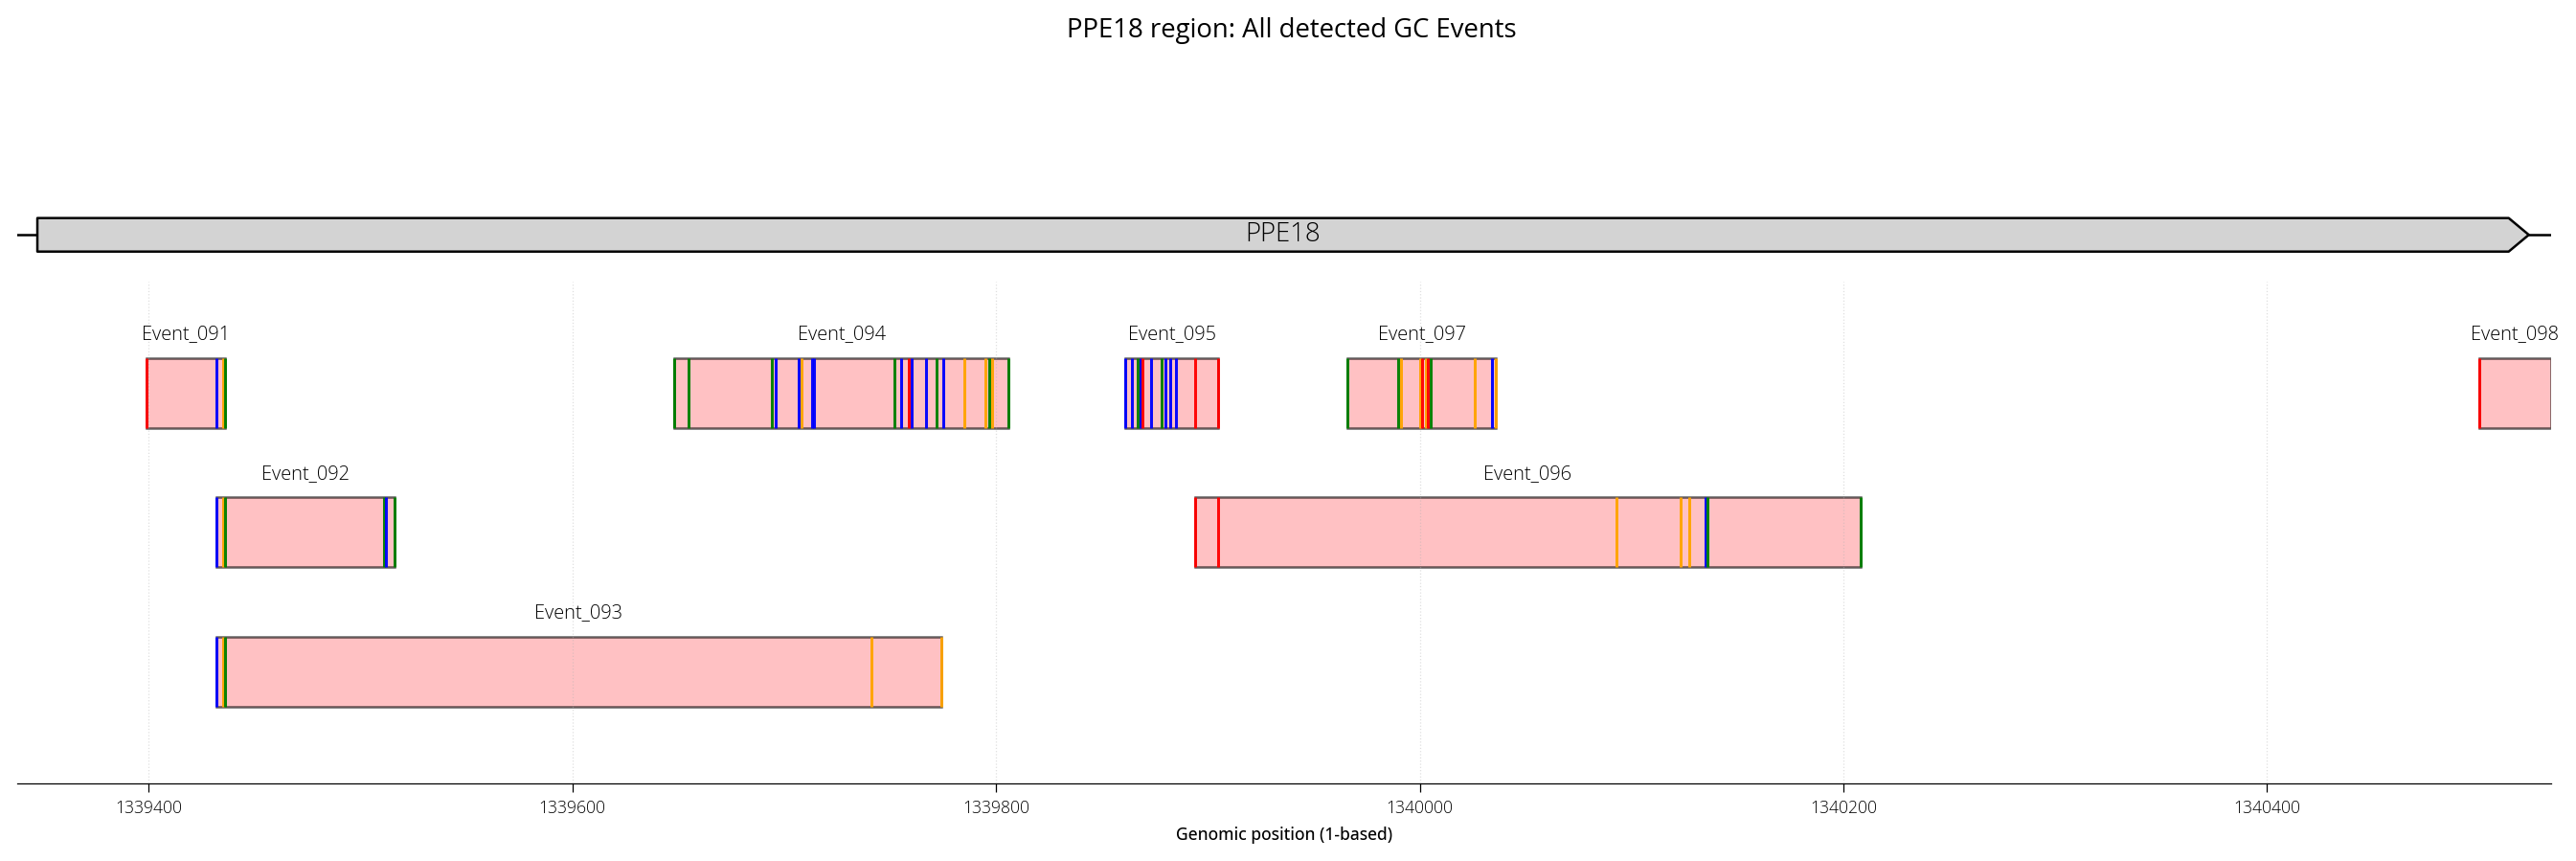

In [138]:
i_Symbol = "PPE18"

print(i_Symbol)
    
GeneInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start = GeneInfo_DF["Start"].values[0]
i_End_Start = GeneInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 10 , i_End_Start + 10

print(Viz_Start, Viz_End)

# ------------------------
# Apply to PPE18 (1339338..1340534)
# ------------------------

fig4, ax4, = plot_Anno_with_GCE_V3(Viz_Start = Viz_Start,
                                   Viz_End = Viz_End,
                                   in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
                                   pGCE_df = pGCE_DF,
                                   snps_df = Gub_SNPs_V2_DF,
                                   title = f"{i_Symbol} region: All detected GC Events",
                                  )


# Parse `netMHCpanII` binding preditions for PPE18-Recombinant Sequences

### Setup Analysis file paths and params

In [139]:
# ---- Setup ---------------------------------------------------------------
from pathlib import Path
import pandas as pd

PPE18_GCE_netMHCpanII_Results_Dir = "../../Data/250910.PPE18.netMHCpanII.PredictionsForRecombinantSeqs"

HLA_Pred_27Allele_Paths = {
    "H37Rv": Path(f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18-H37Rv.netMHCpanII.27AllelePanel.peptide_results.tsv"),
    "Event_091": Path(f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18-Event_091.netMHCpanII.27AllelePanel.peptide_results.tsv"),
    "Event_092": Path(f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18-Event_092.netMHCpanII.27AllelePanel.peptide_results.tsv"),
    "Event_093": Path(f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18-Event_093.netMHCpanII.27AllelePanel.peptide_results.tsv"),
    "Event_094": Path(f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18-Event_094.netMHCpanII.27AllelePanel.peptide_results.tsv"),
    "Event_095": Path(f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18-Event_095.netMHCpanII.27AllelePanel.peptide_results.tsv"),
    "Event_096": Path(f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18-Event_096.netMHCpanII.27AllelePanel.peptide_results.tsv"),
    "Event_097": Path(f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18-Event_097.netMHCpanII.27AllelePanel.peptide_results.tsv"),
}



## Define sets of HLA-II Alleles of interest

Set 1: Reference panel of 27 alleles used by IEDB. Described on this IEDB info page [here](https://help.iedb.org/hc/en-us/articles/114094151851-HLA-allele-frequencies-and-reference-sets-with-maximal-population-coverage)

Set 2: Reference panel of 7 alleles useb by IEDB. Desscribed in this [paper](https://www.sciencedirect.com/science/article/pii/S0022175915000988) (Paul-2015)

Set 3: AFND (`Allele-Frequency-Net-Database`) Europe-DRB1 7 Common Alleles:         

This page has summary stats regarding the most common `DRB1` HLA alleles found in Europe: http://www.allelefrequencies.net/top10freqs.asp






**Set 1: IEDB Reference Panel (27 alleles)**  
Defined by IEDB to maximize global population coverage.  
See details on the [IEDB info page](https://help.iedb.org/hc/en-us/articles/114094151851-HLA-allele-frequencies-and-reference-sets-with-maximal-population-coverage).

**Set 2: IEDB Reference Panel (7 alleles)**  
A  representative reduced panel used by IEDB.  
Originally described in [Paul et al. 2015](https://www.sciencedirect.com/science/article/pii/S0022175915000988).

**Set 3: AFND Europe DRB1 (7 common alleles)**  
Based on the most common HLA-DRB1 alleles reported in European populations from the  
[Allele Frequency Net Database](http://www.allelefrequencies.net/top10freqs.asp).  


In [140]:
HLA2_IEDB_RefSet_27A = ['HLA-DRB1*01:01', 'HLA-DRB1*03:01', 'HLA-DRB1*04:01',
                        'HLA-DRB1*04:05', 'HLA-DRB1*07:01', 'HLA-DRB1*08:02',
                        'HLA-DRB1*09:01', 'HLA-DRB1*11:01', 'HLA-DRB1*12:01',
                        'HLA-DRB1*13:02', 'HLA-DRB1*15:01', 'HLA-DRB3*01:01',
                        'HLA-DRB3*02:02', 'HLA-DRB4*01:01', 'HLA-DRB5*01:01',
                        'HLA-DPA1*01:03/DPB1*02:01', 'HLA-DPA1*01:03/DPB1*04:01',
                        'HLA-DPA1*02:01/DPB1*01:01', 'HLA-DPA1*02:01/DPB1*05:01',
                        'HLA-DPA1*02:01/DPB1*14:01', 'HLA-DPA1*03:01/DPB1*04:02',
                        'HLA-DQA1*01:01/DQB1*05:01', 'HLA-DQA1*01:02/DQB1*06:02',
                        'HLA-DQA1*03:01/DQB1*03:02', 'HLA-DQA1*04:01/DQB1*04:02',
                        'HLA-DQA1*05:01/DQB1*02:01', 'HLA-DQA1*05:01/DQB1*03:01',
]

HLA2_IEDB_RefSet_7A = ['HLA-DRB1*03:01', 'HLA-DRB1*07:01', 'HLA-DRB1*15:01',
                       'HLA-DRB3*01:01', 'HLA-DRB3*02:02', 'HLA-DRB4*01:01',
                       'HLA-DRB5*01:01']


HLA2_AFN_Euro_Set_7A = ["HLA-DRB1*01:01", "HLA-DRB1*03:01", "HLA-DRB1*04:01",
                        "HLA-DRB1*07:01", "HLA-DRB1*11:01", "HLA-DRB1*13:02",
                        "HLA-DRB1*15:01",]


In [141]:
HLA2_AFN_Euro_Set_7A

['HLA-DRB1*01:01',
 'HLA-DRB1*03:01',
 'HLA-DRB1*04:01',
 'HLA-DRB1*07:01',
 'HLA-DRB1*11:01',
 'HLA-DRB1*13:02',
 'HLA-DRB1*15:01']

In [142]:
HLA2_IEDB_RefSet_27A

['HLA-DRB1*01:01',
 'HLA-DRB1*03:01',
 'HLA-DRB1*04:01',
 'HLA-DRB1*04:05',
 'HLA-DRB1*07:01',
 'HLA-DRB1*08:02',
 'HLA-DRB1*09:01',
 'HLA-DRB1*11:01',
 'HLA-DRB1*12:01',
 'HLA-DRB1*13:02',
 'HLA-DRB1*15:01',
 'HLA-DRB3*01:01',
 'HLA-DRB3*02:02',
 'HLA-DRB4*01:01',
 'HLA-DRB5*01:01',
 'HLA-DPA1*01:03/DPB1*02:01',
 'HLA-DPA1*01:03/DPB1*04:01',
 'HLA-DPA1*02:01/DPB1*01:01',
 'HLA-DPA1*02:01/DPB1*05:01',
 'HLA-DPA1*02:01/DPB1*14:01',
 'HLA-DPA1*03:01/DPB1*04:02',
 'HLA-DQA1*01:01/DQB1*05:01',
 'HLA-DQA1*01:02/DQB1*06:02',
 'HLA-DQA1*03:01/DQB1*03:02',
 'HLA-DQA1*04:01/DQB1*04:02',
 'HLA-DQA1*05:01/DQB1*02:01',
 'HLA-DQA1*05:01/DQB1*03:01']

# Begin Data Processing - Parse `netMHCpanII` predictions on distinct PPE18 protein sequences

## Parse netMHCpanII predictions for `IEDB 27` HLA Alleles

In [143]:
ResultsDict_IEDB_27A = {}

for name, peptide_preds_path in HLA_Pred_27Allele_Paths.items():
    
    AllPeptidePreds_df = load_netmhcpanii_peptides(peptide_preds_path,
                                                   target_alleles = HLA2_IEDB_RefSet_27A)
    
    ResultsDict_IEDB_27A[name] = summarize_netmhcpan_peptides_df(AllPeptidePreds_df)

    if name != 'H37Rv':
        
        ResultsDict_IEDB_27A[name]["SB_DiffToRef_PerPos"] = build_sb_diff_per_pos(ResultsDict_IEDB_27A, name)

        PerAllelePerPos_Pivot_Diff_DF = ResultsDict_IEDB_27A[name]["pivot"]  - ResultsDict_IEDB_27A['H37Rv']["pivot"]

        ResultsDict_IEDB_27A[name]["SB_DiffToRef_Pivot_DF"] = PerAllelePerPos_Pivot_Diff_DF

## Parse netMHCpanII predictions for `AFN-EURO 7` HLA Alleles

In [144]:
ResultsDict_AFN_EURO_7A = {}

for name, peptide_preds_path in HLA_Pred_27Allele_Paths.items():
    
    AllPeptidePreds_df = load_netmhcpanii_peptides(peptide_preds_path,
                                                   target_alleles = HLA2_AFN_Euro_Set_7A)
    
    ResultsDict_AFN_EURO_7A[name] = summarize_netmhcpan_peptides_df(AllPeptidePreds_df)

    if name != 'H37Rv':
        
        ResultsDict_AFN_EURO_7A[name]["SB_DiffToRef_PerPos"] = build_sb_diff_per_pos(ResultsDict_AFN_EURO_7A, name)

        PerAllelePerPos_Pivot_Diff_DF = ResultsDict_AFN_EURO_7A[name]["pivot"]  - ResultsDict_AFN_EURO_7A['H37Rv']["pivot"]

        ResultsDict_AFN_EURO_7A[name]["SB_DiffToRef_Pivot_DF"] = PerAllelePerPos_Pivot_Diff_DF

## Summarize results per allele and per event 

In [145]:
SB_Changes_PerAlleleEvent_IEDB_27A_DF, SB_Changes_PerEvent_Totals_IEDB_27A_DF = summarize_sb_changes_with_direction(ResultsDict_IEDB_27A)

In [146]:
SB_Changes_PerAlleleEvent_AFNEURO_7A_DF, SB_Changes_PerEvent_Totals_AFNEURO_7A_DF = summarize_sb_changes_with_direction(ResultsDict_AFN_EURO_7A)

In [147]:
SB_Changes_PerAlleleEvent_IEDB_27A_DF.head(3)

,event_id,allele,gains_Not_to_SB,losses_SB_to_Not,positions_different,net_gains_minus_losses,direction
0,Event_091,HLA-DPA1*01:03/DPB1*02:01,0,0,0,0,no change
1,Event_091,HLA-DPA1*01:03/DPB1*04:01,0,0,0,0,no change
2,Event_091,HLA-DPA1*02:01/DPB1*01:01,0,0,0,0,no change


In [148]:
SB_Changes_PerAlleleEvent_IEDB_27A_DF["allele"].nunique()

27

In [149]:
ResultsDict_IEDB_27A['H37Rv']["raw"]["allele"].nunique()

27

In [150]:
ResultsDict_IEDB_27A['Event_091']["raw"]["allele"].nunique()

27

In [151]:
ResultsDict_IEDB_27A['Event_091']["raw"]["allele"].nunique()

27

In [152]:
AllPeptidePreds_df["allele"].nunique()

7

In [153]:
ResultsDict_IEDB_27A.keys() # .head(3)

dict_keys(['H37Rv', 'Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097'])

In [154]:
ResultsDict_IEDB_27A['H37Rv'].keys() # .head(3)

dict_keys(['raw', 'collapsed', 'pivot', 'sum'])

In [155]:
ResultsDict_IEDB_27A['H37Rv']["raw"].head(3)

,seq #,peptide,start,end,peptide length,allele,peptide index,median binding percentile,netmhciipan_el core,netmhciipan_el score,netmhciipan_el percentile,is_SB,SB_Int
0,1,MVDFGALPPEINSAR,1,15,15,HLA-DPA1*01:03/DPB1*02:01,1,36.0,FGALPPEIN,0.018260,36.0,False,0
1,1,MVDFGALPPEINSAR,1,15,15,HLA-DPA1*01:03/DPB1*04:01,1,27.0,FGALPPEIN,0.008851,27.0,False,0
2,1,MVDFGALPPEINSAR,1,15,15,HLA-DPA1*02:01/DPB1*01:01,1,27.0,FGALPPEIN,0.030311,27.0,False,0


In [156]:
ResultsDict_IEDB_27A.keys()

dict_keys(['H37Rv', 'Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097'])

In [157]:
# Quick peek:
SB_Changes_PerEvent_Totals_IEDB_27A_DF.sort_values("event_id")

,event_id,gains_Not_to_SB,losses_SB_to_Not,positions_different,net_gains_minus_losses,direction
0,Event_091,0,0,0,0,no change
1,Event_092,1,0,1,1,only gains
2,Event_093,0,0,0,0,no change
3,Event_094,26,15,41,11,mixed
4,Event_095,11,3,14,8,mixed
5,Event_096,4,3,7,1,mixed
6,Event_097,3,0,3,3,only gains


In [158]:
# Quick peek:
SB_Changes_PerEvent_Totals_AFNEURO_7A_DF.sort_values("event_id")

,event_id,gains_Not_to_SB,losses_SB_to_Not,positions_different,net_gains_minus_losses,direction
0,Event_091,0,0,0,0,no change
1,Event_092,0,0,0,0,no change
2,Event_093,0,0,0,0,no change
3,Event_094,10,4,14,6,mixed
4,Event_095,3,0,3,3,only gains
5,Event_096,2,0,2,2,only gains
6,Event_097,1,0,1,1,only gains


In [159]:
SB_Changes_PerEvent_Totals_AFNEURO_7A_DF["direction"].value_counts()

direction
no change      3
only gains     3
mixed          1
only losses    0
Name: count, dtype: int64

In [160]:
ResultsDict_IEDB_27A["H37Rv"].keys() #.head()

dict_keys(['raw', 'collapsed', 'pivot', 'sum'])

In [161]:
ResultsDict_AFN_EURO_7A["H37Rv"].keys() #.head()

dict_keys(['raw', 'collapsed', 'pivot', 'sum'])

In [162]:
ResultsDict_AFN_EURO_7A["H37Rv"]['collapsed'].query("allele == 'HLA-DRB1*11:01' & SB_Int > 0 ").head(4)

,allele,start,SB_Int


In [163]:
ResultsDict_IEDB_27A["H37Rv"]['collapsed'].query("allele == 'HLA-DRB1*11:01' & SB_Int > 0 ").head(4)

,allele,start,SB_Int


In [164]:
ResultsDict_AFN_EURO_7A["H37Rv"]['collapsed'].query("allele == 'HLA-DRB1*15:01' & SB_Int > 0 ").head(4)

,allele,start,SB_Int


In [165]:
ResultsDict_IEDB_27A["H37Rv"]['collapsed'].query("allele == 'HLA-DRB1*15:01' & SB_Int > 0 ").head(4)

,allele,start,SB_Int


In [166]:
ResultsDict_AFN_EURO_7A["H37Rv"]['collapsed'].query("SB_Int > 0 ").head(4)

,allele,start,SB_Int
93,HLA-DRB1*01:01,94,1
94,HLA-DRB1*01:01,95,1
150,HLA-DRB1*01:01,151,1
263,HLA-DRB1*01:01,264,1


In [167]:
ResultsDict_AFN_EURO_7A["H37Rv"]['collapsed'].query("allele == 'HLA-DRB1*15:01' & SB_Int > 0 ").head(4)

,allele,start,SB_Int


In [168]:
ResultsDict_IEDB_27A["H37Rv"]['collapsed'].query("allele == 'HLA-DRB1*15:01' & SB_Int > 0 ").head(4)

,allele,start,SB_Int


In [169]:
SB_Changes_PerAlleleEvent_IEDB_27A_DF.query("allele == 'HLA-DRB1*11:01' ") 

,event_id,allele,gains_Not_to_SB,losses_SB_to_Not,positions_different,net_gains_minus_losses,direction
19,Event_091,HLA-DRB1*11:01,0,0,0,0,no change
46,Event_092,HLA-DRB1*11:01,0,0,0,0,no change
73,Event_093,HLA-DRB1*11:01,0,0,0,0,no change
100,Event_094,HLA-DRB1*11:01,2,0,2,2,only gains
127,Event_095,HLA-DRB1*11:01,0,0,0,0,no change
154,Event_096,HLA-DRB1*11:01,1,0,1,1,only gains
181,Event_097,HLA-DRB1*11:01,1,0,1,1,only gains


In [170]:
SB_Changes_PerAlleleEvent_AFNEURO_7A_DF.query("allele == 'HLA-DRB1*11:01' ") 

,event_id,allele,gains_Not_to_SB,losses_SB_to_Not,positions_different,net_gains_minus_losses,direction
4,Event_091,HLA-DRB1*11:01,0,0,0,0,no change
11,Event_092,HLA-DRB1*11:01,0,0,0,0,no change
18,Event_093,HLA-DRB1*11:01,0,0,0,0,no change
25,Event_094,HLA-DRB1*11:01,2,0,2,2,only gains
32,Event_095,HLA-DRB1*11:01,0,0,0,0,no change
39,Event_096,HLA-DRB1*11:01,1,0,1,1,only gains
46,Event_097,HLA-DRB1*11:01,1,0,1,1,only gains


In [171]:
#SB_Changes_PerAlleleEvent_AFNEURO_7A_DF.head(10)

In [172]:
#SB_Changes_PerAlleleEvent_IEDB_27A_DF.head(10)

In [173]:
SB_Changes_PerEvent_Totals_IEDB_27A_DF["gains_Not_to_SB"].sum()

45

In [174]:
SB_Changes_PerEvent_Totals_IEDB_27A_DF["losses_SB_to_Not"].sum()

21

In [175]:
SB_Changes_PerEvent_Totals_IEDB_27A_DF["positions_different"].sum()

66

In [176]:
SB_Changes_PerEvent_Totals_IEDB_27A_DF.head()

,event_id,gains_Not_to_SB,losses_SB_to_Not,positions_different,net_gains_minus_losses,direction
0,Event_091,0,0,0,0,no change
1,Event_092,1,0,1,1,only gains
2,Event_093,0,0,0,0,no change
3,Event_094,26,15,41,11,mixed
4,Event_095,11,3,14,8,mixed


In [177]:
SB_Changes_PerEvent_Totals_AFNEURO_7A_DF["gains_Not_to_SB"].sum()

16

In [178]:
SB_Changes_PerEvent_Totals_AFNEURO_7A_DF["losses_SB_to_Not"].sum()

4

In [179]:
SB_Changes_PerEvent_Totals_AFNEURO_7A_DF["positions_different"].sum()

20

In [180]:
SB_Changes_PerEvent_Totals_AFNEURO_7A_DF.head()

,event_id,gains_Not_to_SB,losses_SB_to_Not,positions_different,net_gains_minus_losses,direction
0,Event_091,0,0,0,0,no change
1,Event_092,0,0,0,0,no change
2,Event_093,0,0,0,0,no change
3,Event_094,10,4,14,6,mixed
4,Event_095,3,0,3,3,only gains


## Output HLA-Epitope Binding Predictons Results (As TSVs)

In [181]:
PPE18_GCE_netMHCpanII_Results_Dir = "../../Data/250910.PPE18.netMHCpanII.PredictionsForRecombinantSeqs"

PPE18_GCE_BindPred_PerEvent_PerAllele_27A_TSV = f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18.EpitopeBindingPredictions.SummaryStats.PerEvent.PerAllele.27A.All.tsv"
#PPE18_GCE_BindPred_PerEvent_PerAllele_7A_TSV  = f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18.EpitopeBindingPredictions.SummaryStats.PerEvent.PerAllele.7A.EuroAlleles.tsv"

PPE18_GCE_BindPred_PerEvent_SumAcrossAllele_27A_TSV = f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18.EpitopeBindingPredictions.SummaryStats.PerEvent.SumAcrossAlleles.27A.All.tsv"
PPE18_GCE_BindPred_PerEvent_SumAcrossAllele_7A_TSV  = f"{PPE18_GCE_netMHCpanII_Results_Dir}/PPE18.EpitopeBindingPredictions.SummaryStats.PerEvent.SumAcrossAlleles.7A.EuroAlleles.tsv"


In [182]:
SB_Changes_PerAlleleEvent_IEDB_27A_DF.to_csv(PPE18_GCE_BindPred_PerEvent_PerAllele_27A_TSV,
                                             sep = "\t", index=False)

In [183]:
SB_Changes_PerEvent_Totals_IEDB_27A_DF.to_csv(PPE18_GCE_BindPred_PerEvent_SumAcrossAllele_27A_TSV,
                                              sep = "\t", index=False)

In [184]:
SB_Changes_PerEvent_Totals_AFNEURO_7A_DF.to_csv(PPE18_GCE_BindPred_PerEvent_SumAcrossAllele_7A_TSV,
                                                sep = "\t", index=False)

In [185]:
!wc -l $PPE18_GCE_BindPred_PerEvent_PerAllele_27A_TSV

190 ../../Data/250910.PPE18.netMHCpanII.PredictionsForRecombinantSeqs/PPE18.EpitopeBindingPredictions.SummaryStats.PerEvent.PerAllele.27A.All.tsv


In [186]:
!wc -l $PPE18_GCE_BindPred_PerEvent_SumAcrossAllele_27A_TSV

8 ../../Data/250910.PPE18.netMHCpanII.PredictionsForRecombinantSeqs/PPE18.EpitopeBindingPredictions.SummaryStats.PerEvent.SumAcrossAlleles.27A.All.tsv


In [187]:
!wc -l $PPE18_GCE_BindPred_PerEvent_SumAcrossAllele_7A_TSV

8 ../../Data/250910.PPE18.netMHCpanII.PredictionsForRecombinantSeqs/PPE18.EpitopeBindingPredictions.SummaryStats.PerEvent.SumAcrossAlleles.7A.EuroAlleles.tsv


In [188]:
!head -n 3 $PPE18_GCE_BindPred_PerEvent_SumAcrossAllele_27A_TSV

event_id	gains_Not_to_SB	losses_SB_to_Not	positions_different	net_gains_minus_losses	direction
Event_091	0	0	0	0	no change
Event_092	1	0	1	1	only gains


In [189]:
!head -n 3 $PPE18_GCE_BindPred_PerEvent_SumAcrossAllele_7A_TSV

event_id	gains_Not_to_SB	losses_SB_to_Not	positions_different	net_gains_minus_losses	direction
Event_091	0	0	0	0	no change
Event_092	0	0	0	0	no change


In [190]:
!ls -lah $PPE18_GCE_netMHCpanII_Results_Dir

total 7.6M
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Jan 13  2026 .
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Aug  8 22:32 ..
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Sep 12  2025 .ipynb_checkpoints
-rw-r--r-- 1 mm774 hpc_farhat 9.0K Sep 16 13:45 PPE18.EpitopeBindingPredictions.SummaryStats.PerEvent.PerAllele.27A.All.tsv
-rw-r--r-- 1 mm774 hpc_farhat  287 Sep 16 13:45 PPE18.EpitopeBindingPredictions.SummaryStats.PerEvent.SumAcrossAlleles.27A.All.tsv
-rw-r--r-- 1 mm774 hpc_farhat  292 Sep 16 13:45 PPE18.EpitopeBindingPredictions.SummaryStats.PerEvent.SumAcrossAlleles.7A.EuroAlleles.tsv
-rw-r--r-- 1 mm774 hpc_farhat  432 Jun 15 17:24 PPE18.Event_091.GCE_AASeq.faa
-rw-r--r-- 1 mm774 hpc_farhat 778K Sep 12  2025 PPE18-Event_091.netMHCpanII.27AllelePanel.peptide_results.tsv
-rw-r--r-- 1 mm774 hpc_farhat 189K Sep 10  2025 PPE18-Event_091.netMHCpanII.7AllelePanel.peptide_results.tsv
-rw-r--r-- 1 mm774 hpc_farhat  432 Sep 10  2025 PPE18.Event_092.GCE_AASeq.faa
-rw-r--r-- 1 mm774 hpc_farhat 778K Sep 12  2025 PPE18

In [191]:
SB_Changes_PerAlleleEvent_IEDB_27A_DF.shape

(189, 7)

In [192]:
SB_Changes_PerEvent_Totals_IEDB_27A_DF.shape

(7, 6)

In [193]:
SB_Changes_PerEvent_Totals_AFNEURO_7A_DF.shape

(7, 6)

## Viz general trends in predicted binding before/after Gene Conversion Event mutation in PPE18

### Change in Strong Binders after GCE - `IEDB 27` HLA Alleles

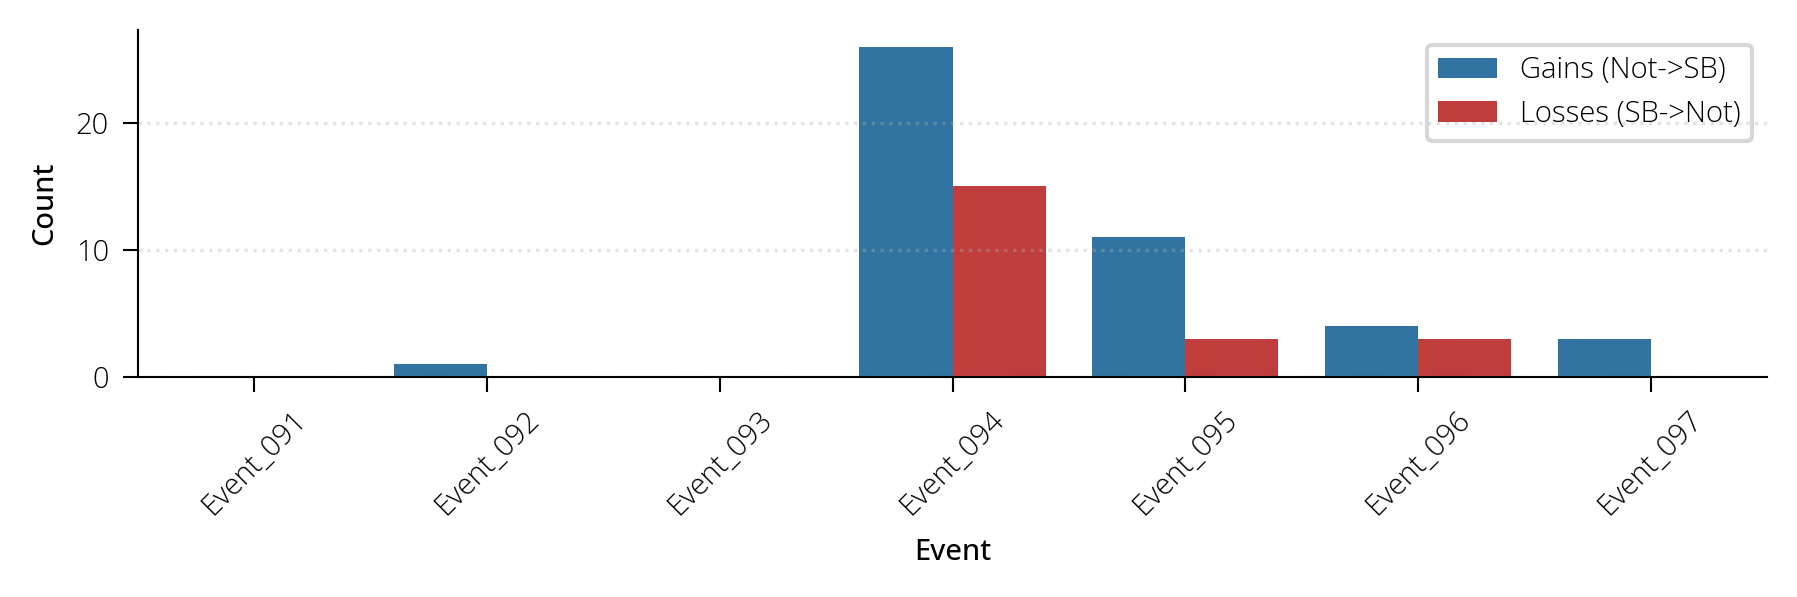

In [194]:
_ = plot_SB_changes(SB_Changes_PerEvent_Totals_IEDB_27A_DF)

### Change in Strong Binders after GCE - `AFN-EURO 7` HLA Alleles

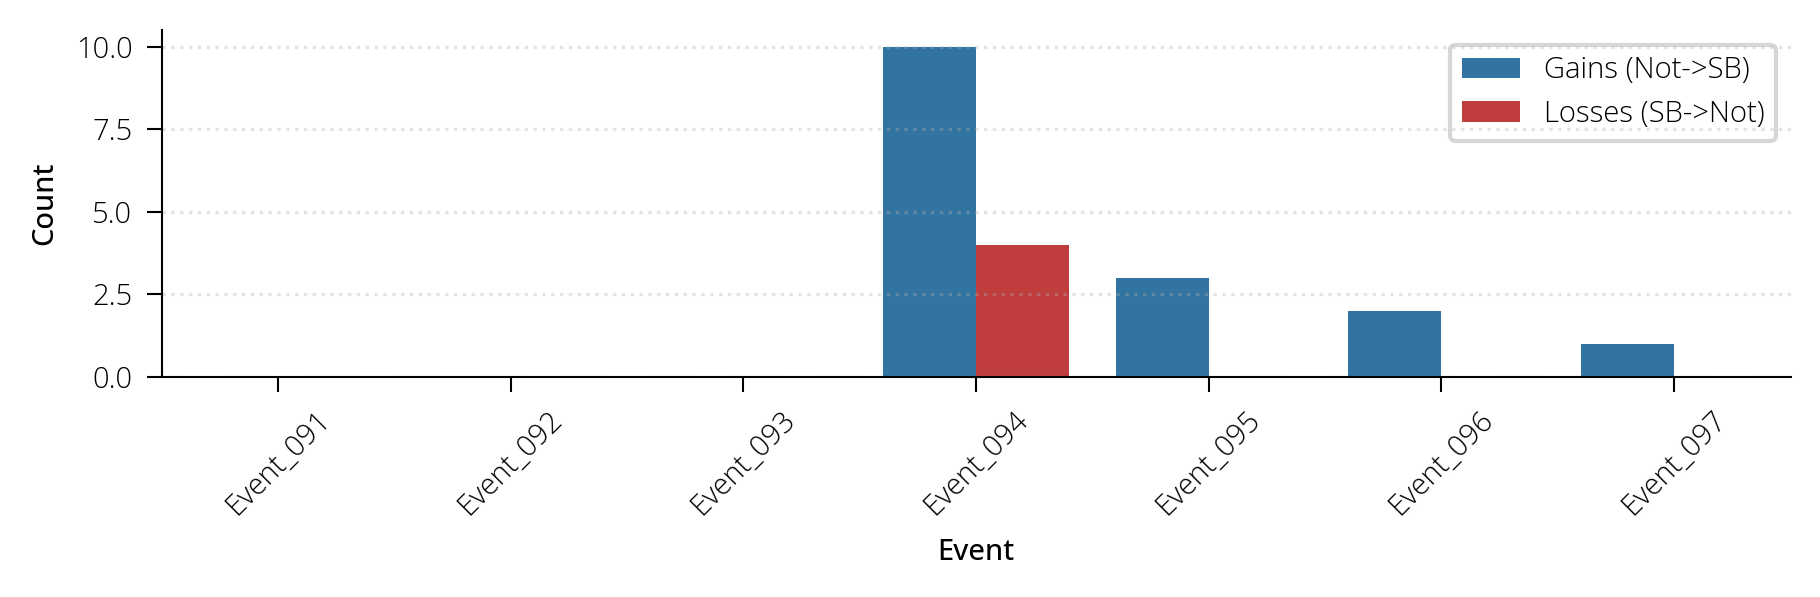

In [195]:
_ = plot_SB_changes(SB_Changes_PerEvent_Totals_AFNEURO_7A_DF)

## Statistical test to evaluate trend in predicted gain/loss of HLA-binding

In [196]:
# Quick peek at table
SB_Changes_PerEvent_Totals_IEDB_27A_DF.sort_values("event_id")

,event_id,gains_Not_to_SB,losses_SB_to_Not,positions_different,net_gains_minus_losses,direction
0,Event_091,0,0,0,0,no change
1,Event_092,1,0,1,1,only gains
2,Event_093,0,0,0,0,no change
3,Event_094,26,15,41,11,mixed
4,Event_095,11,3,14,8,mixed
5,Event_096,4,3,7,1,mixed
6,Event_097,3,0,3,3,only gains


In [197]:

# Pool binding-status changes across all 7 GCEs (summed over the 27 alleles)
gains  = int(SB_Changes_PerEvent_Totals_IEDB_27A_DF["gains_Not_to_SB"].sum())    # non-SB -> SB
losses = int(SB_Changes_PerEvent_Totals_IEDB_27A_DF["losses_SB_to_Not"].sum())   # SB -> non-SB
n = gains + losses

# Exact binomial test: H0 that gains and losses are equally likely (p0 = 0.5)
res_two = scipy.stats.binomtest(gains, n, p=0.5, alternative="two-sided")
res_one = scipy.stats.binomtest(gains, n, p=0.5, alternative="greater")

print(f"gains = {gains}, losses = {losses}, n = {n}")
print(f"proportion gains = {gains/n:.3f}")
print(f"two-sided p = {res_two.pvalue:.4f}")
print(f"one-sided p = {res_one.pvalue:.4f}")

# GCEs changing binding for at least one allele
n_changed = (SB_Changes_PerEvent_Totals_IEDB_27A_DF["positions_different"] > 0).sum()
print(f"{n_changed} of {len(SB_Changes_PerEvent_Totals_IEDB_27A_DF)} GCEs changed binding for >=1 allele")

gains = 45, losses = 21, n = 66
proportion gains = 0.682
two-sided p = 0.0043
one-sided p = 0.0021
5 of 7 GCEs changed binding for >=1 allele


## Look at HLA Binding Predictions Results-Dictionaries

In [198]:
ResultsDict_IEDB_27A["H37Rv"].keys() #.head()

dict_keys(['raw', 'collapsed', 'pivot', 'sum'])

In [199]:
ResultsDict_AFN_EURO_7A["H37Rv"].keys() #.head()

dict_keys(['raw', 'collapsed', 'pivot', 'sum'])

In [200]:
ResultsDict_AFN_EURO_7A.keys()

dict_keys(['H37Rv', 'Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097'])

In [201]:
ResultsDict_AFN_EURO_7A['H37Rv'].keys()

dict_keys(['raw', 'collapsed', 'pivot', 'sum'])

In [202]:
ResultsDict_AFN_EURO_7A['Event_091'].keys()

dict_keys(['raw', 'collapsed', 'pivot', 'sum', 'SB_DiffToRef_PerPos', 'SB_DiffToRef_Pivot_DF'])

In [203]:
ResultsDict_AFN_EURO_7A['Event_091']['SB_DiffToRef_PerPos'].shape

(377, 4)

In [204]:
ResultsDict_AFN_EURO_7A['Event_091']['SB_DiffToRef_PerPos'].head()

,start,SB_count_EventSeq,SB_count_RefSeq,SB_diff
0,1,0,0,0
1,2,0,0,0
2,3,0,0,0
3,4,0,0,0
4,5,0,0,0


In [205]:
ResultsDict_AFN_EURO_7A['H37Rv']['sum'].keys()

dict_keys(['by_pos', 'by_allele'])

In [206]:
ResultsDict_AFN_EURO_7A['H37Rv']['sum']['by_pos'].head()

,start,SB_count
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [207]:
ResultsDict_AFN_EURO_7A['H37Rv']['sum']['by_allele'].shape

(7, 2)

In [208]:
ResultsDict_AFN_EURO_7A['H37Rv']['sum']['by_allele']

,allele,SB_count
0,HLA-DRB1*01:01,7
1,HLA-DRB1*03:01,0
2,HLA-DRB1*04:01,2
3,HLA-DRB1*07:01,5
4,HLA-DRB1*11:01,0
5,HLA-DRB1*13:02,0
6,HLA-DRB1*15:01,0


In [209]:
ResultsDict_AFN_EURO_7A['H37Rv']['sum']['by_allele']

,allele,SB_count
0,HLA-DRB1*01:01,7
1,HLA-DRB1*03:01,0
2,HLA-DRB1*04:01,2
3,HLA-DRB1*07:01,5
4,HLA-DRB1*11:01,0
5,HLA-DRB1*13:02,0
6,HLA-DRB1*15:01,0


In [210]:
ResultsDict_AFN_EURO_7A['H37Rv']['sum']['by_allele']["allele"].values

array(['HLA-DRB1*01:01', 'HLA-DRB1*03:01', 'HLA-DRB1*04:01',
       'HLA-DRB1*07:01', 'HLA-DRB1*11:01', 'HLA-DRB1*13:02',
       'HLA-DRB1*15:01'], dtype=object)

In [211]:
ResultsDict_AFN_EURO_7A['H37Rv']['sum']['by_allele']["allele"].values

array(['HLA-DRB1*01:01', 'HLA-DRB1*03:01', 'HLA-DRB1*04:01',
       'HLA-DRB1*07:01', 'HLA-DRB1*11:01', 'HLA-DRB1*13:02',
       'HLA-DRB1*15:01'], dtype=object)

In [212]:
#MainResults_Dict['H37Rv']['sum']['by_allele']

In [213]:
ResultsDict_AFN_EURO_7A['H37Rv']["raw"].shape

(2639, 13)

In [214]:
ResultsDict_AFN_EURO_7A['H37Rv']["collapsed"].shape

(2639, 3)

In [215]:
ResultsDict_AFN_EURO_7A['H37Rv']["raw"].head()

,seq #,peptide,start,end,peptide length,allele,peptide index,median binding percentile,netmhciipan_el core,netmhciipan_el score,netmhciipan_el percentile,is_SB,SB_Int
12,1,MVDFGALPPEINSAR,1,15,15,HLA-DRB1*01:01,1,3.3,FGALPPEIN,0.507762,3.3,False,0
13,1,MVDFGALPPEINSAR,1,15,15,HLA-DRB1*03:01,1,87.0,FGALPPEIN,0.000858,87.0,False,0
14,1,MVDFGALPPEINSAR,1,15,15,HLA-DRB1*04:01,1,9.4,FGALPPEIN,0.199981,9.4,False,0
16,1,MVDFGALPPEINSAR,1,15,15,HLA-DRB1*07:01,1,32.0,FGALPPEIN,0.032169,32.0,False,0
19,1,MVDFGALPPEINSAR,1,15,15,HLA-DRB1*11:01,1,18.0,FGALPPEIN,0.073633,18.0,False,0


In [216]:
ResultsDict_AFN_EURO_7A['H37Rv']["pivot"].shape

(7, 377)

In [217]:
ResultsDict_AFN_EURO_7A['H37Rv']["sum"].keys()

dict_keys(['by_pos', 'by_allele'])

In [218]:
ResultsDict_AFN_EURO_7A['H37Rv']["sum"]['by_allele']["allele"].values

array(['HLA-DRB1*01:01', 'HLA-DRB1*03:01', 'HLA-DRB1*04:01',
       'HLA-DRB1*07:01', 'HLA-DRB1*11:01', 'HLA-DRB1*13:02',
       'HLA-DRB1*15:01'], dtype=object)

# Viz and explore baseline predictions for `PPE18`-`H37Rv` - For 7 Allele and 27 Allele Set

In [219]:
ResultsDict_IEDB_27A["H37Rv"].keys() #.head()

dict_keys(['raw', 'collapsed', 'pivot', 'sum'])

In [220]:
ResultsDict_AFN_EURO_7A["H37Rv"].keys() #.head()

dict_keys(['raw', 'collapsed', 'pivot', 'sum'])

In [221]:
# HLA2_AFN_Euro_Set_7A HLA2_IEDB_RefSet_27A

## PPE18 - H37Rv - Baseline HLA-binding predictions - IEDB 27 Allele Set

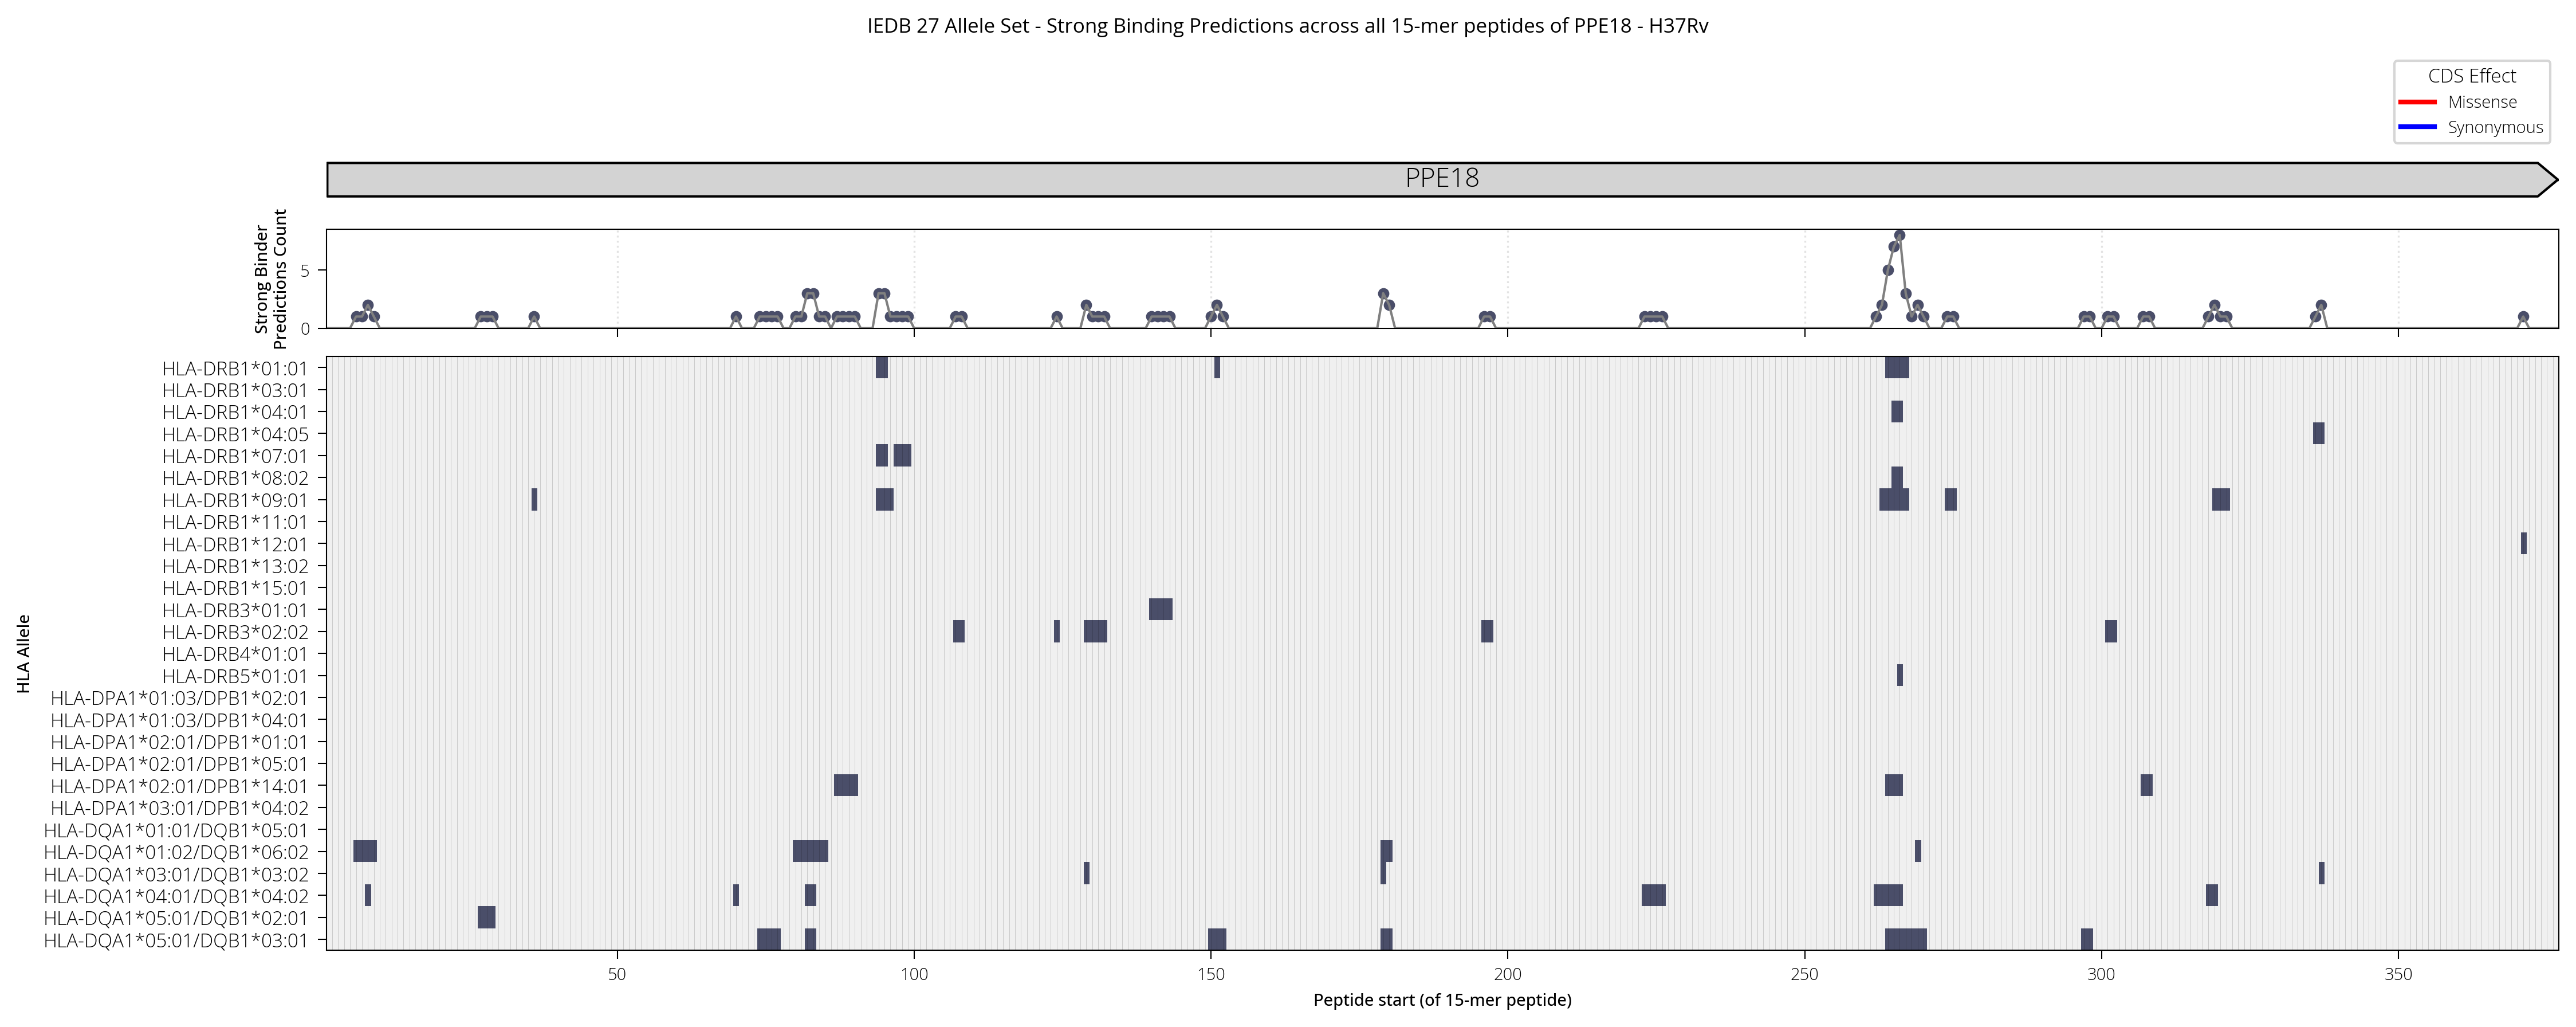

In [222]:
GCE_Vs_HLABind_IEDB27Allele_Baseline_E091_fig = plot_EventWiAnno_WiSBPred_Baseline_3panel(
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    in_EventID = 'H37Rv',
    in_GCEvents_All_DF = pGCE_DF,
    in_Gubbins_SNPs_DF = Gub_SNPs_V2_DF,
    i_MainResults_Dict = ResultsDict_IEDB_27A,
    Viz_Start = PPE18_Viz_Start,
    Viz_End = PPE18_Viz_End,
    in_ylim = (-5, 5),
    show_snp_labels=False,
    i_figsize = (15, 6),
    title = f"IEDB 27 Allele Set - Strong Binding Predictions across all 15-mer peptides of PPE18 - H37Rv",
    allele_order = HLA2_IEDB_RefSet_27A,
)

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1433: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1434: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

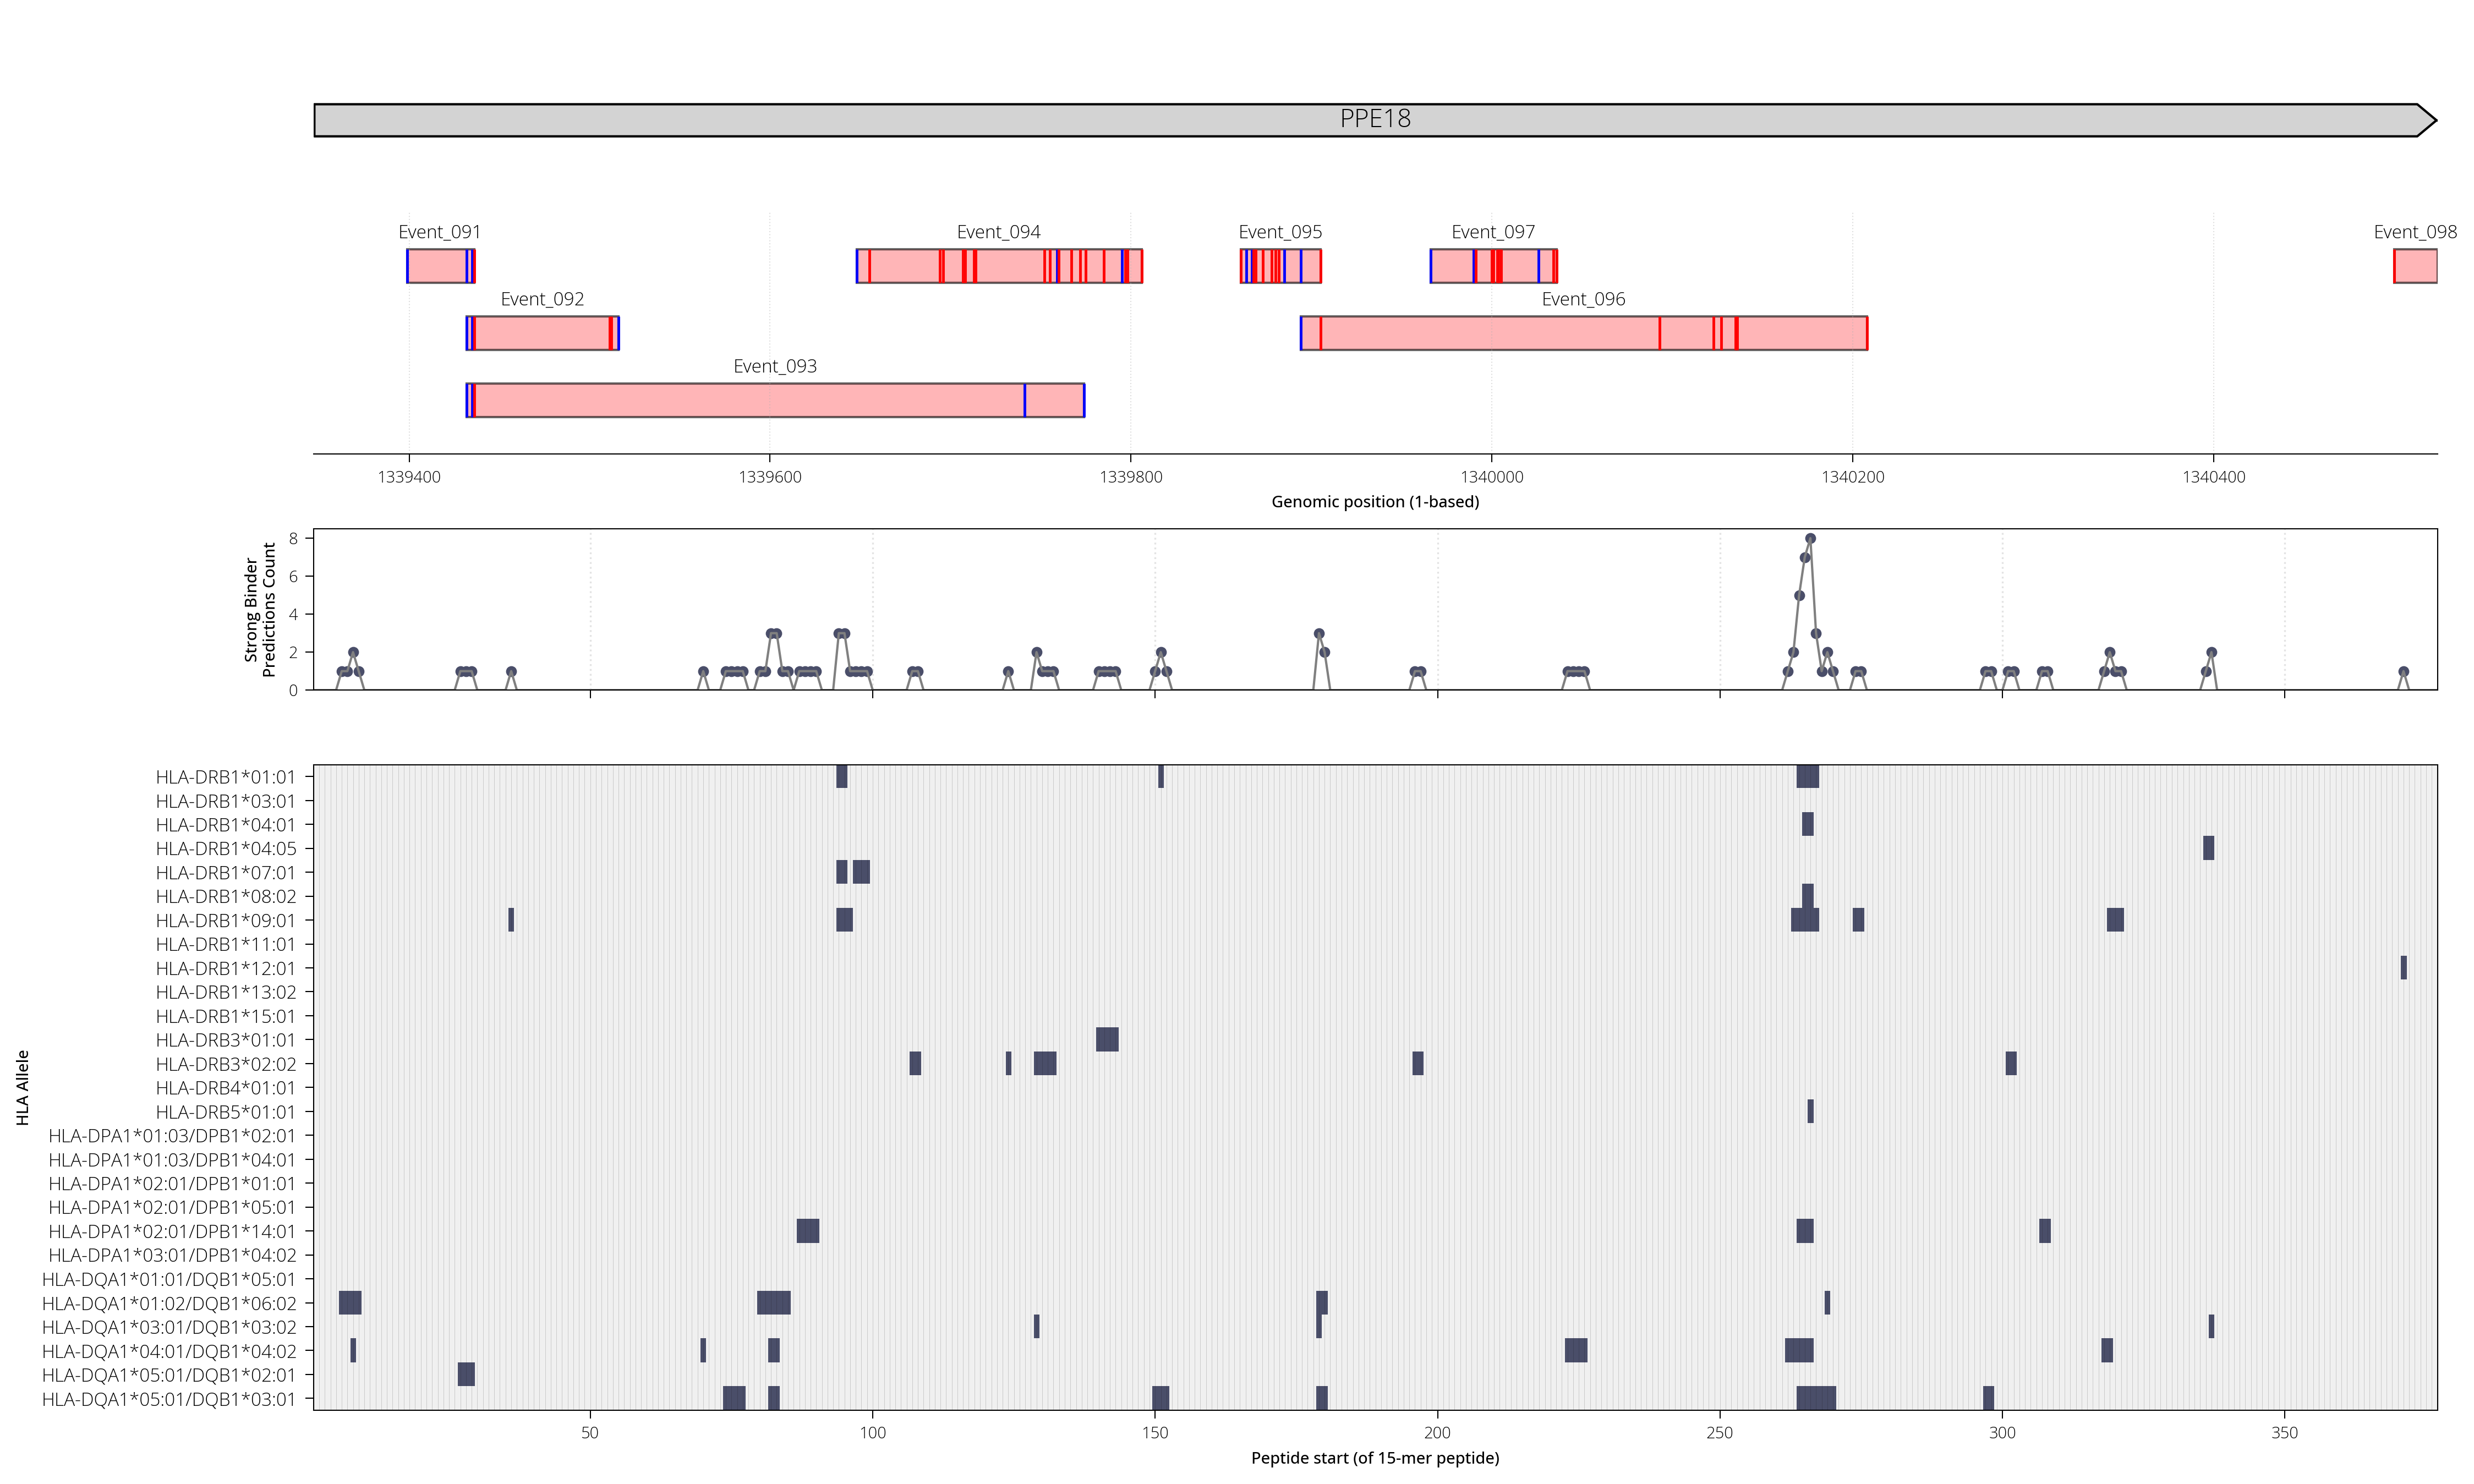

In [223]:
GCE_Vs_HLABind_IEDB27Allele_Baseline_E091_fig = plot_event_WiSBBaseline_4panel(
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    in_EventID = 'H37Rv',
    in_GCEvents_All_DF = pGCE_DF,
    in_Gubbins_SNPs_DF = Gub_SNPs_V2_DF,
    MainResults_Dict = ResultsDict_IEDB_27A,
    Viz_Start = PPE18_Viz_Start,
    Viz_End = PPE18_Viz_End,
    in_ylim = (-5, 5),
    show_snp_labels=False,
    i_figsize = (15, 9),
    fig_heightratios = (1.5, 3, 2, 8),
    title = f"IEDB 27 Allele Set - Strong Binding Predictions across all 15-mer peptides of PPE18 - H37Rv",
    allele_order = HLA2_IEDB_RefSet_27A,
)

## PPE18 - H37Rv - Baseline HLA-binding predictions - AFN-EURO 7 Allele Set

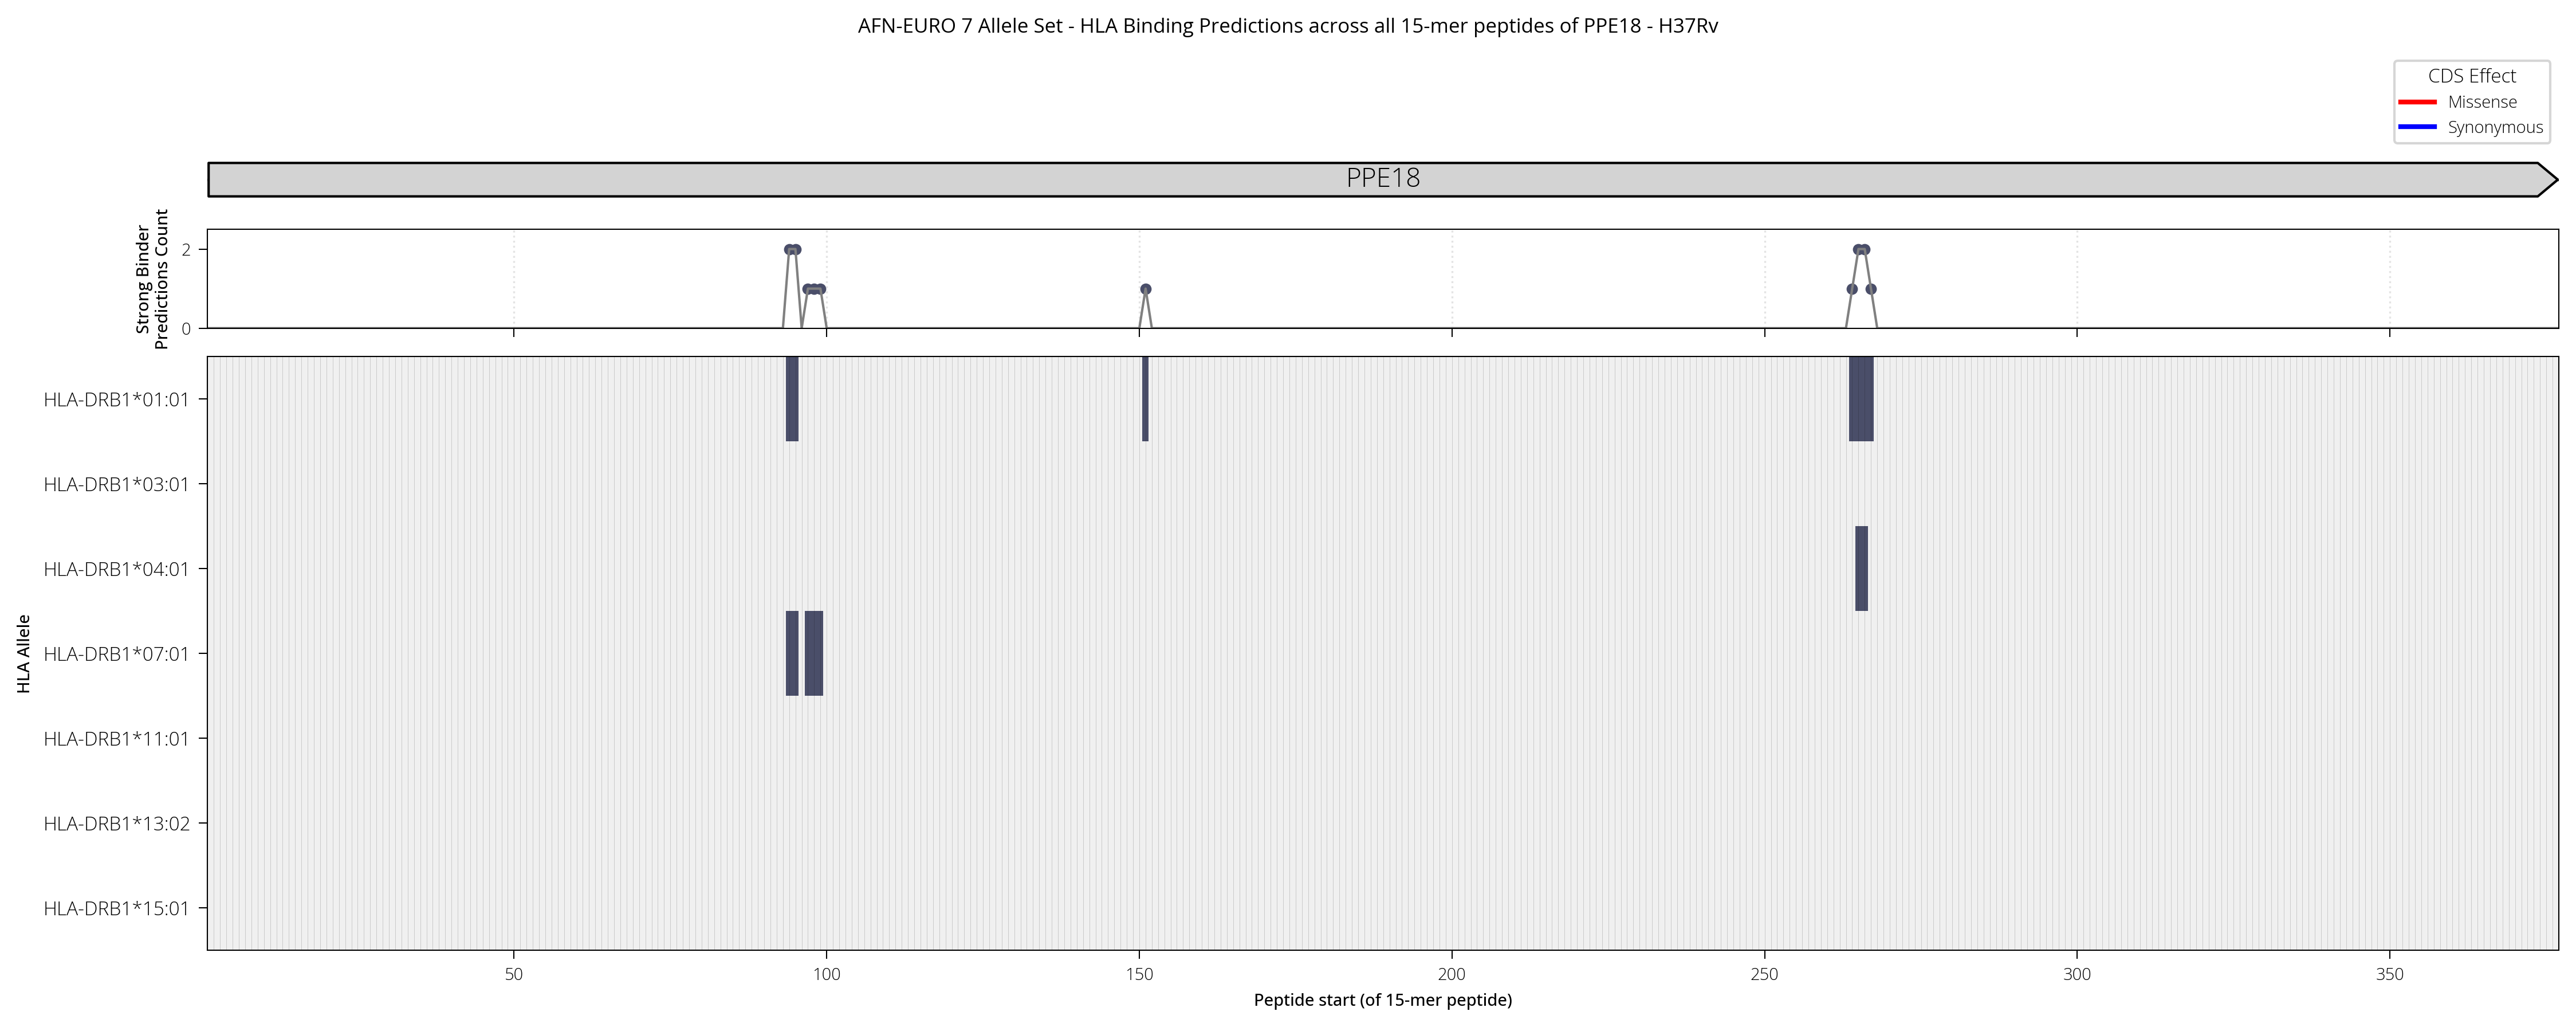

In [224]:

GCE_Vs_HLABind_Euro7Allele_Baseline_E091_fig = plot_EventWiAnno_WiSBPred_Baseline_3panel(
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    in_EventID = 'H37Rv',
    in_GCEvents_All_DF = pGCE_DF,
    in_Gubbins_SNPs_DF = Gub_SNPs_V2_DF,
    i_MainResults_Dict = ResultsDict_AFN_EURO_7A,
    Viz_Start = PPE18_Viz_Start,
    Viz_End = PPE18_Viz_End,
    in_ylim = (-5, 5),
    show_snp_labels=False,
    i_figsize = (15, 6),
    title = f"AFN-EURO 7 Allele Set - HLA Binding Predictions across all 15-mer peptides of PPE18 - H37Rv",
    allele_order = HLA2_AFN_Euro_Set_7A,
)


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1433: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1434: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

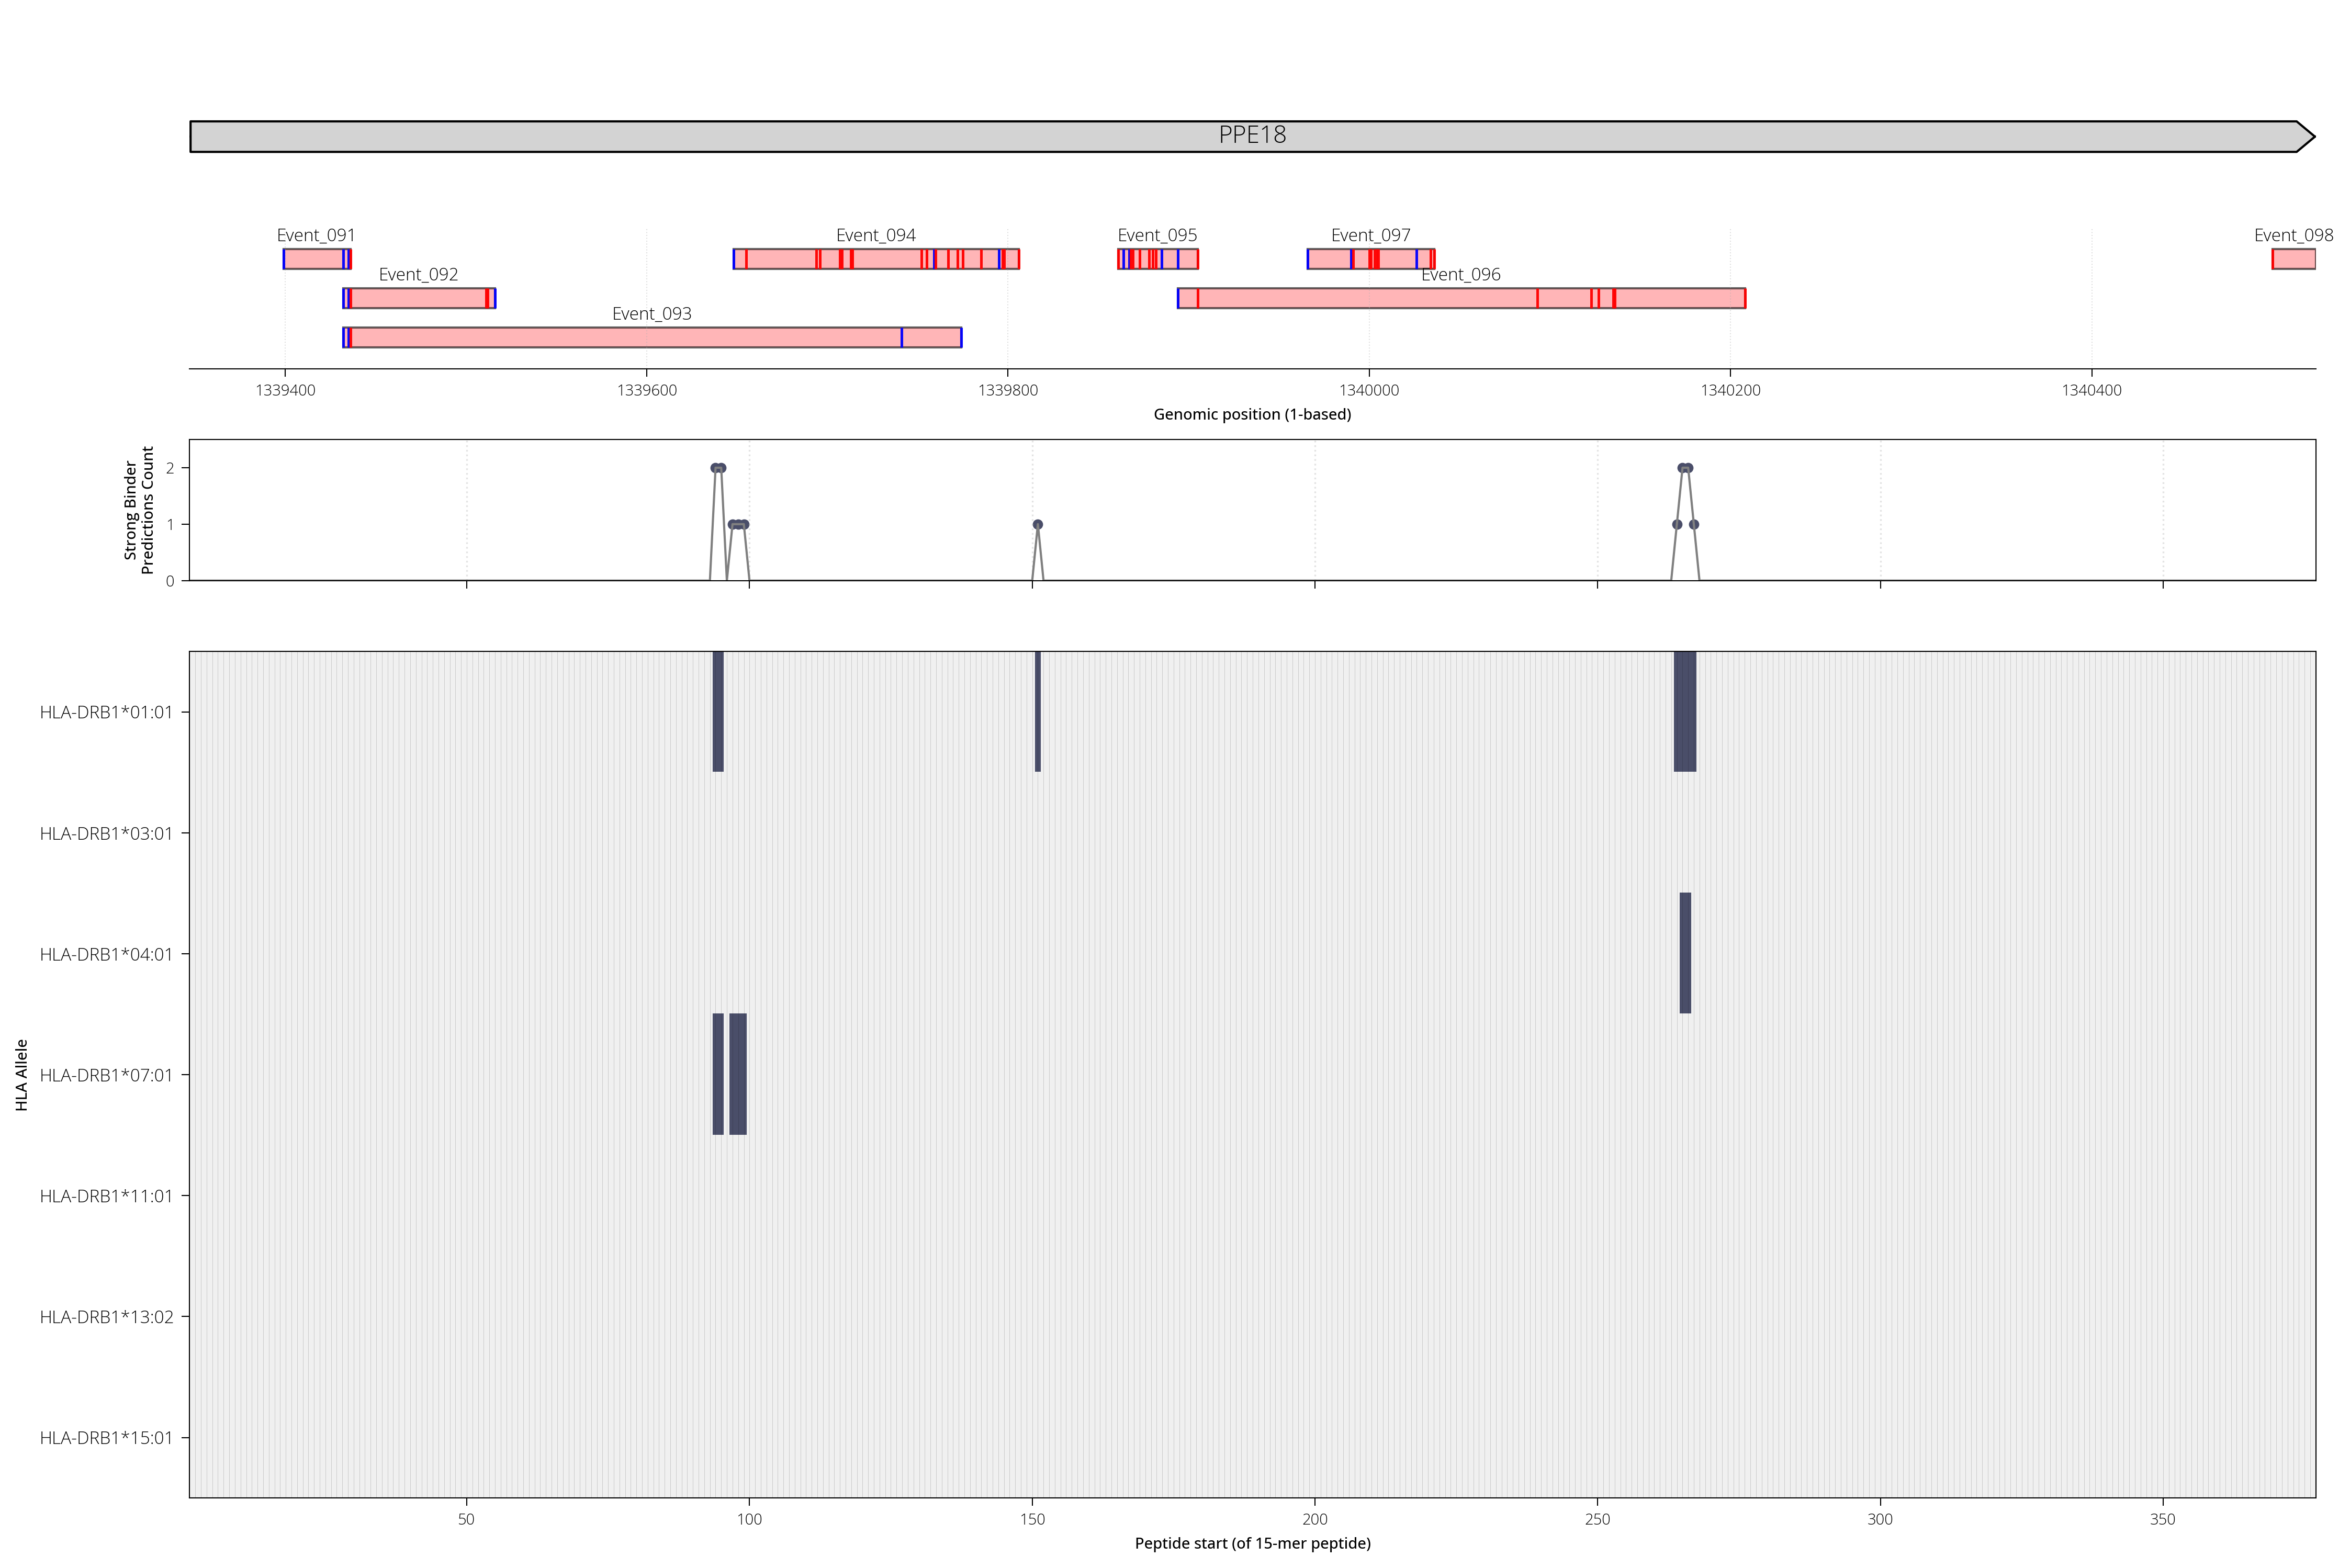

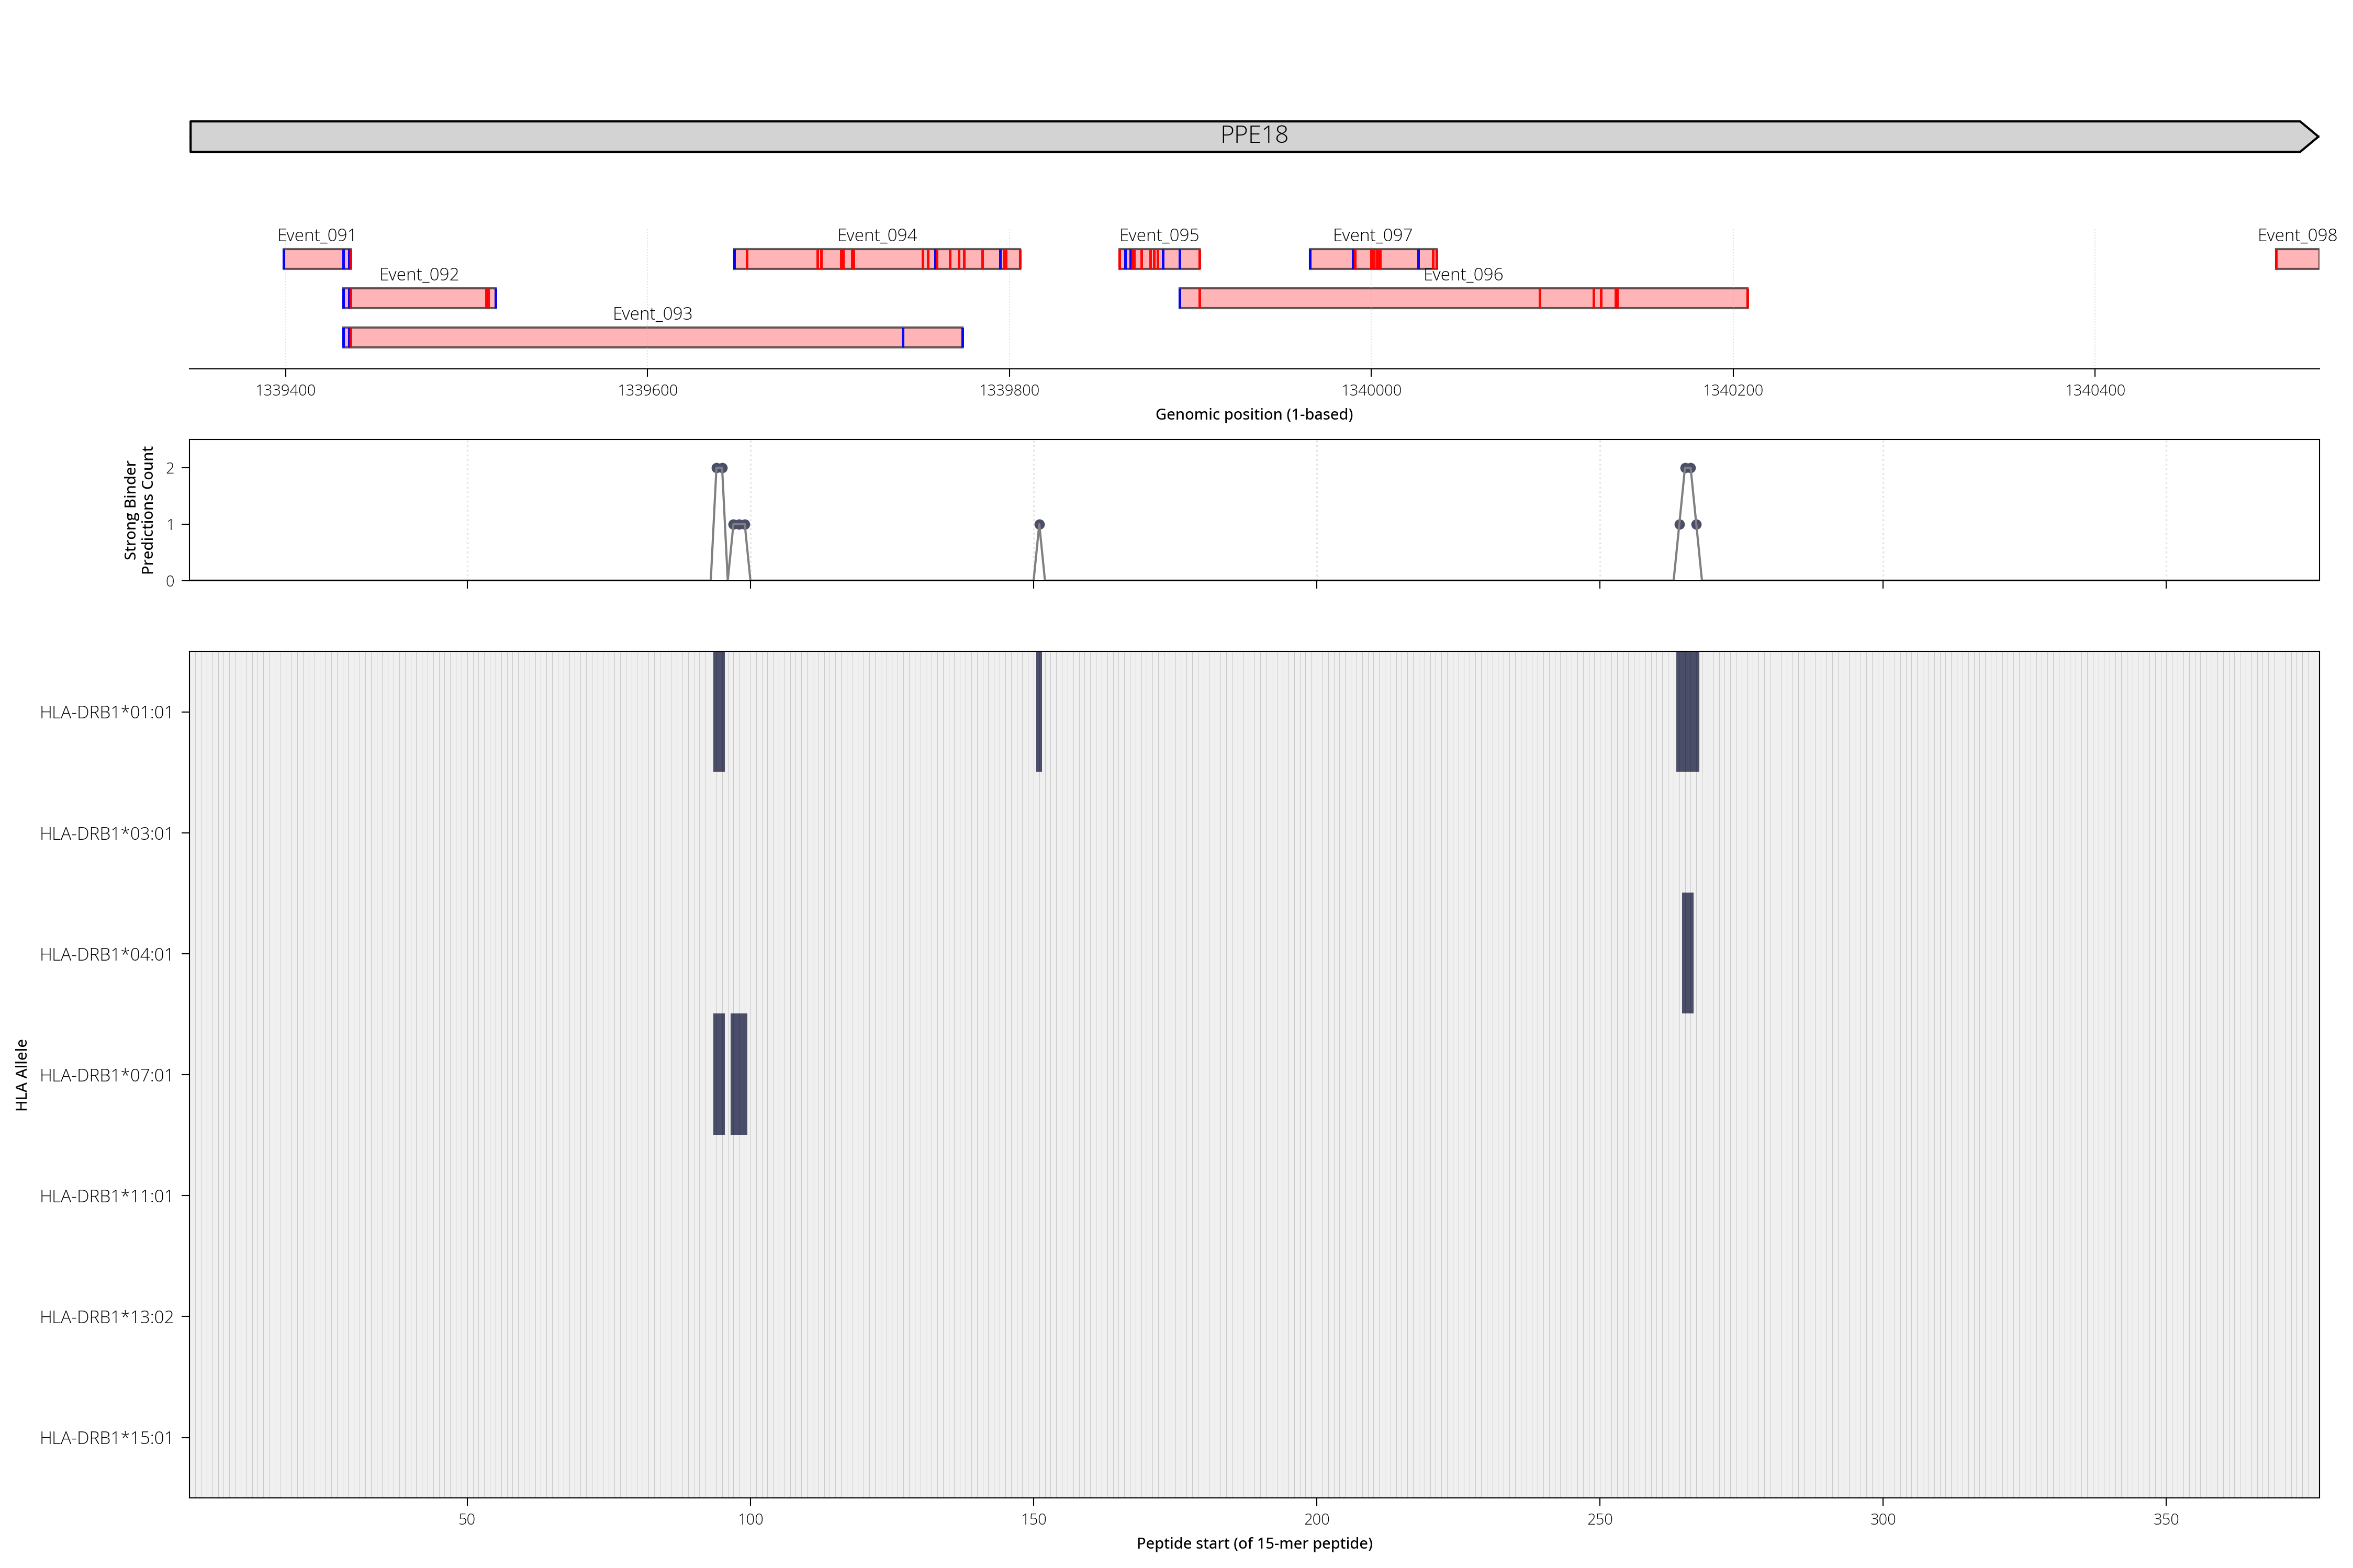

In [225]:
plot_event_WiSBBaseline_4panel(Mtb_H37rv_Graphic_Record,
                               'H37Rv',
                               in_GCEvents_All_DF = pGCE_DF,
                               in_Gubbins_SNPs_DF = Gub_SNPs_V2_DF,
                               MainResults_Dict = ResultsDict_AFN_EURO_7A,
                               Viz_Start = PPE18_Viz_Start,
                               Viz_End = PPE18_Viz_End,
                               in_ylim = (-5, 5),
                               show_snp_labels=False,
                               i_figsize = (15, 10),
                               title = f"AFN-EURO 7 Allele Set - HLA Binding Predictions across all 15-mer peptides of PPE18 - H37Rv",
                               allele_order = HLA2_AFN_Euro_Set_7A,
)

# Viz BASELINE frequency of predicted "Strong Binders" for distinct PPE18 sequences (H37Rv + All GCEs)

### `AFN-EURO 7` HLA Alleles

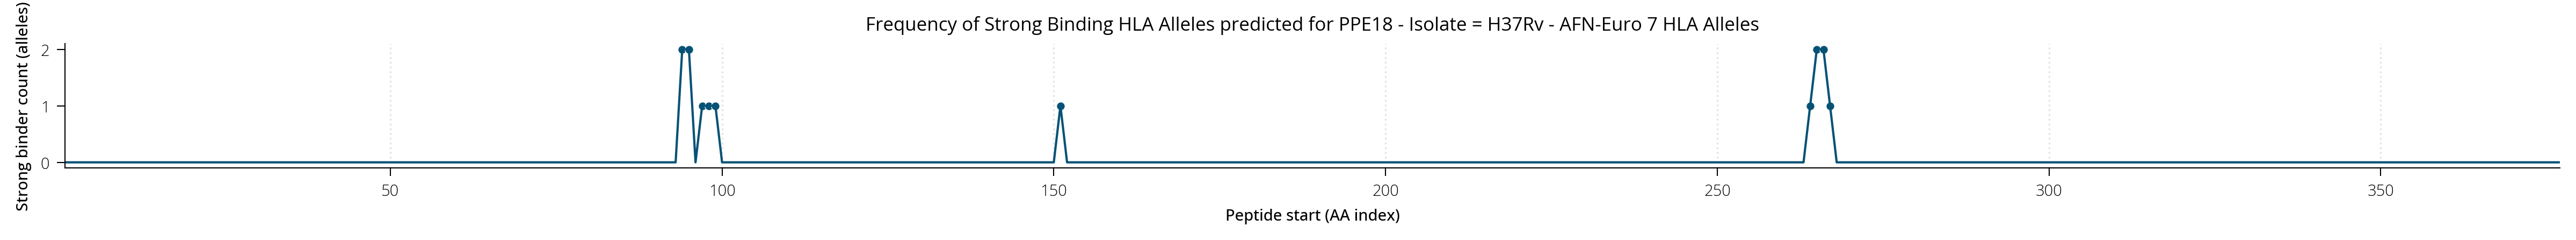

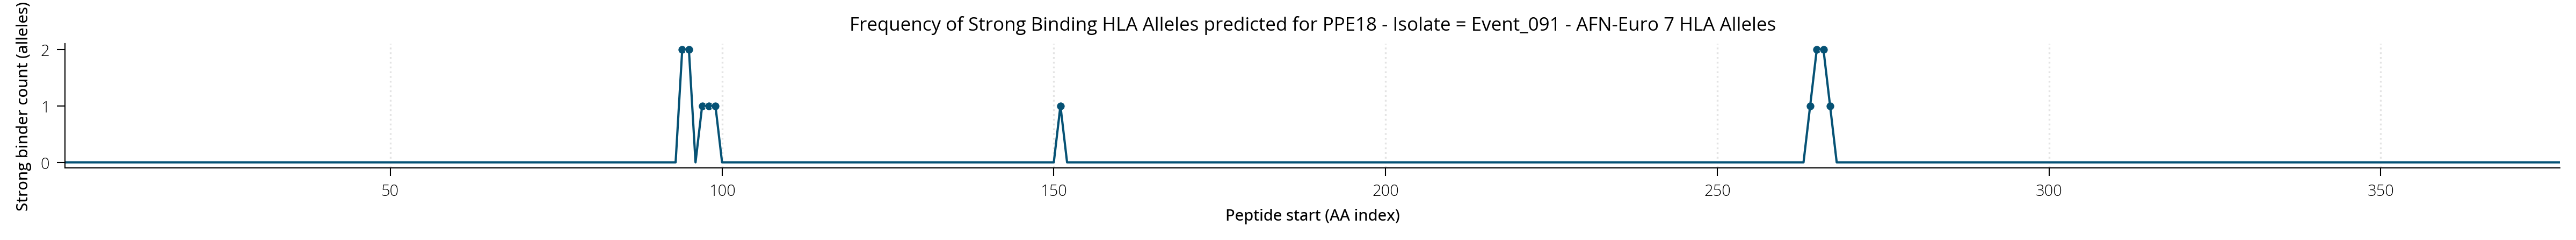

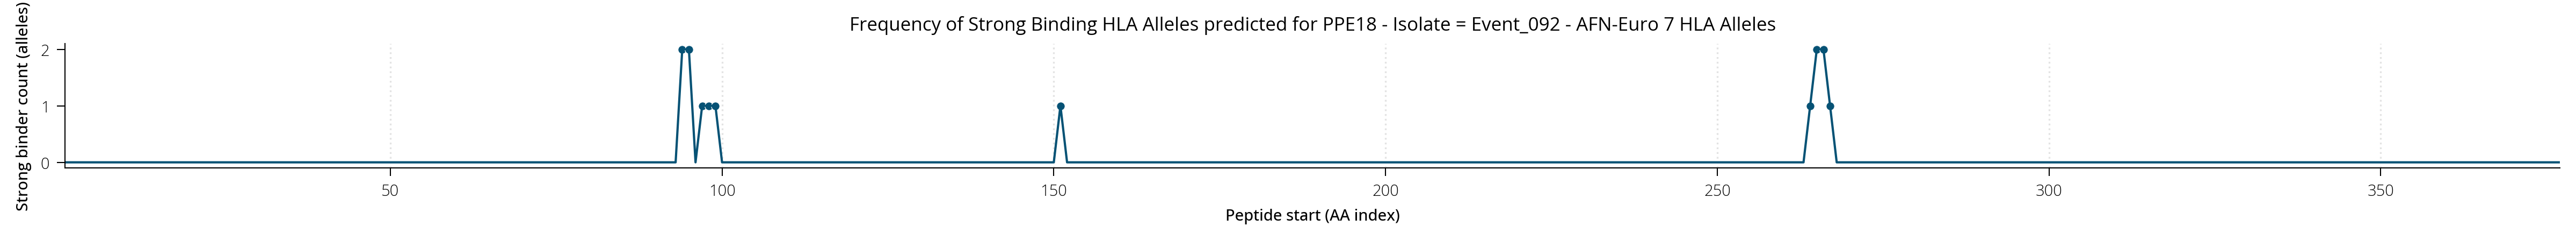

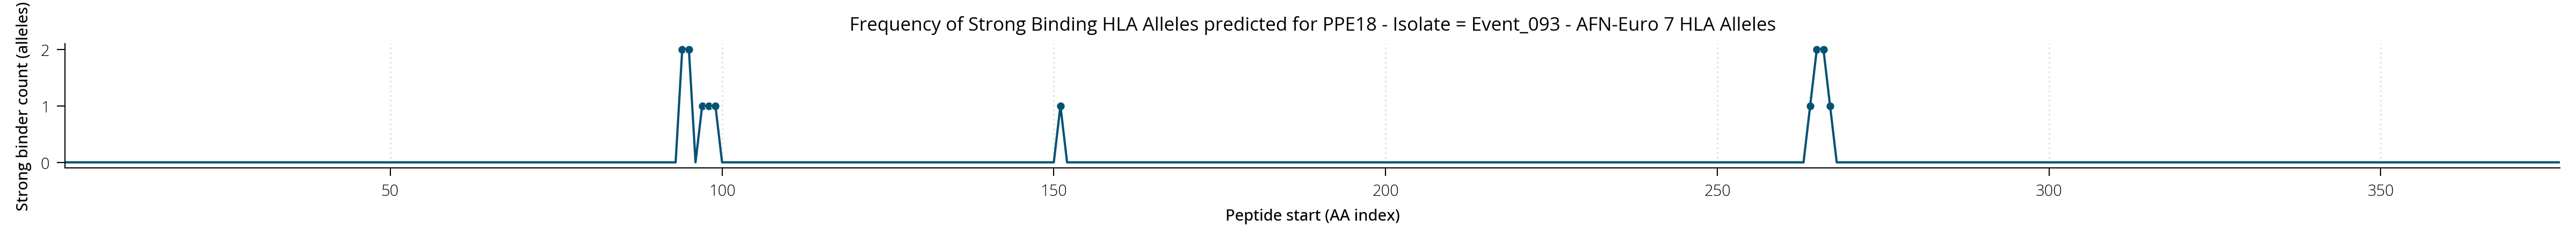

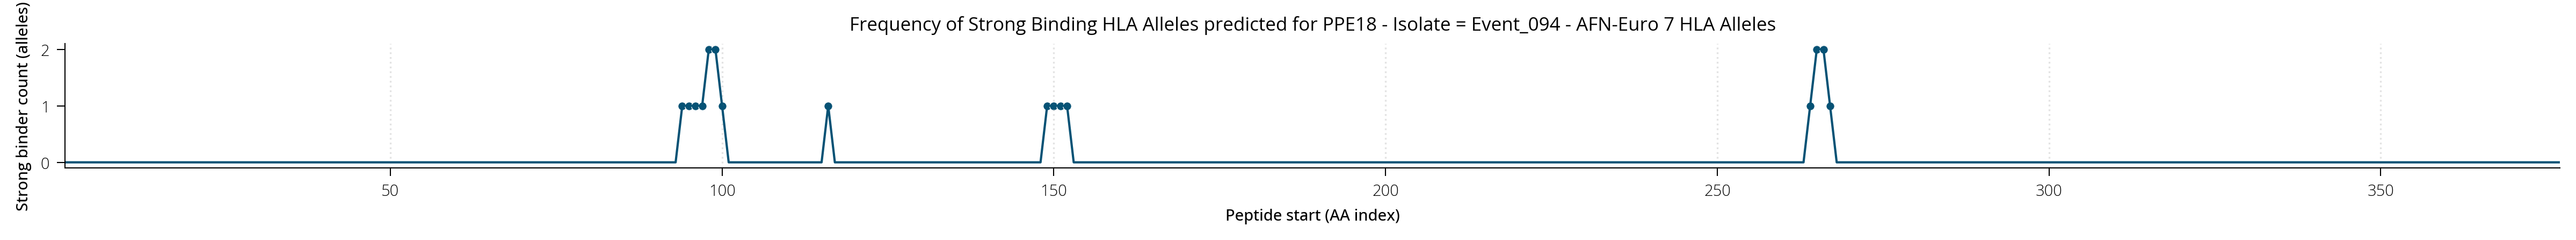

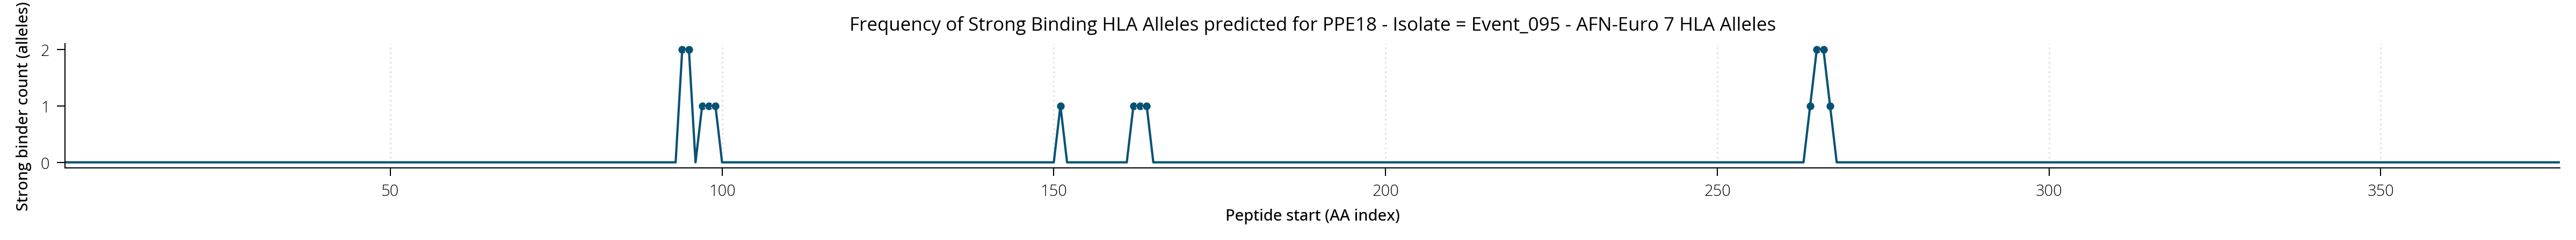

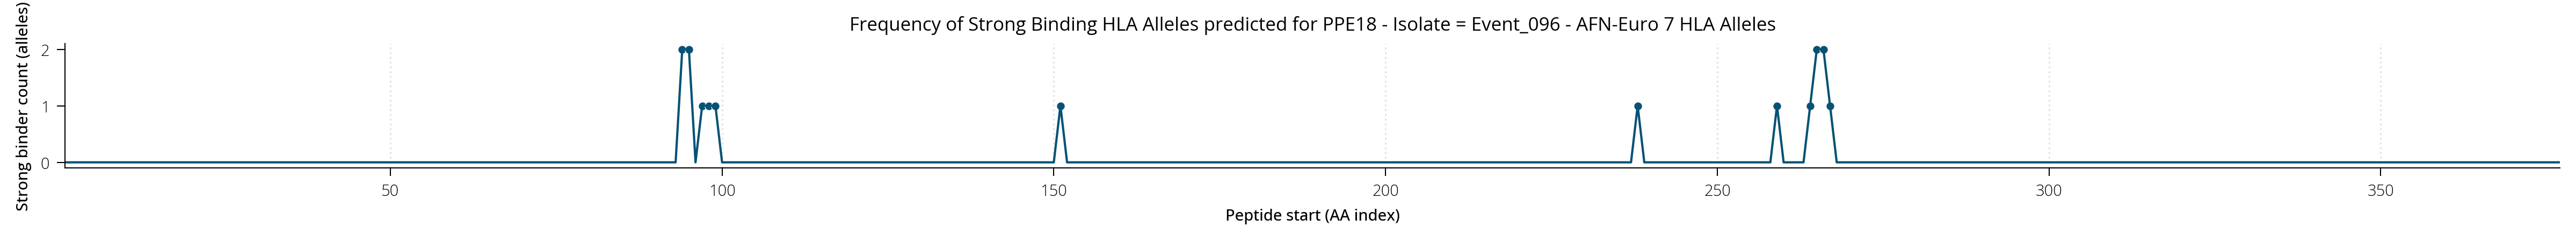

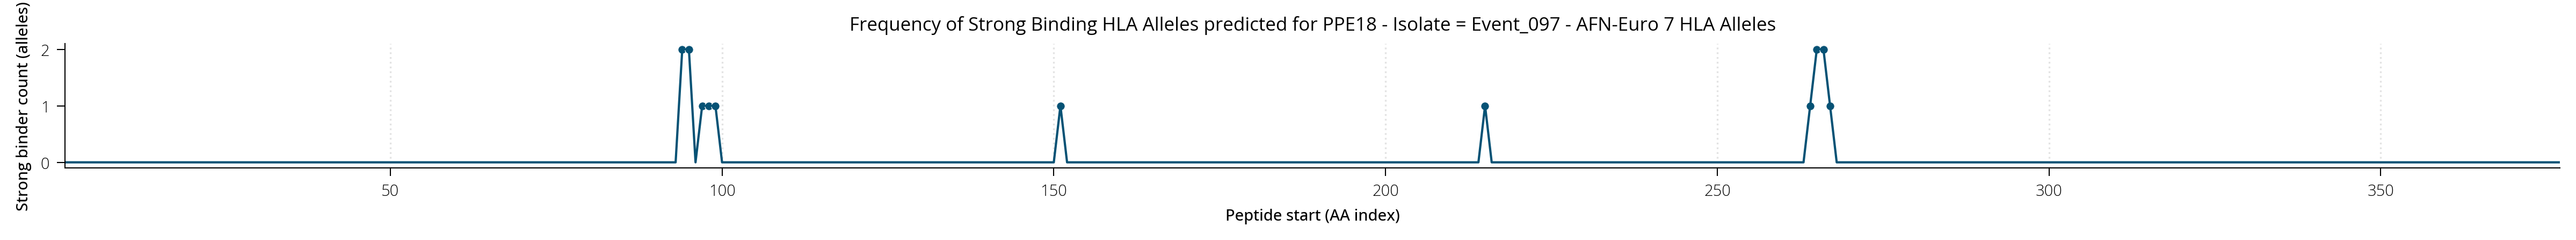

In [226]:

All_SeqAndEventIDs = ['H37Rv', 'Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']

for target_EventID in All_SeqAndEventIDs:

    i_fig, i_ax, i_sb_df = plot_sb_by_pos_singleseq(ResultsDict_AFN_EURO_7A,
                                                    seq_key = target_EventID,
                                                    figsize=(16, 1.5),
                                                    title = f"Frequency of Strong Binding HLA Alleles predicted for PPE18 - Isolate = {target_EventID} - AFN-Euro 7 HLA Alleles")


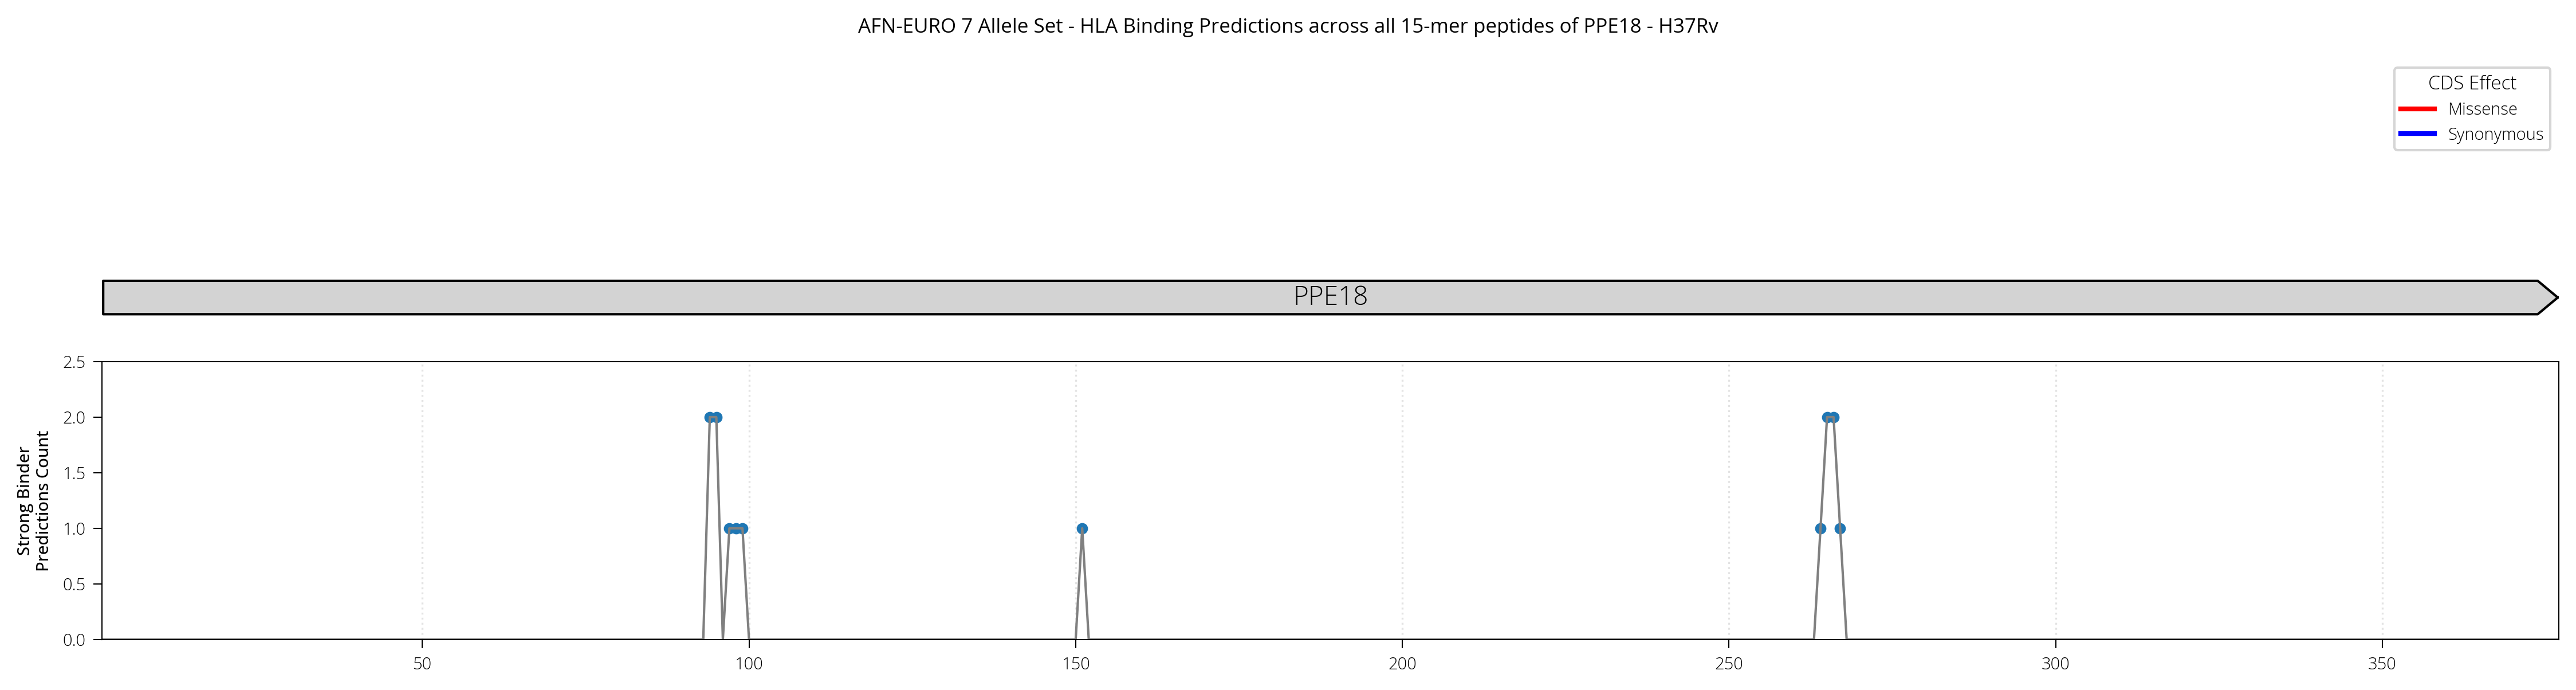

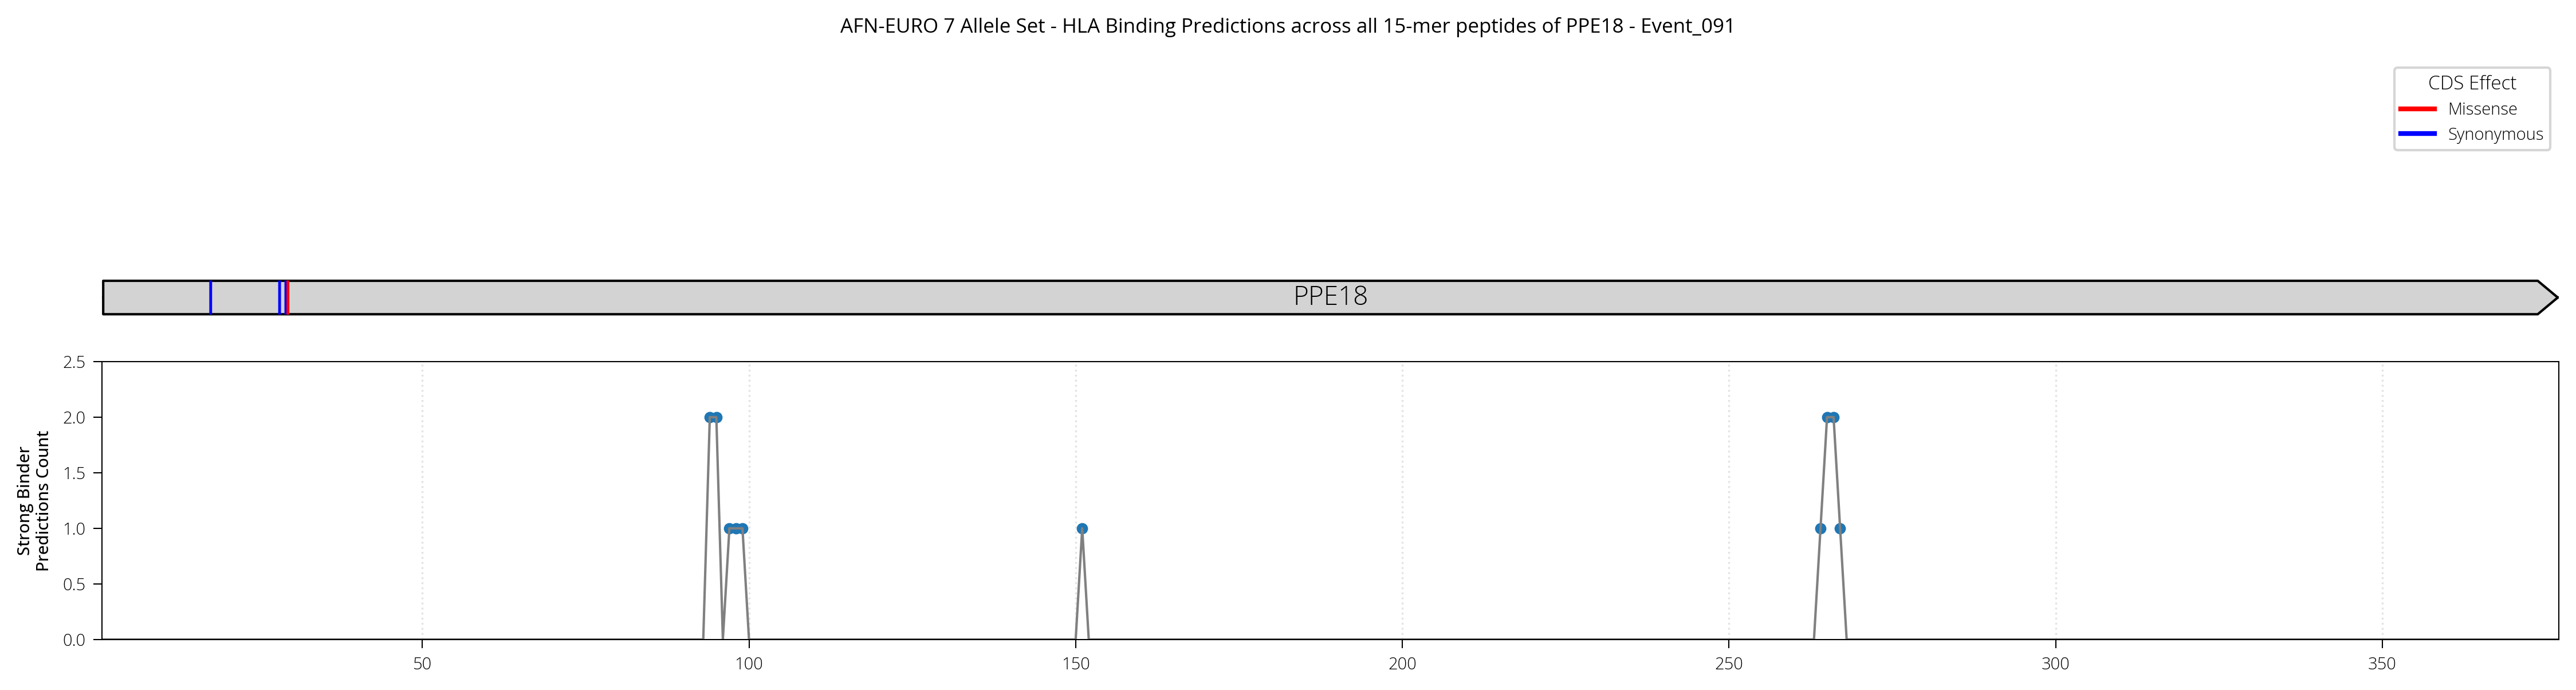

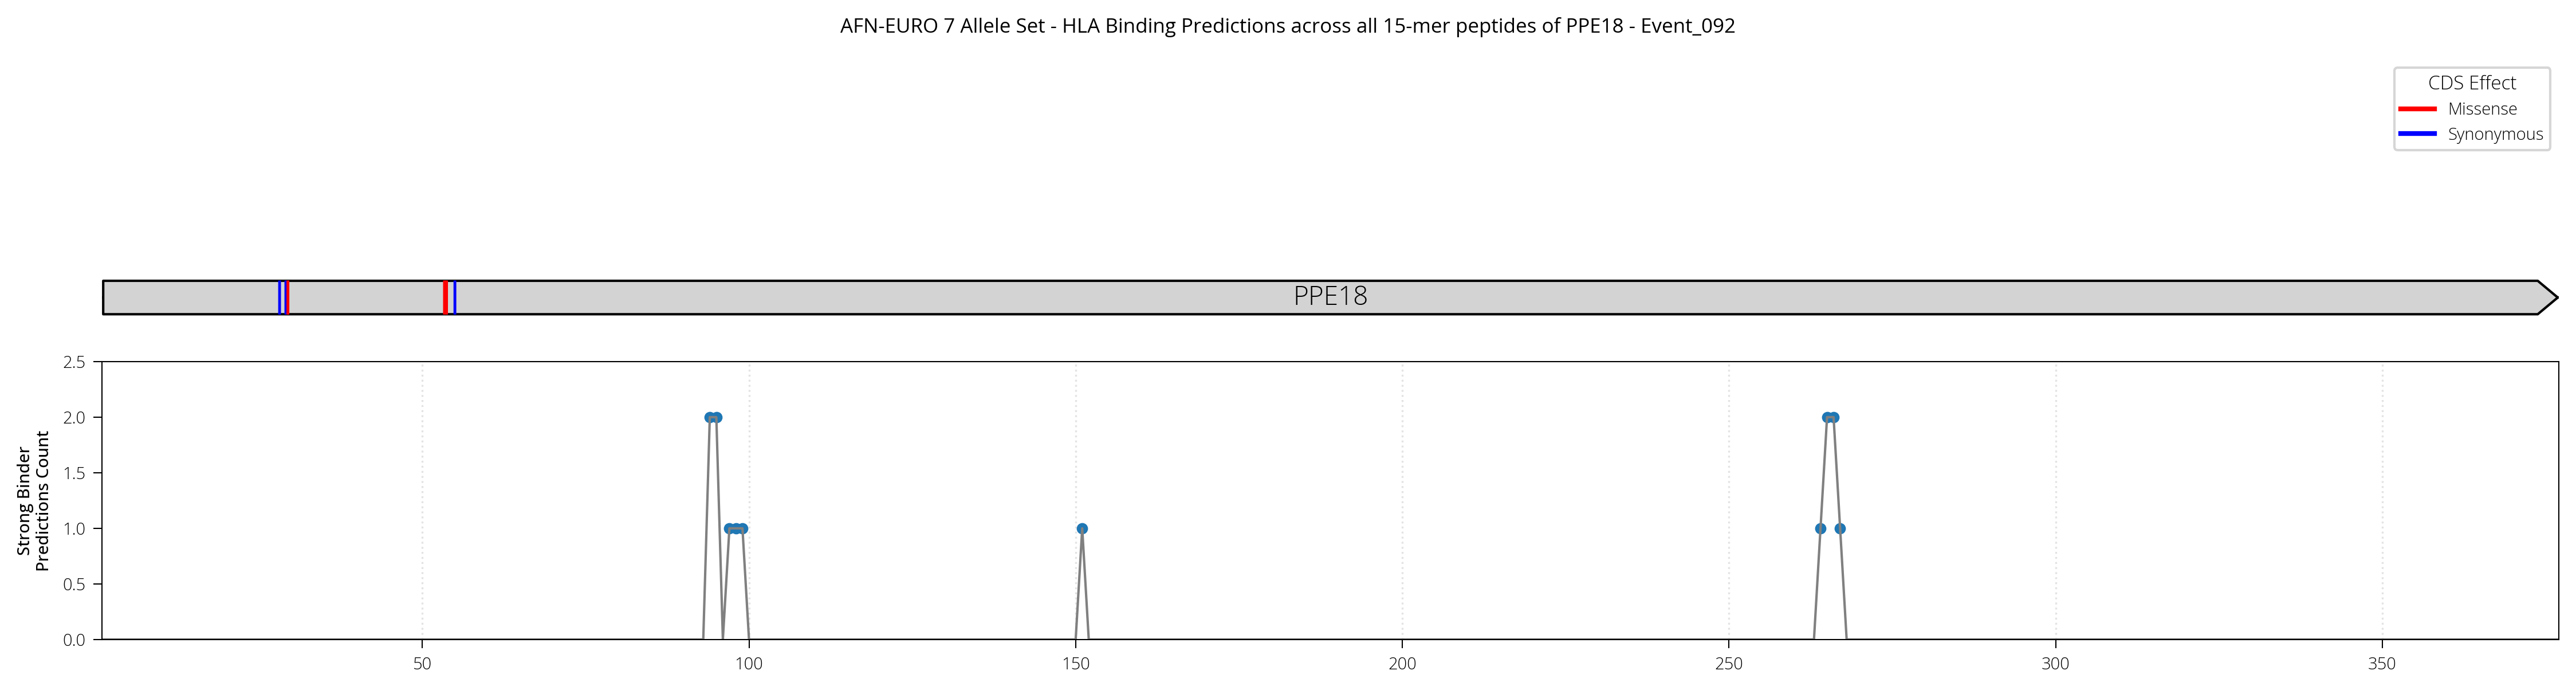

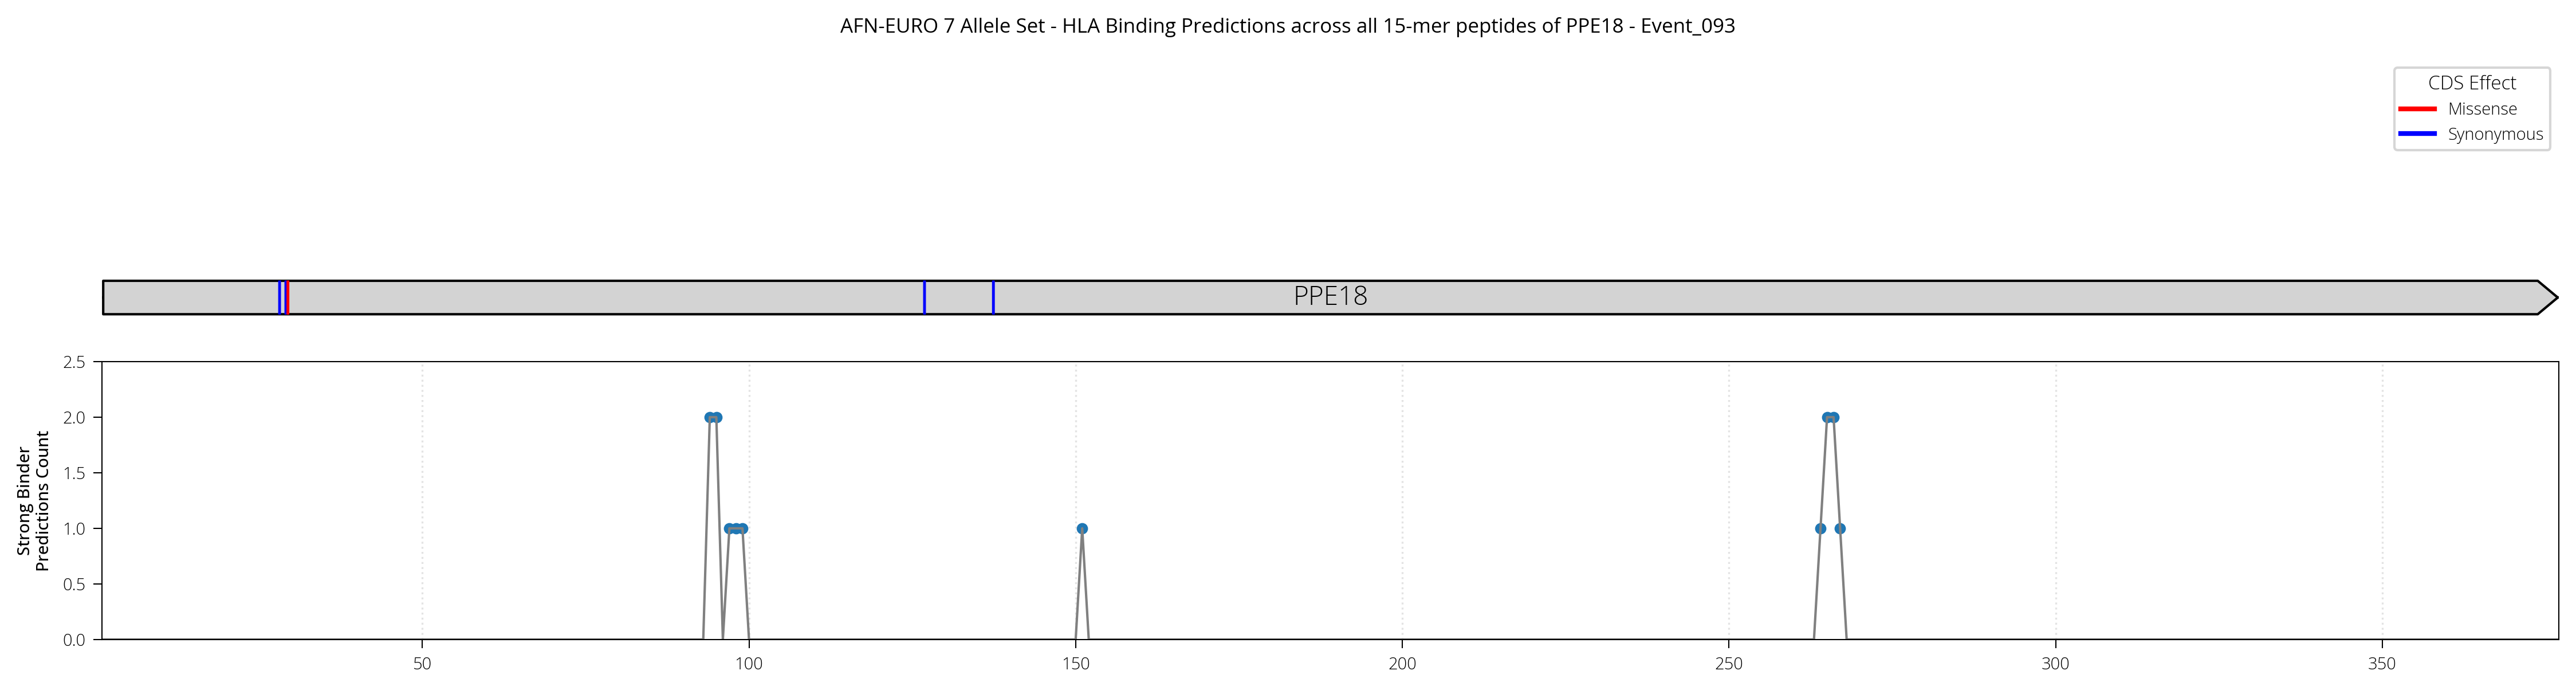

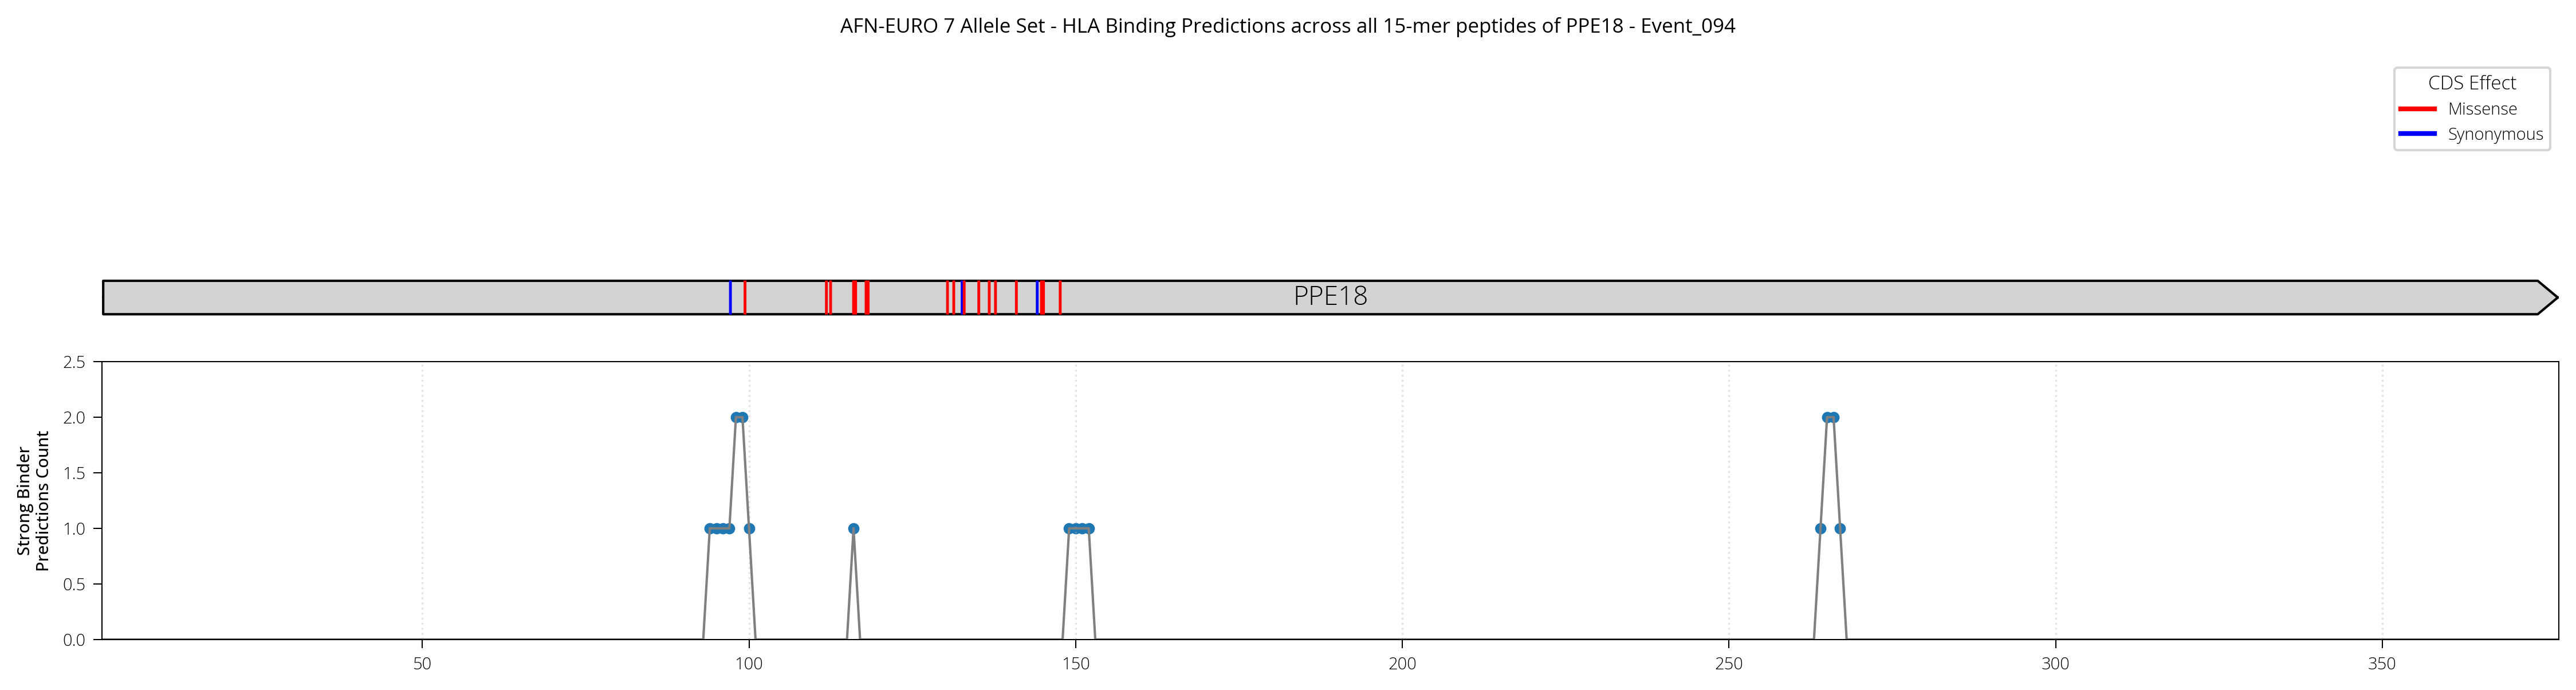

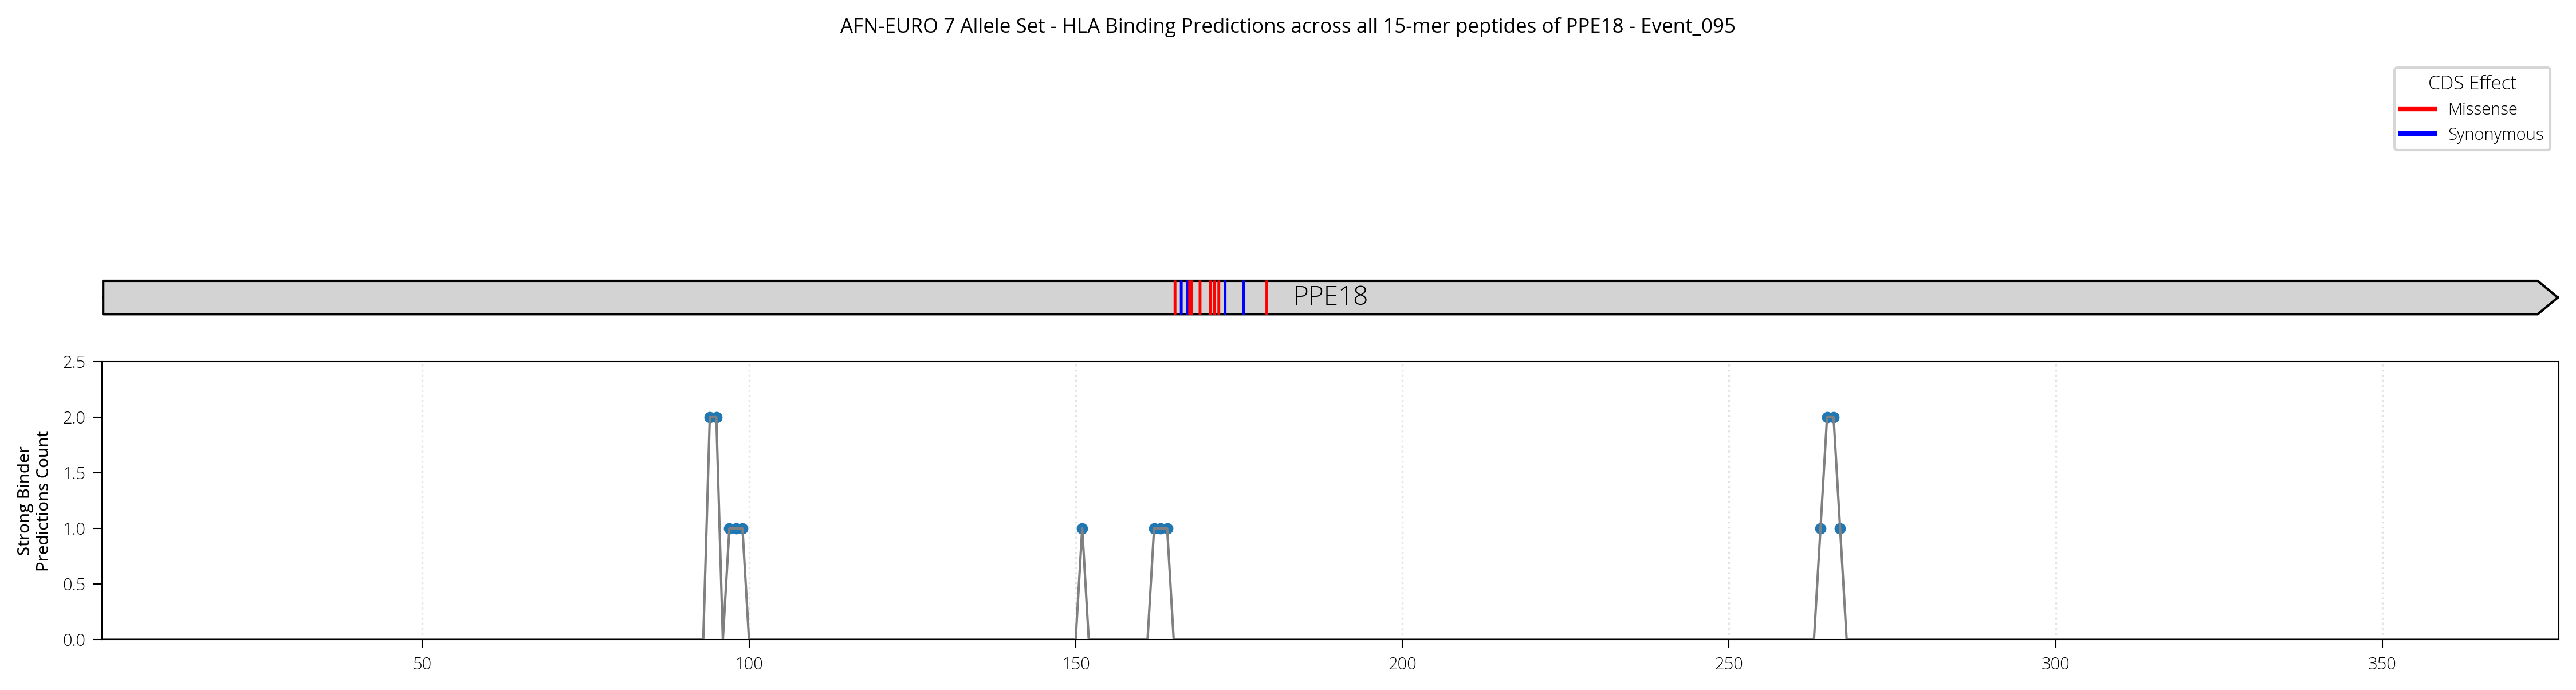

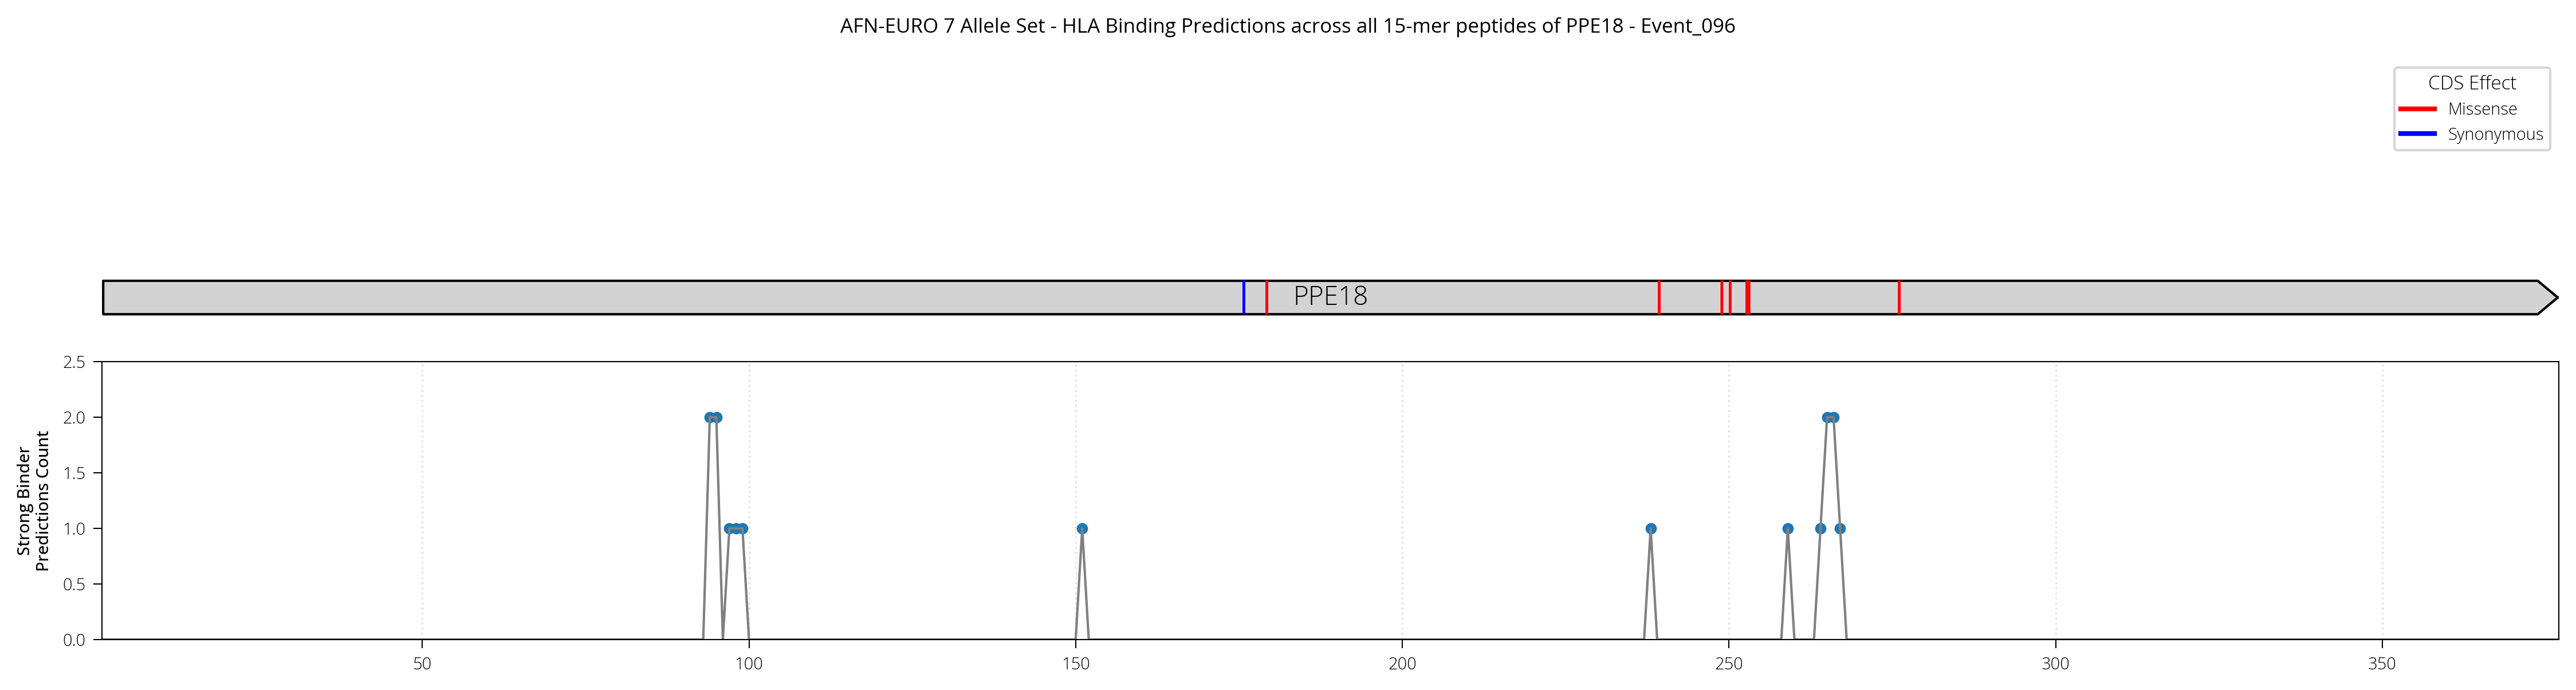

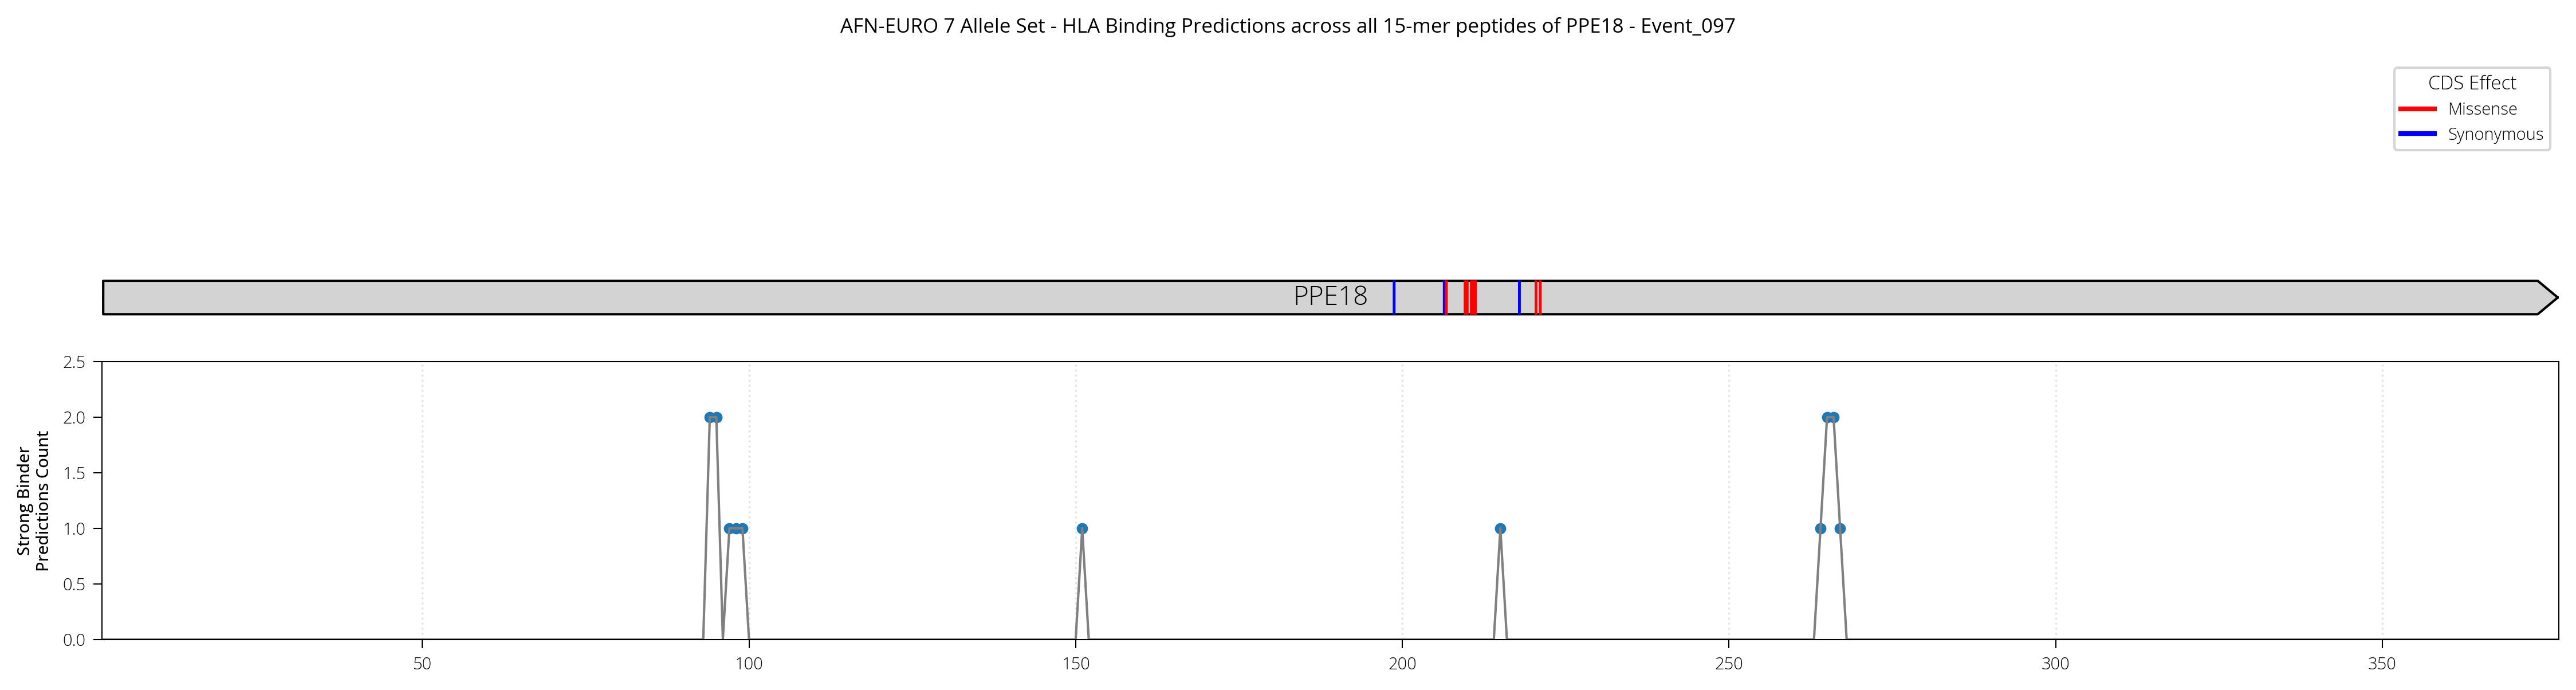

In [227]:

All_SeqAndEventIDs = ['H37Rv', 'Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']

for target_EventID in All_SeqAndEventIDs:

    GCE_Vs_HLABind_Baseline_E091_fig = plot_EventWiAnno_WiSBPred_Baseline_2panel(
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        in_EventID = target_EventID,
        in_GCEvents_All_DF = pGCE_DF,
        in_Gubbins_SNPs_DF = Gub_SNPs_V2_DF,
        i_MainResults_Dict = ResultsDict_AFN_EURO_7A,
        Viz_Start = PPE18_Viz_Start,
        Viz_End = PPE18_Viz_End,
        in_ylim = (-5, 5),
        show_snp_labels=False,
        i_figsize = (15, 4),
        title = f"AFN-EURO 7 Allele Set - HLA Binding Predictions across all 15-mer peptides of PPE18 - {target_EventID}",
    )

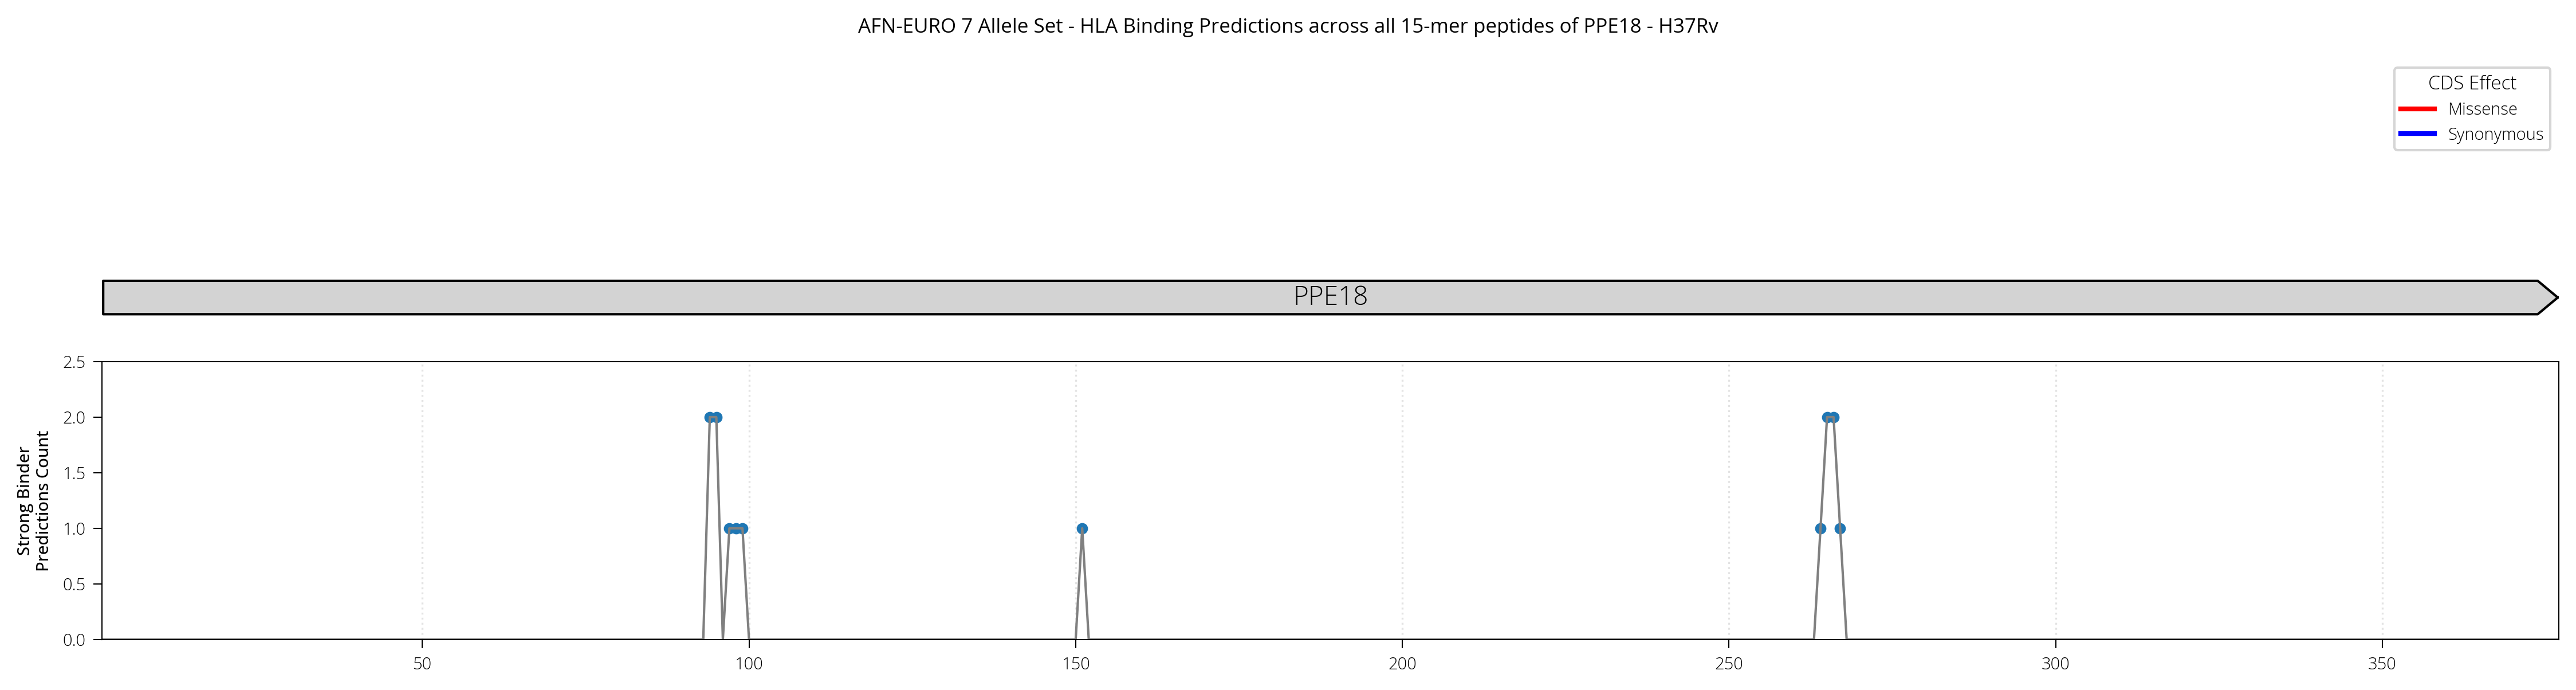

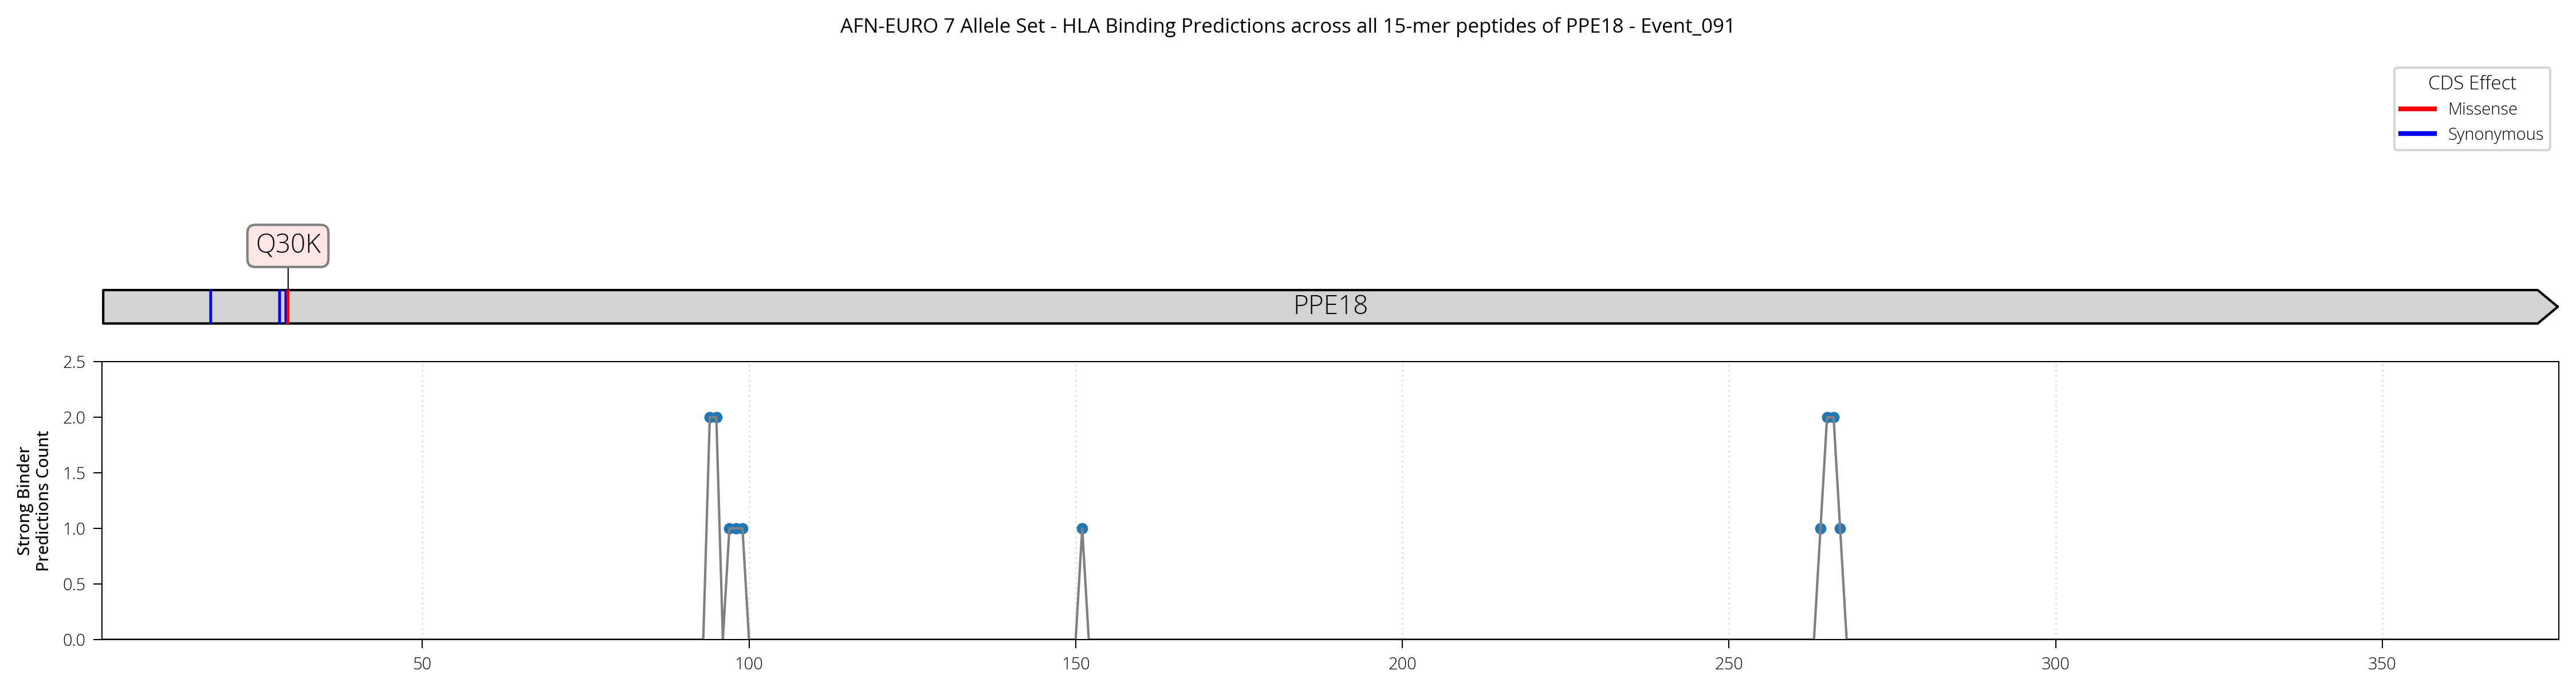

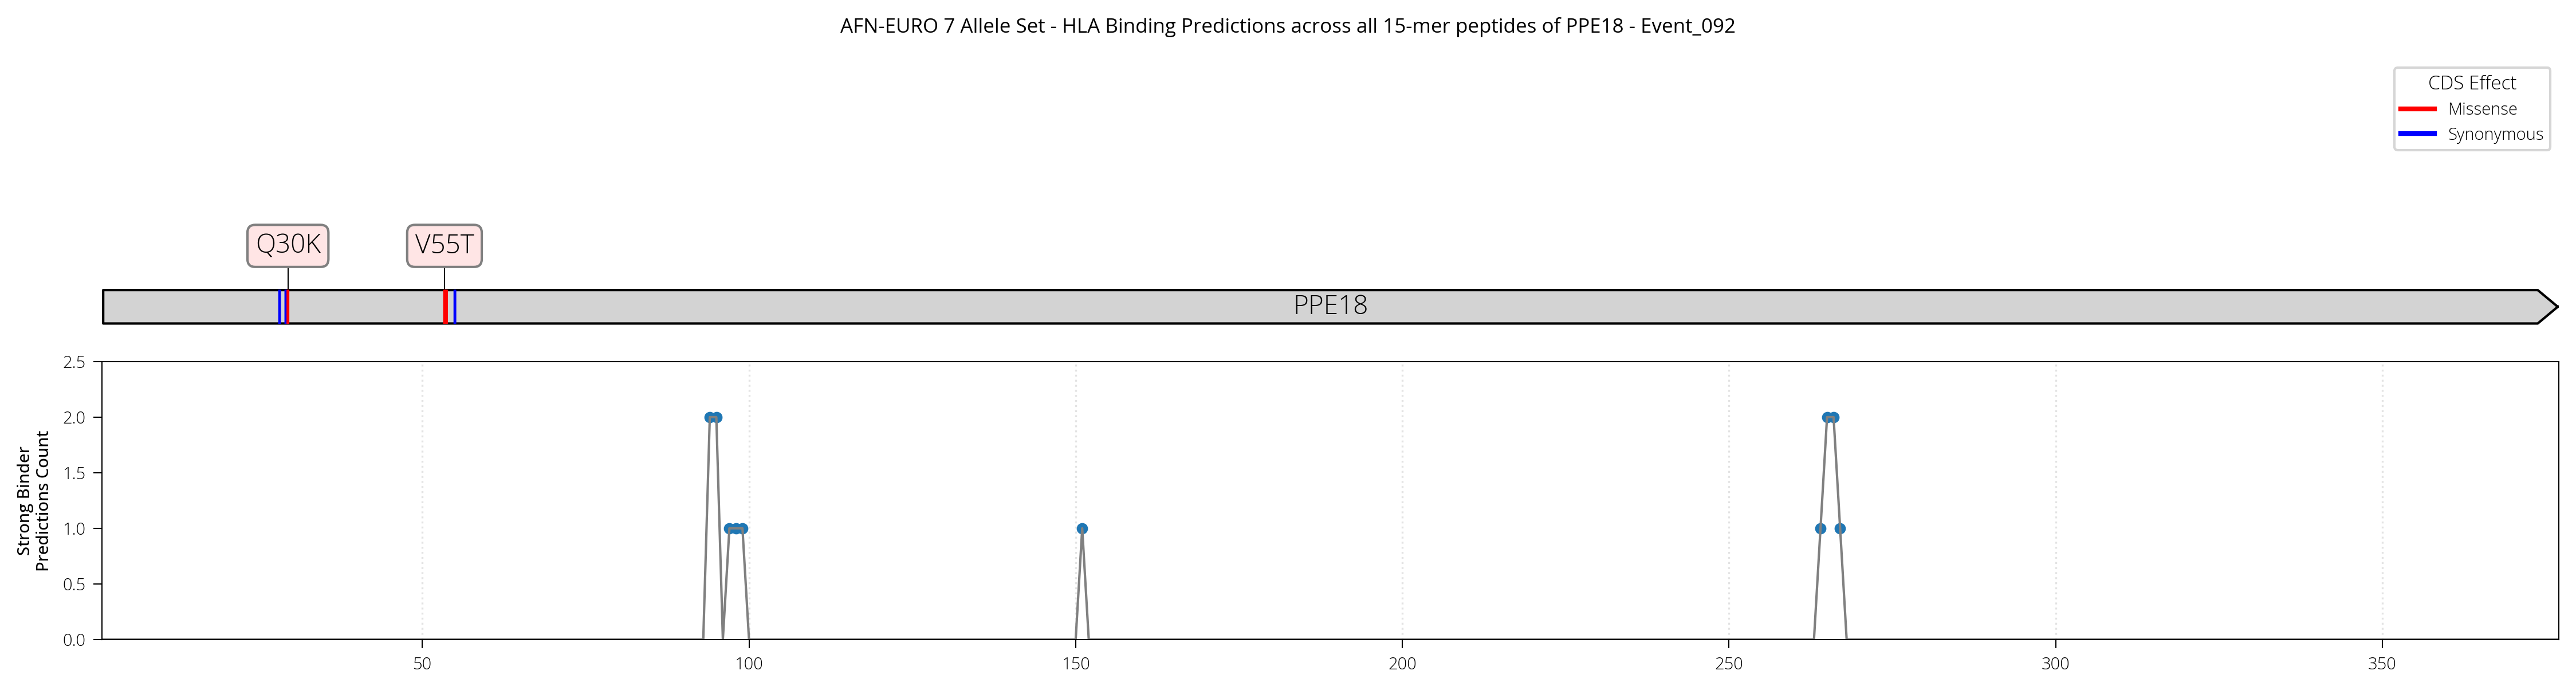

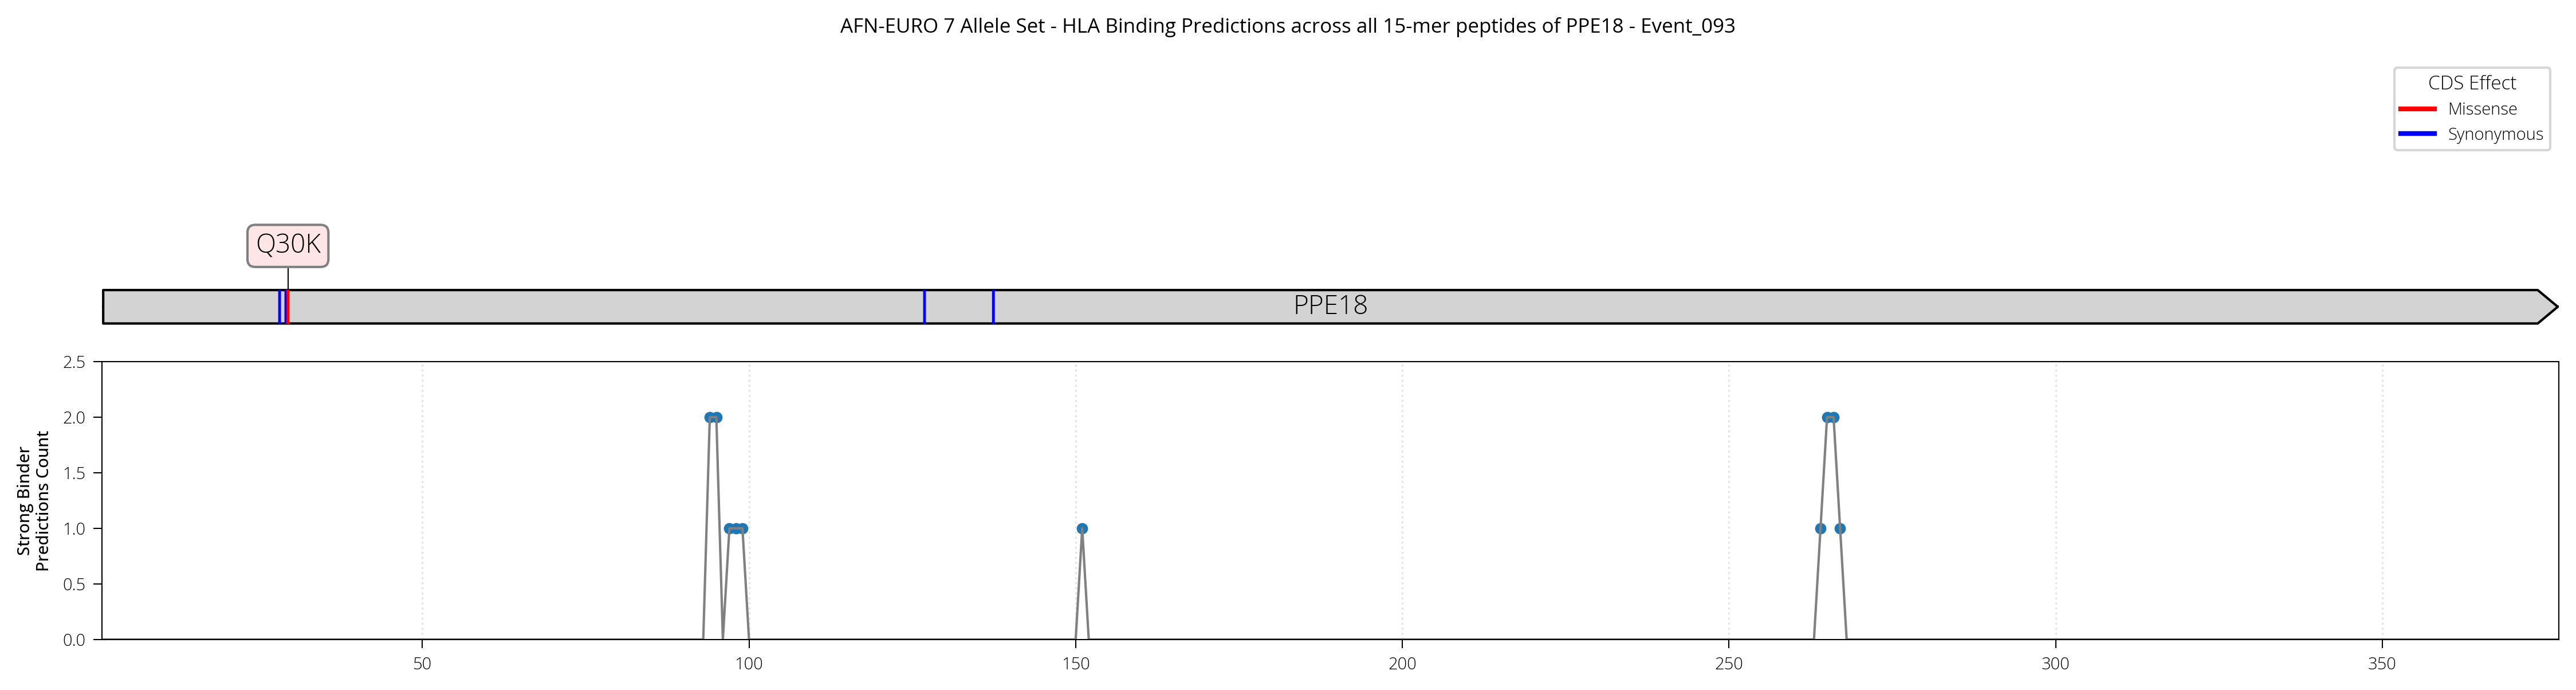

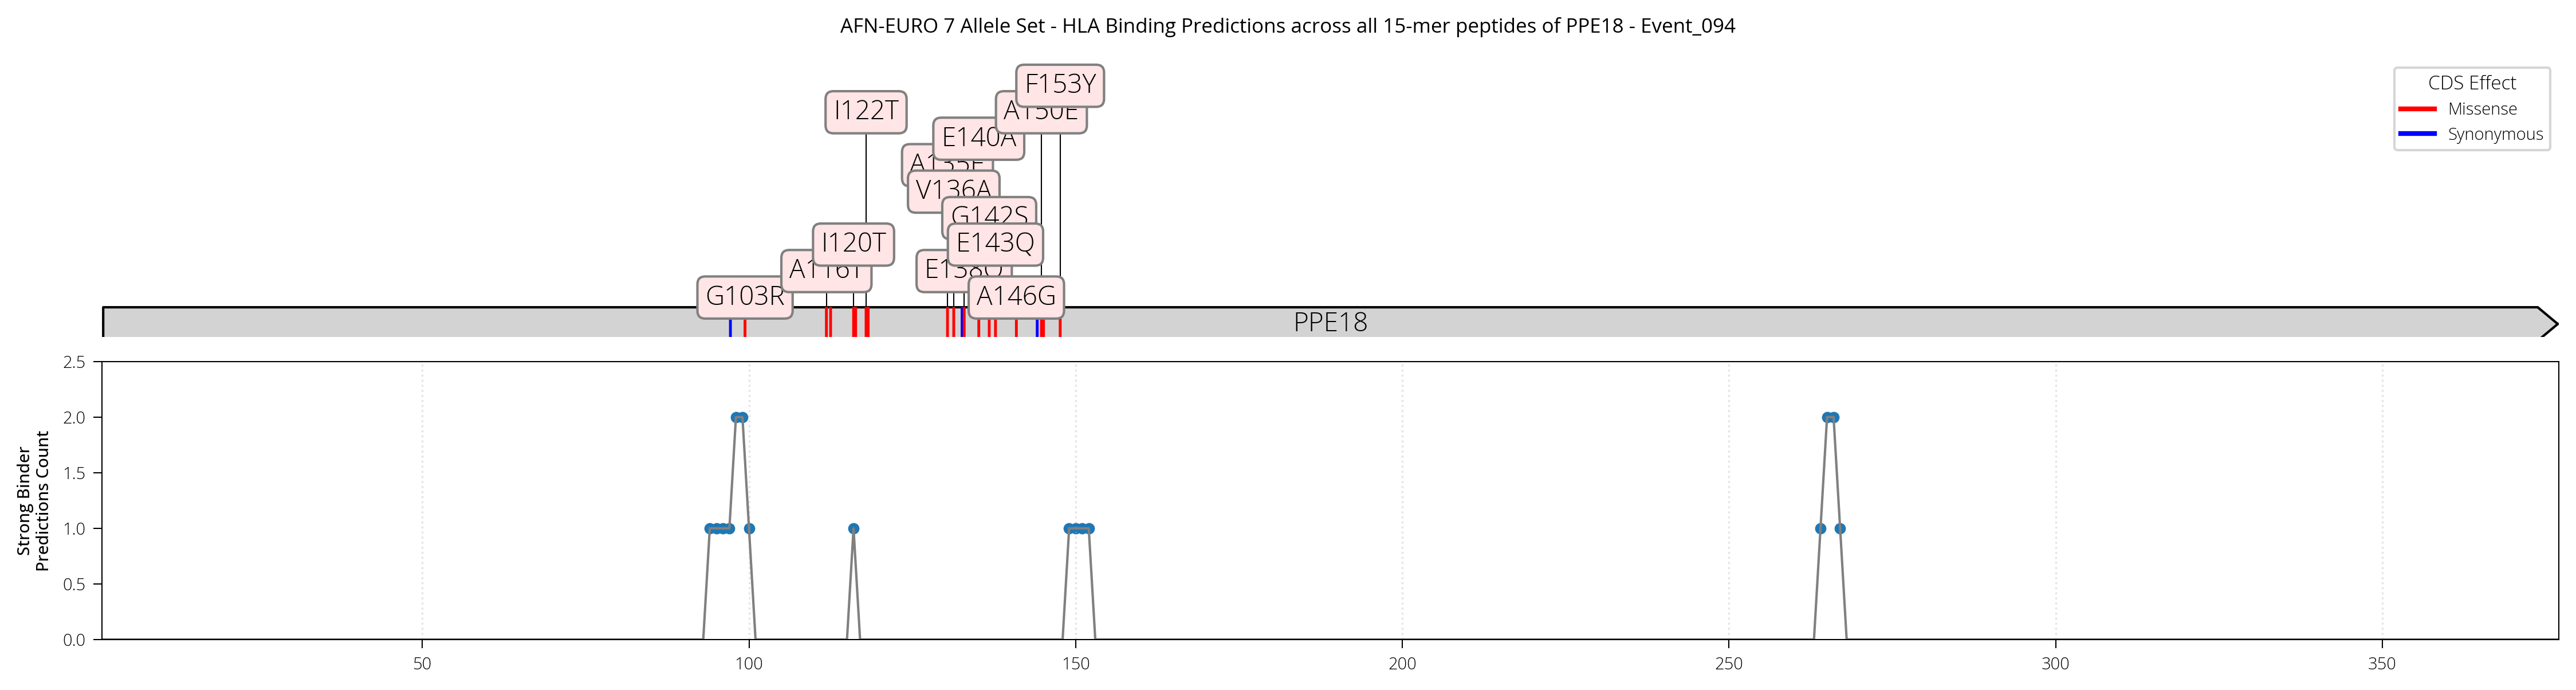

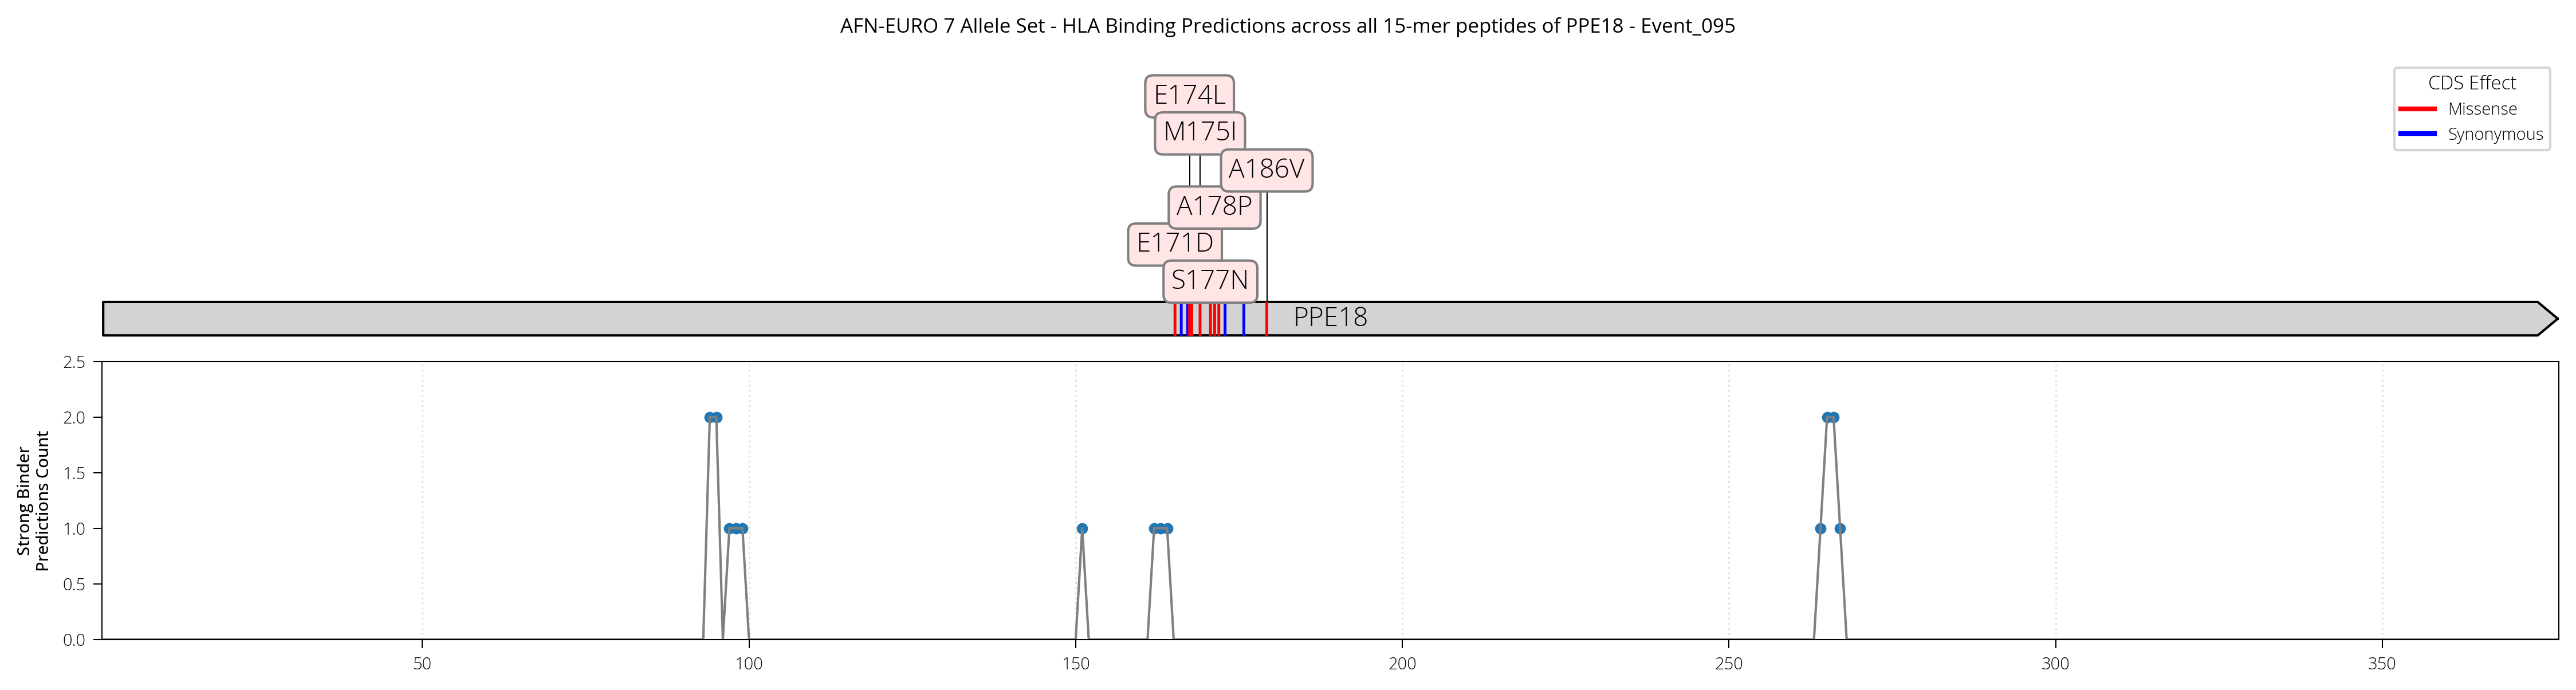

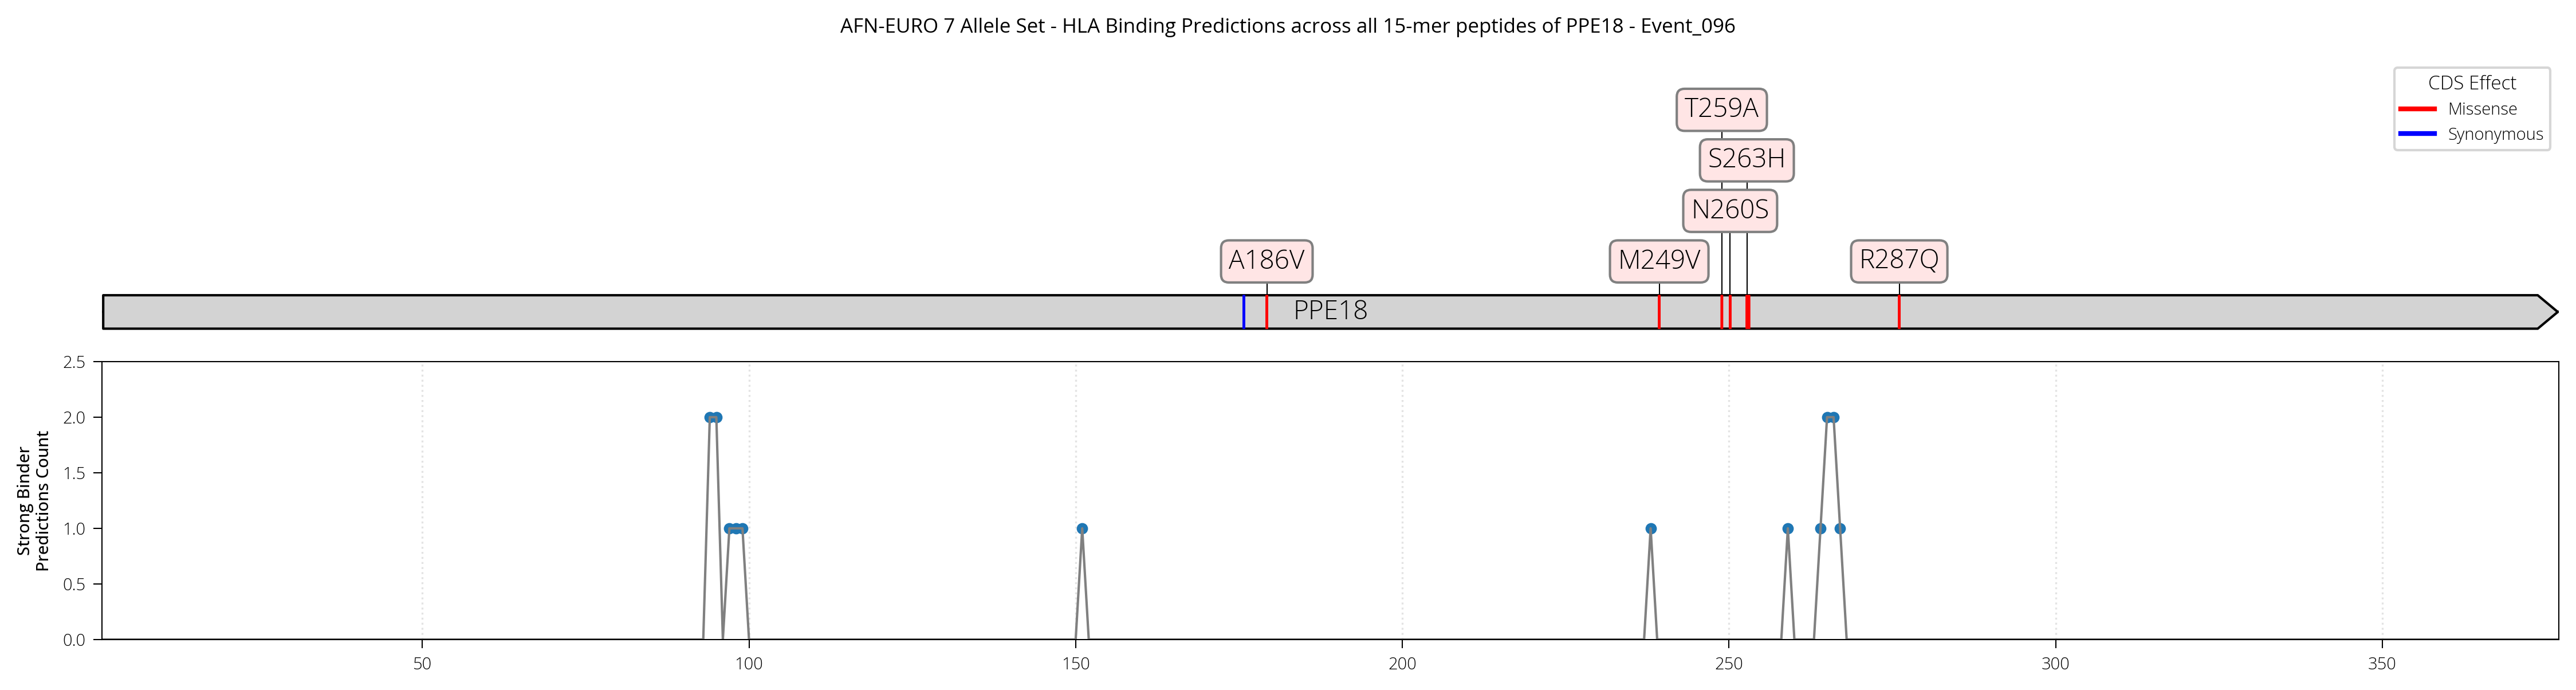

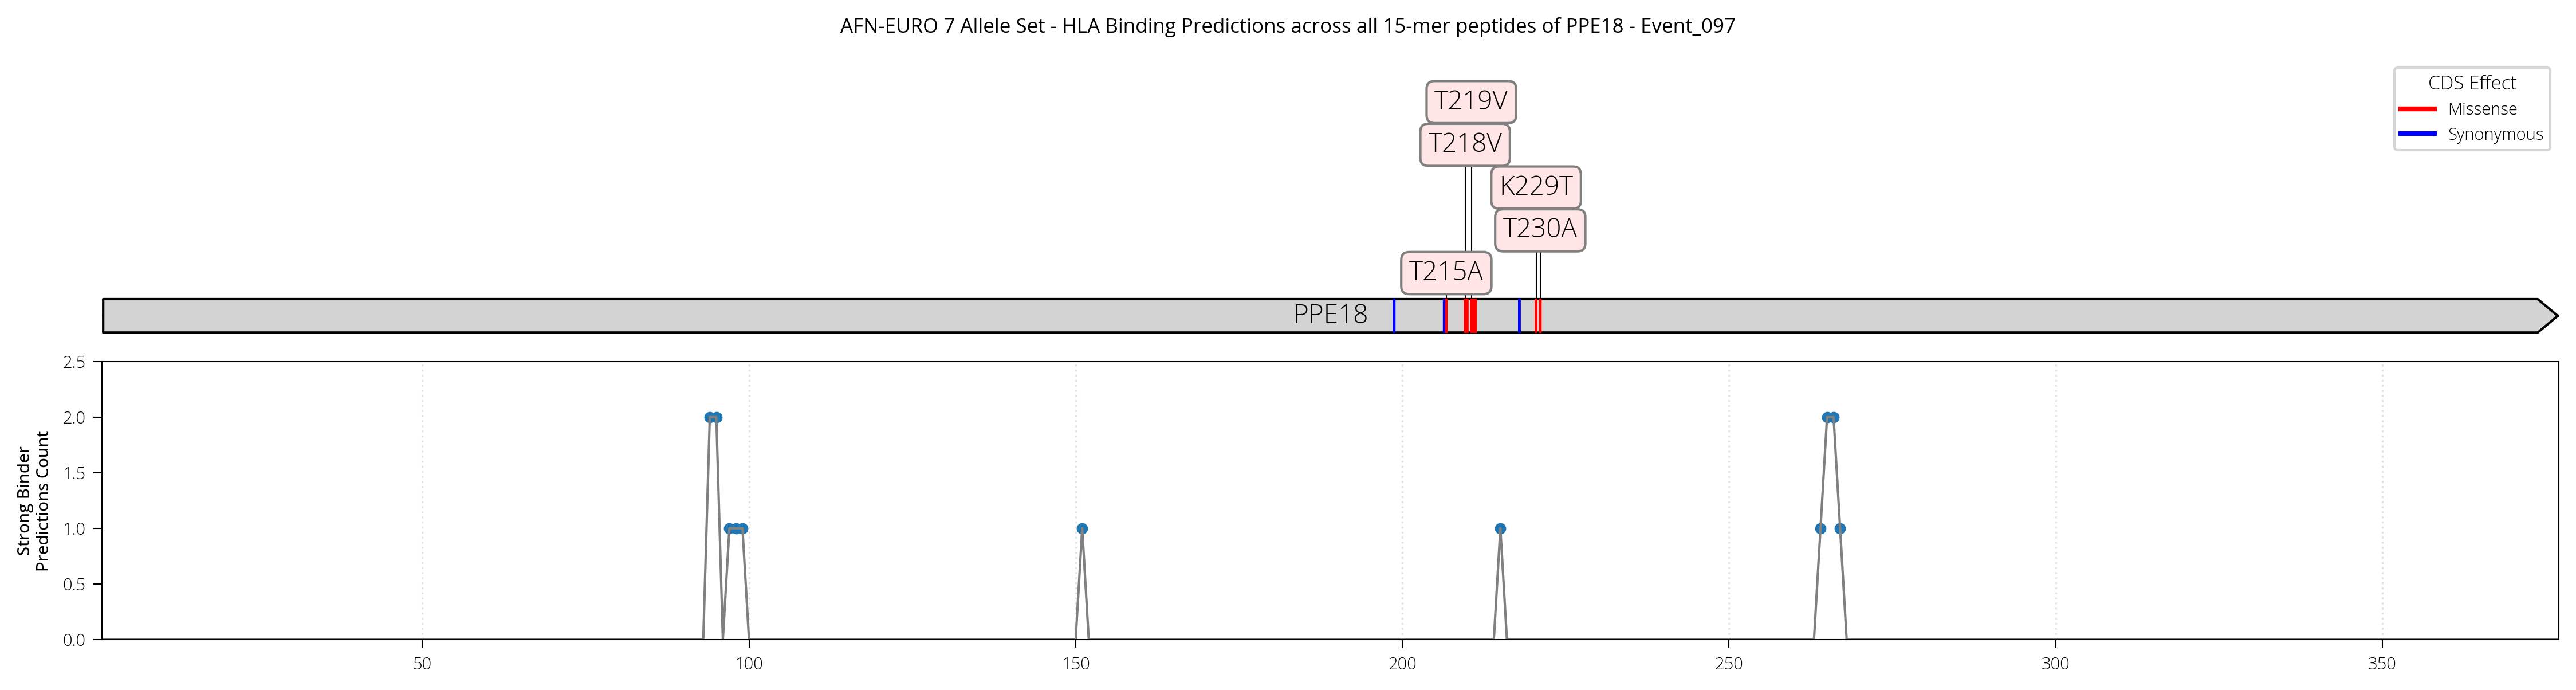

In [228]:

All_SeqAndEventIDs = ['H37Rv', 'Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']

for target_EventID in All_SeqAndEventIDs:

    GCE_Vs_HLABind_Baseline_E091_fig = plot_EventWiAnno_WiSBPred_Baseline_2panel(
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        in_EventID = target_EventID,
        in_GCEvents_All_DF = pGCE_DF,
        in_Gubbins_SNPs_DF = Gub_SNPs_V2_DF,
        i_MainResults_Dict = ResultsDict_AFN_EURO_7A,
        Viz_Start = PPE18_Viz_Start,
        Viz_End = PPE18_Viz_End,
        in_ylim = (-5, 5),
        show_snp_labels=True,
        i_figsize = (15, 4),
        title = f"AFN-EURO 7 Allele Set - HLA Binding Predictions across all 15-mer peptides of PPE18 - {target_EventID}",
    )

In [229]:
ResultsDict_AFN_EURO_7A['Event_091'].keys()

dict_keys(['raw', 'collapsed', 'pivot', 'sum', 'SB_DiffToRef_PerPos', 'SB_DiffToRef_Pivot_DF'])

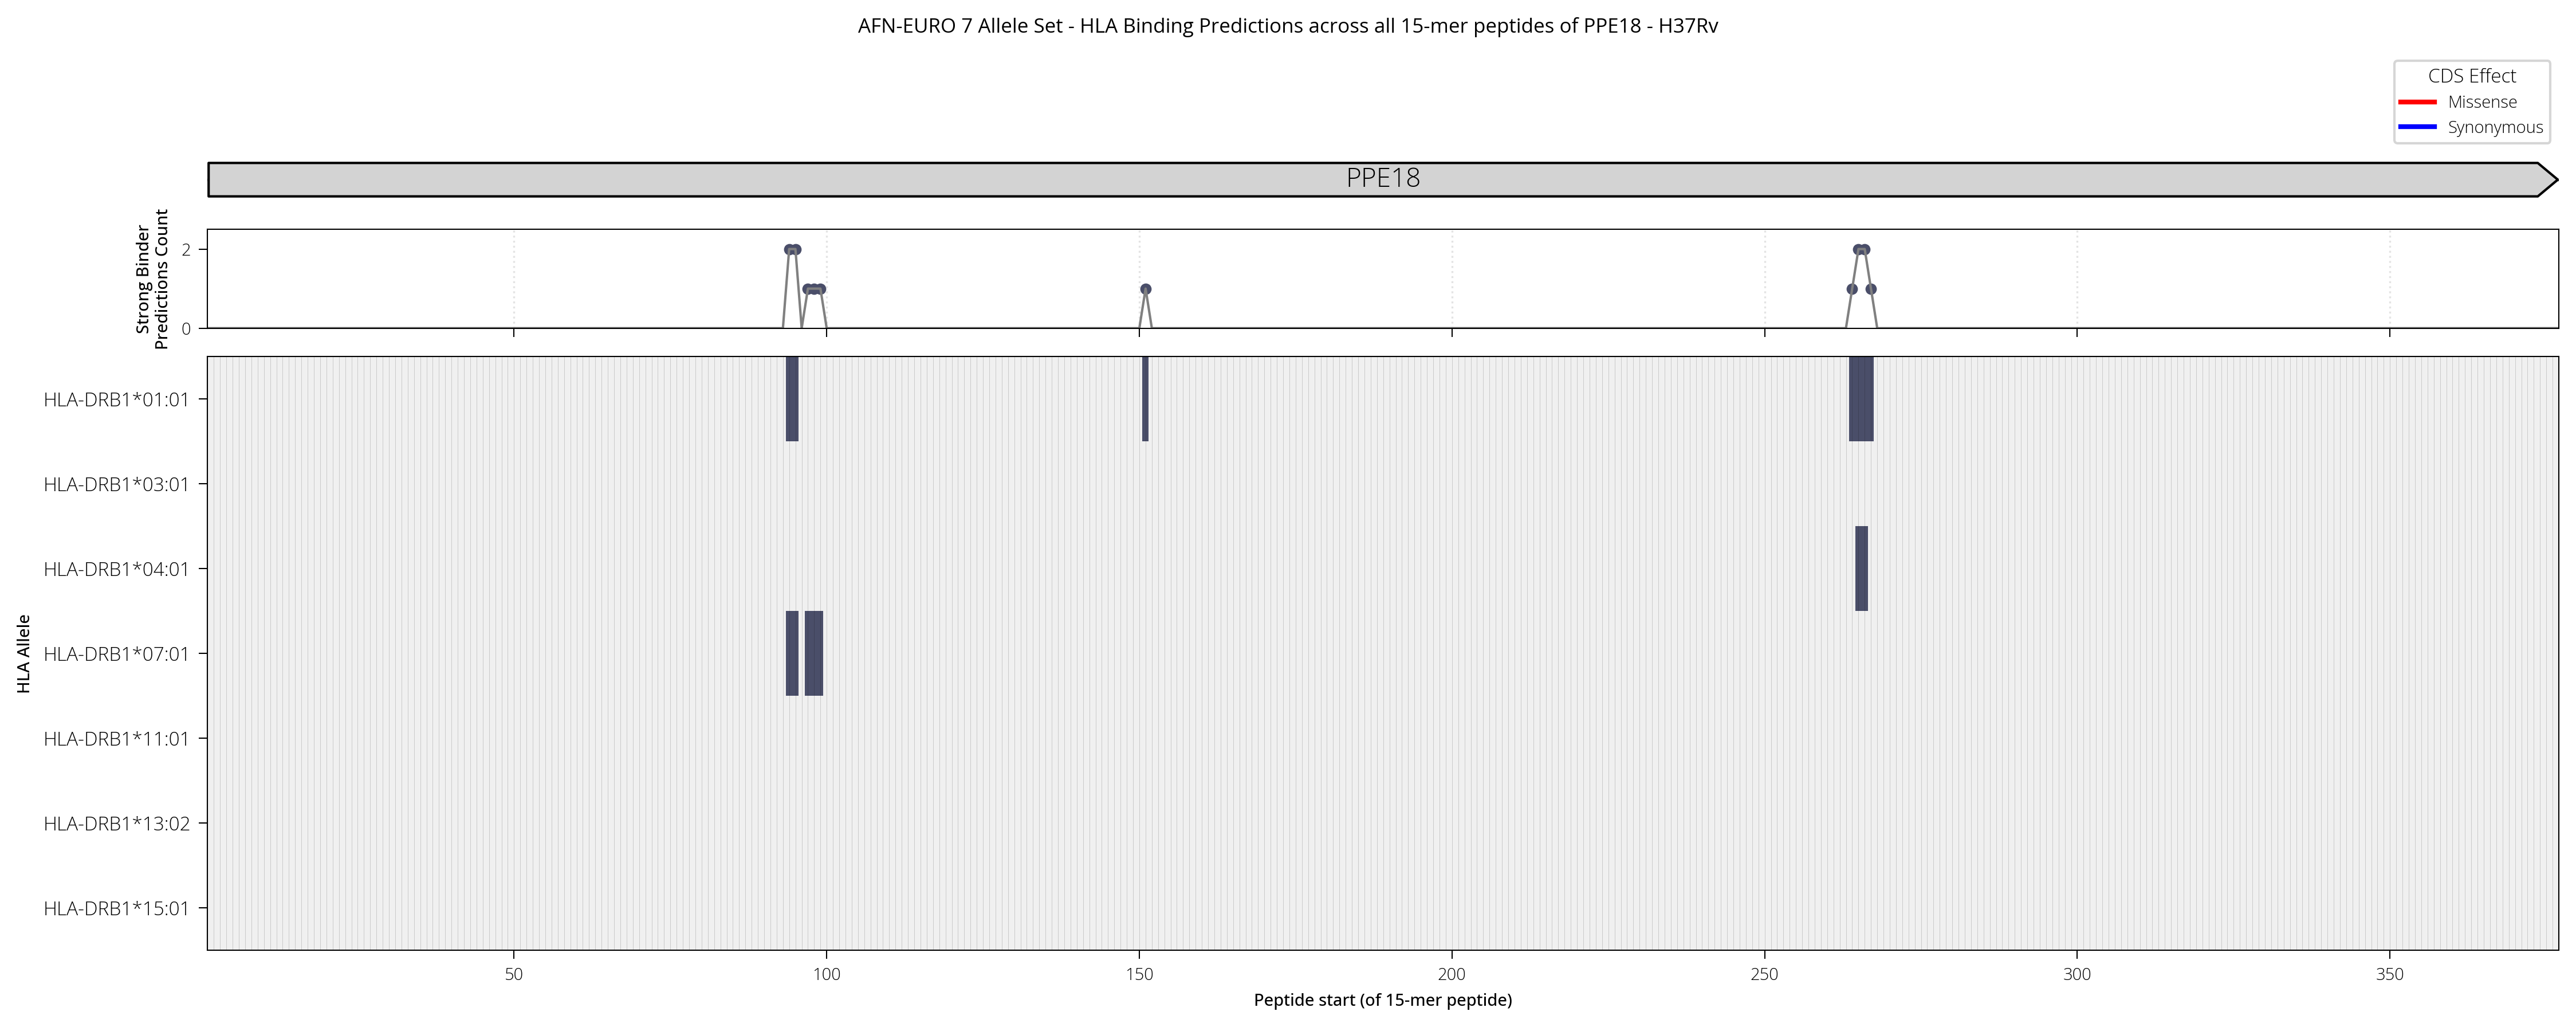

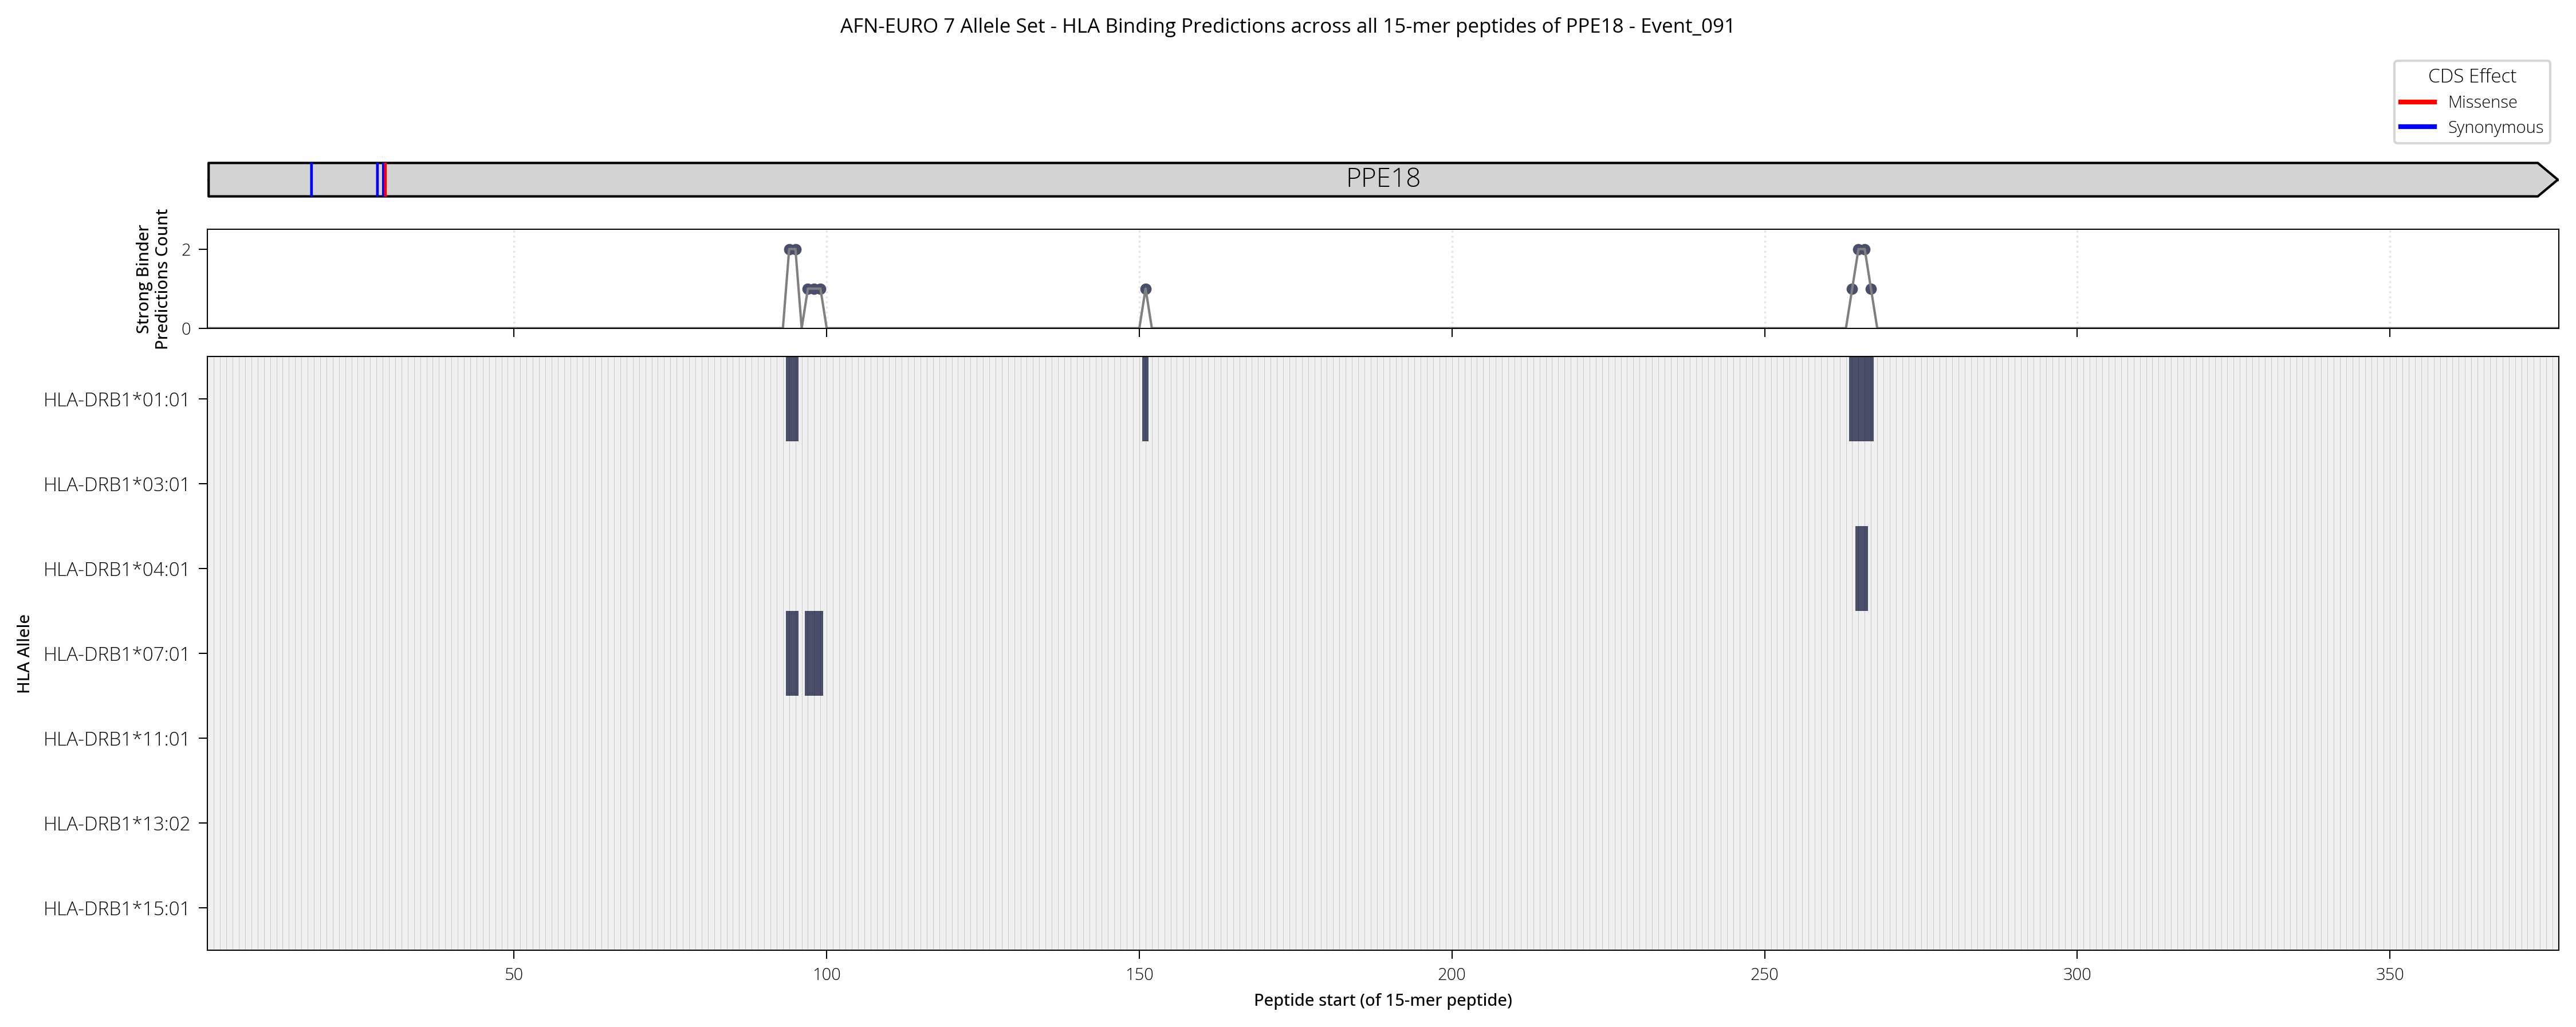

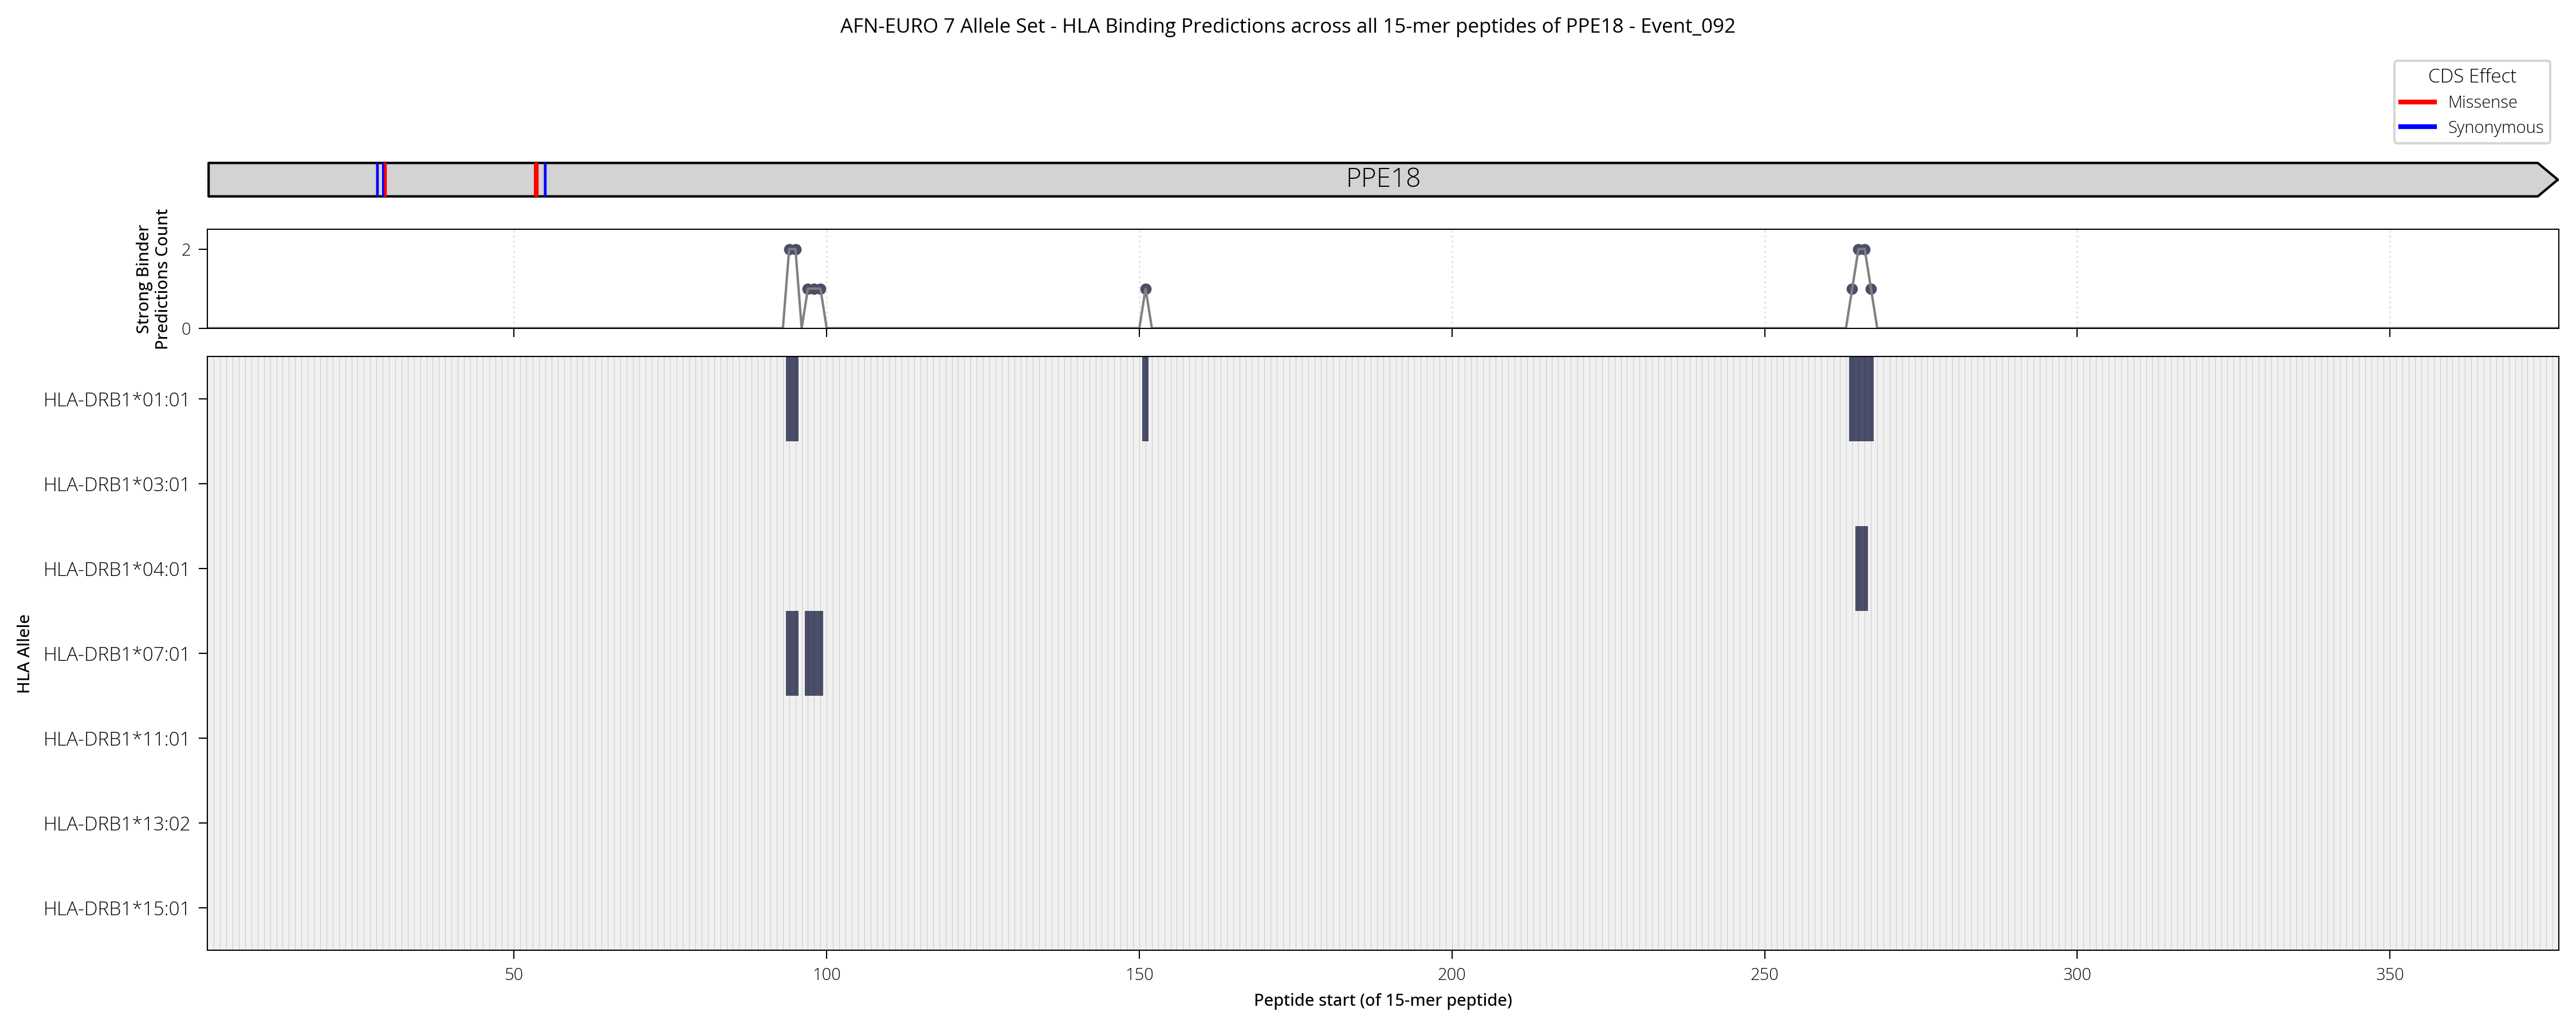

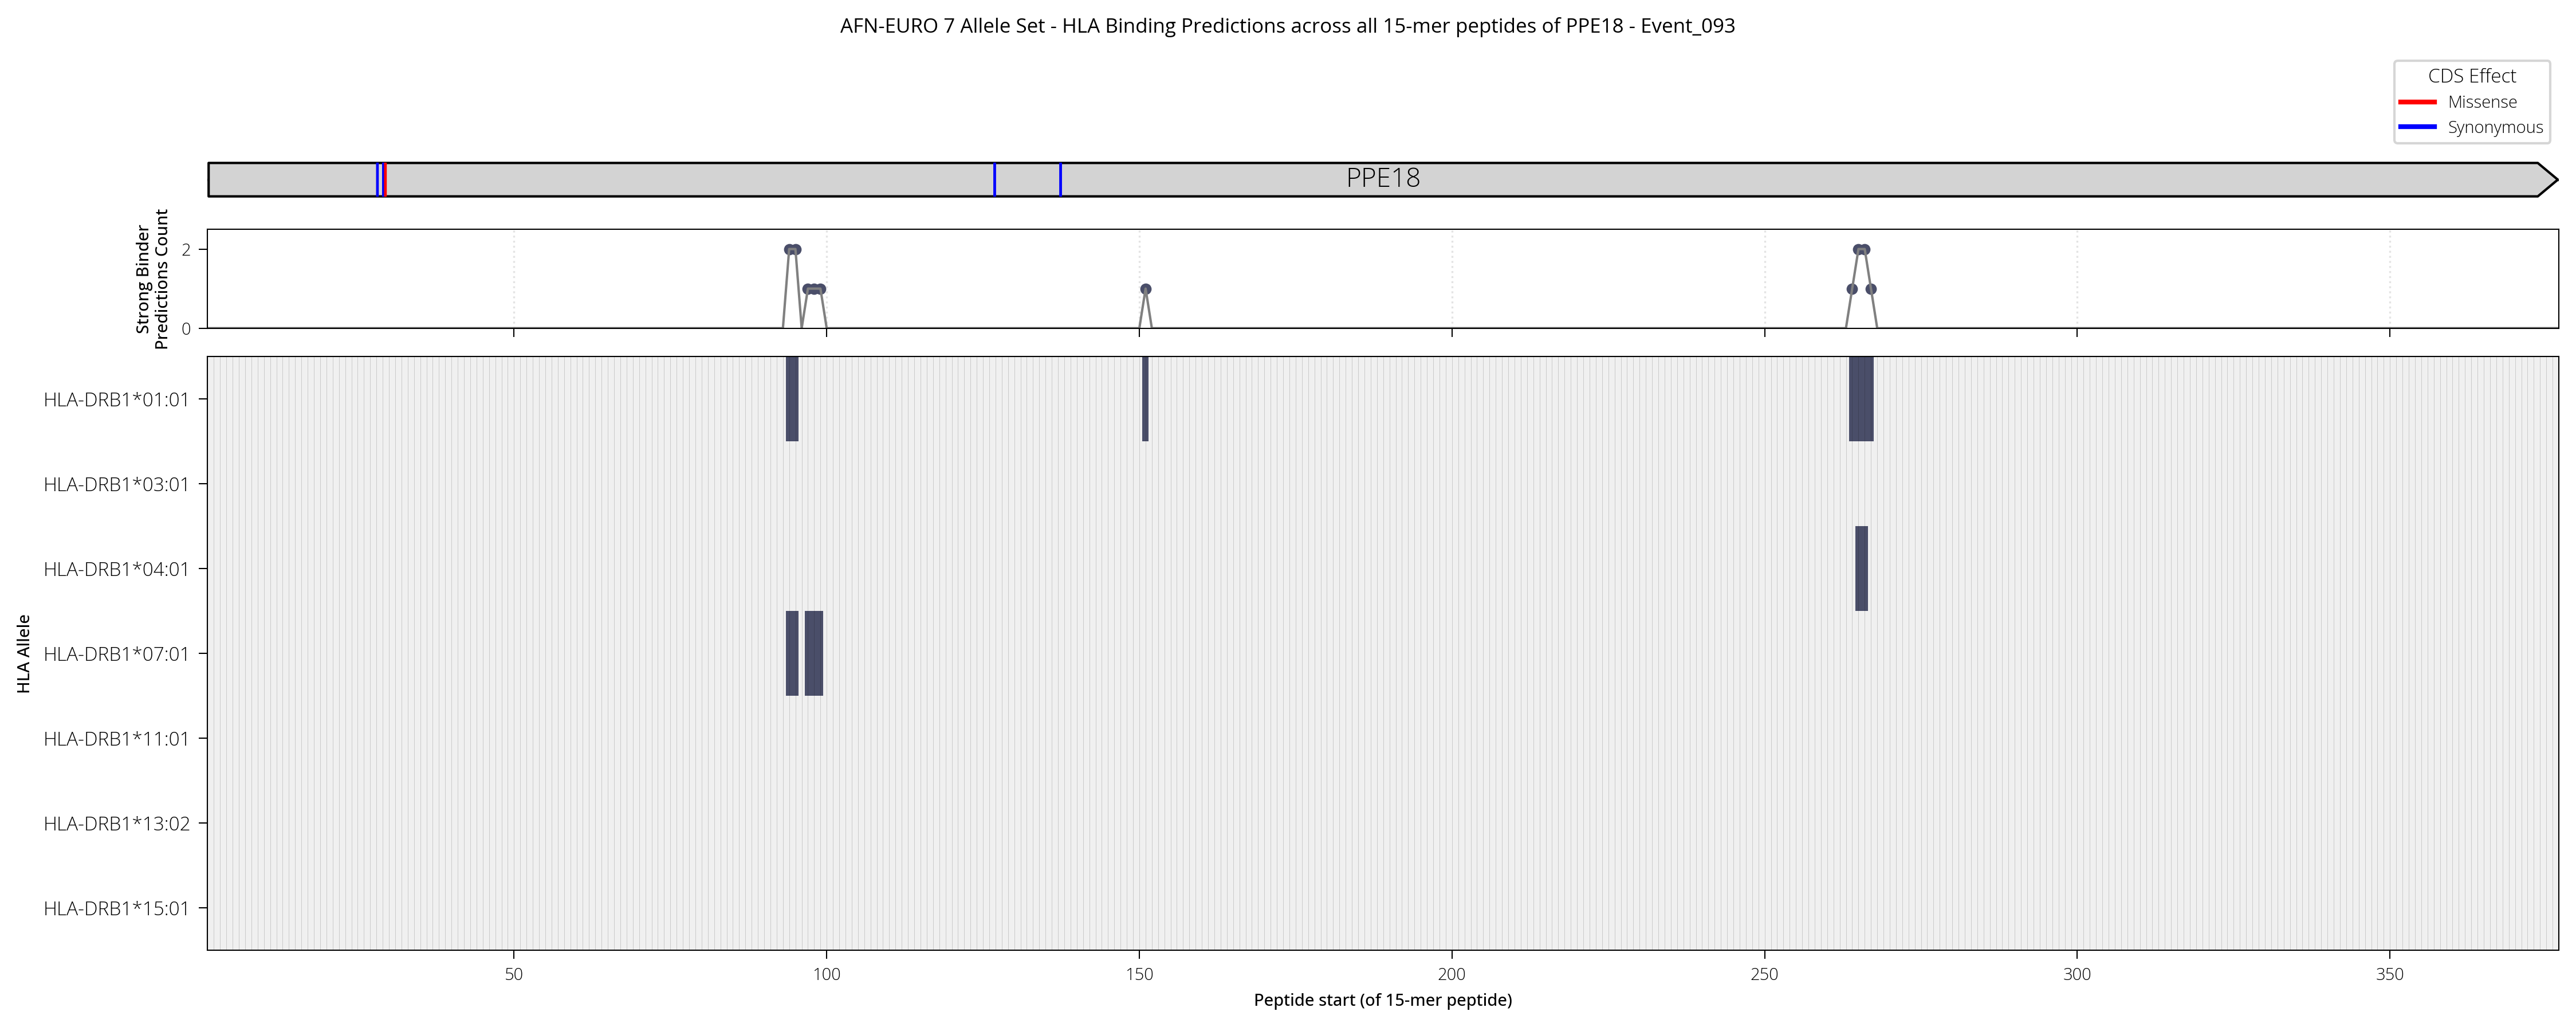

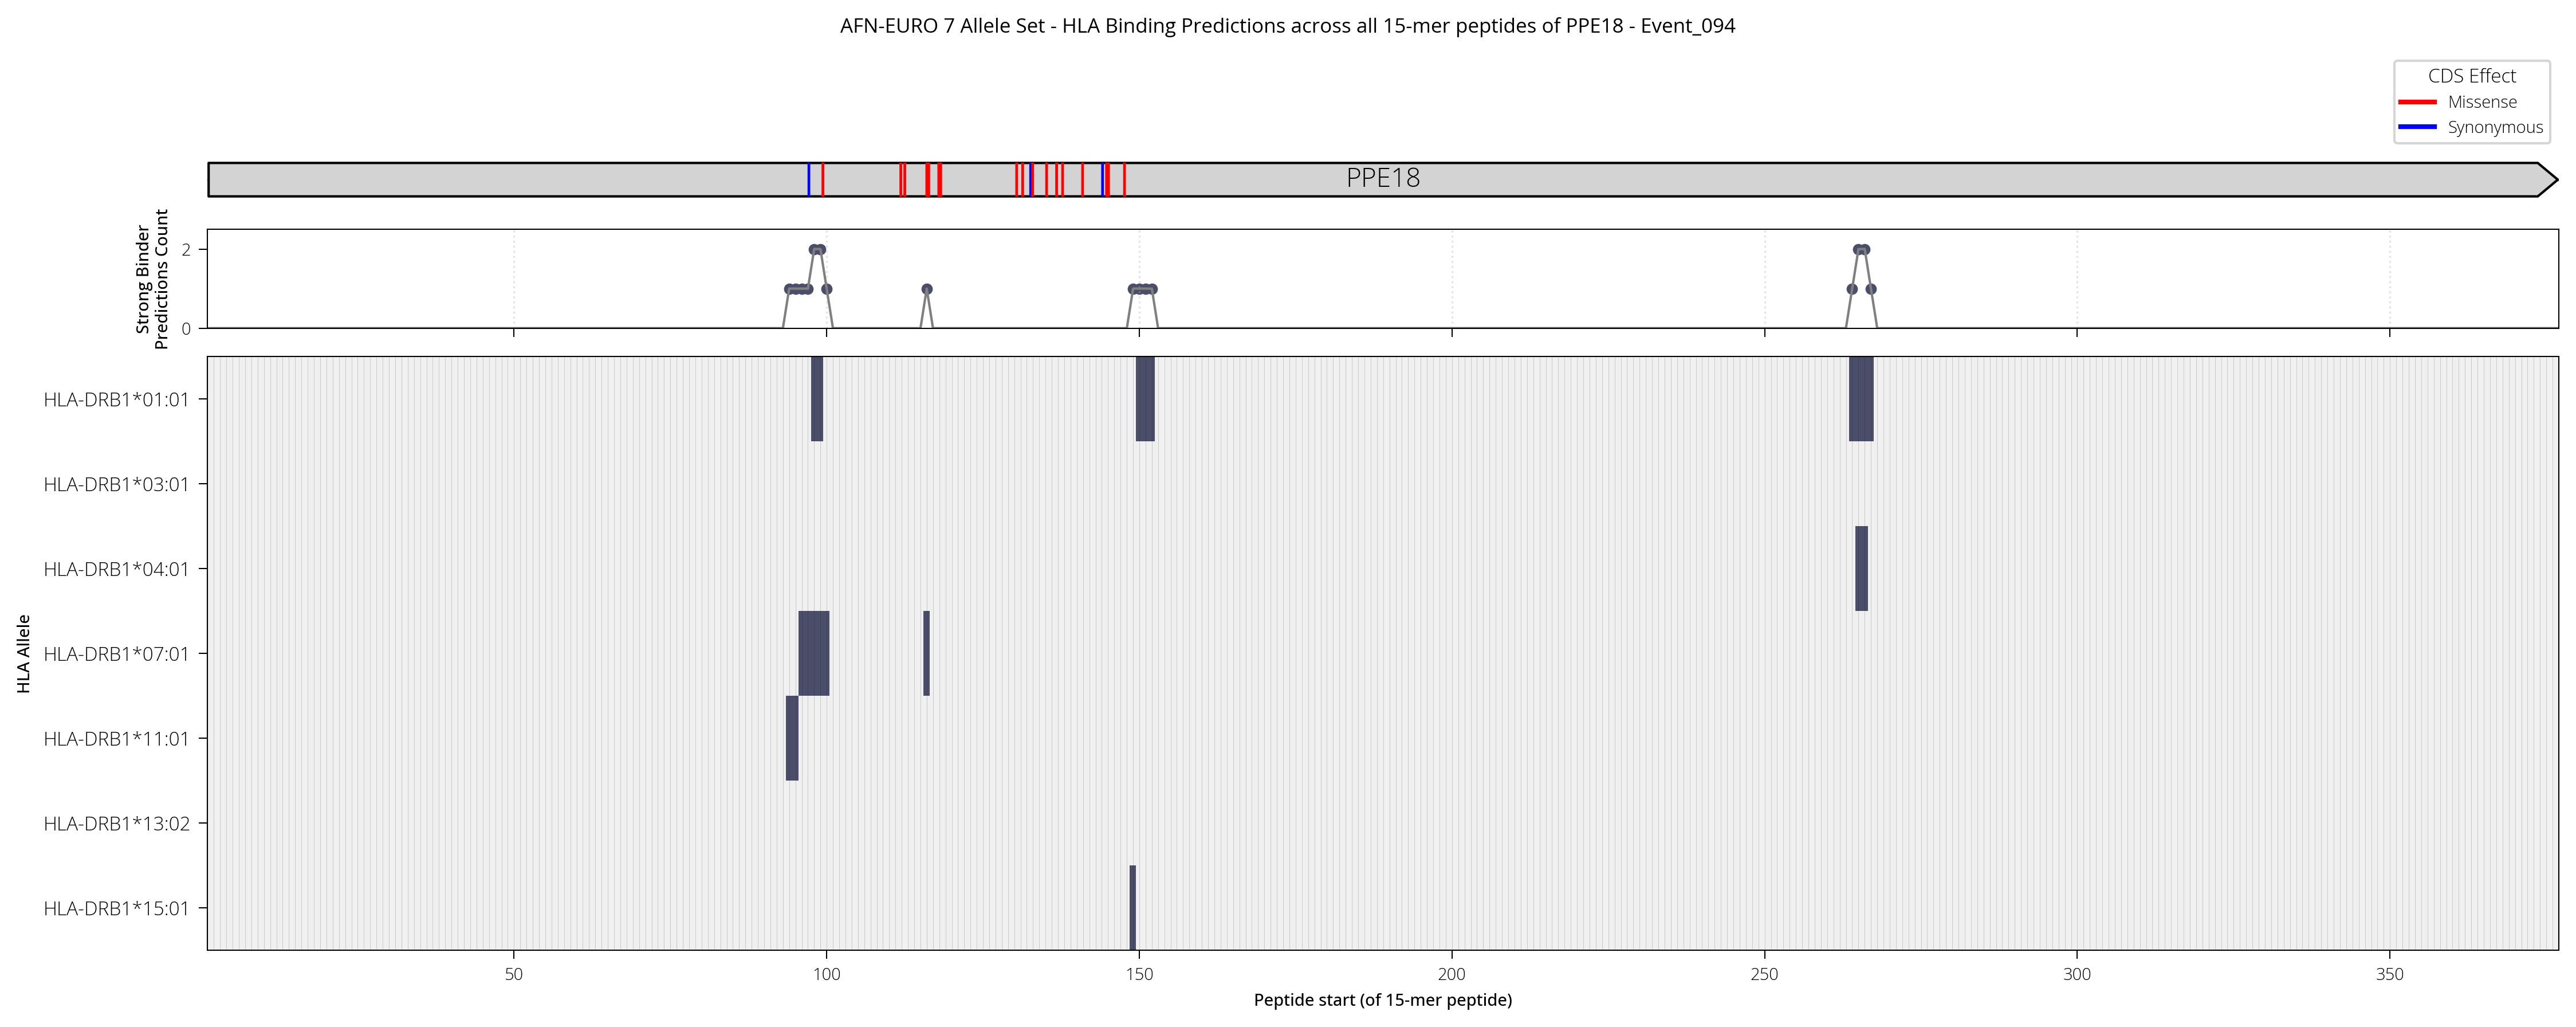

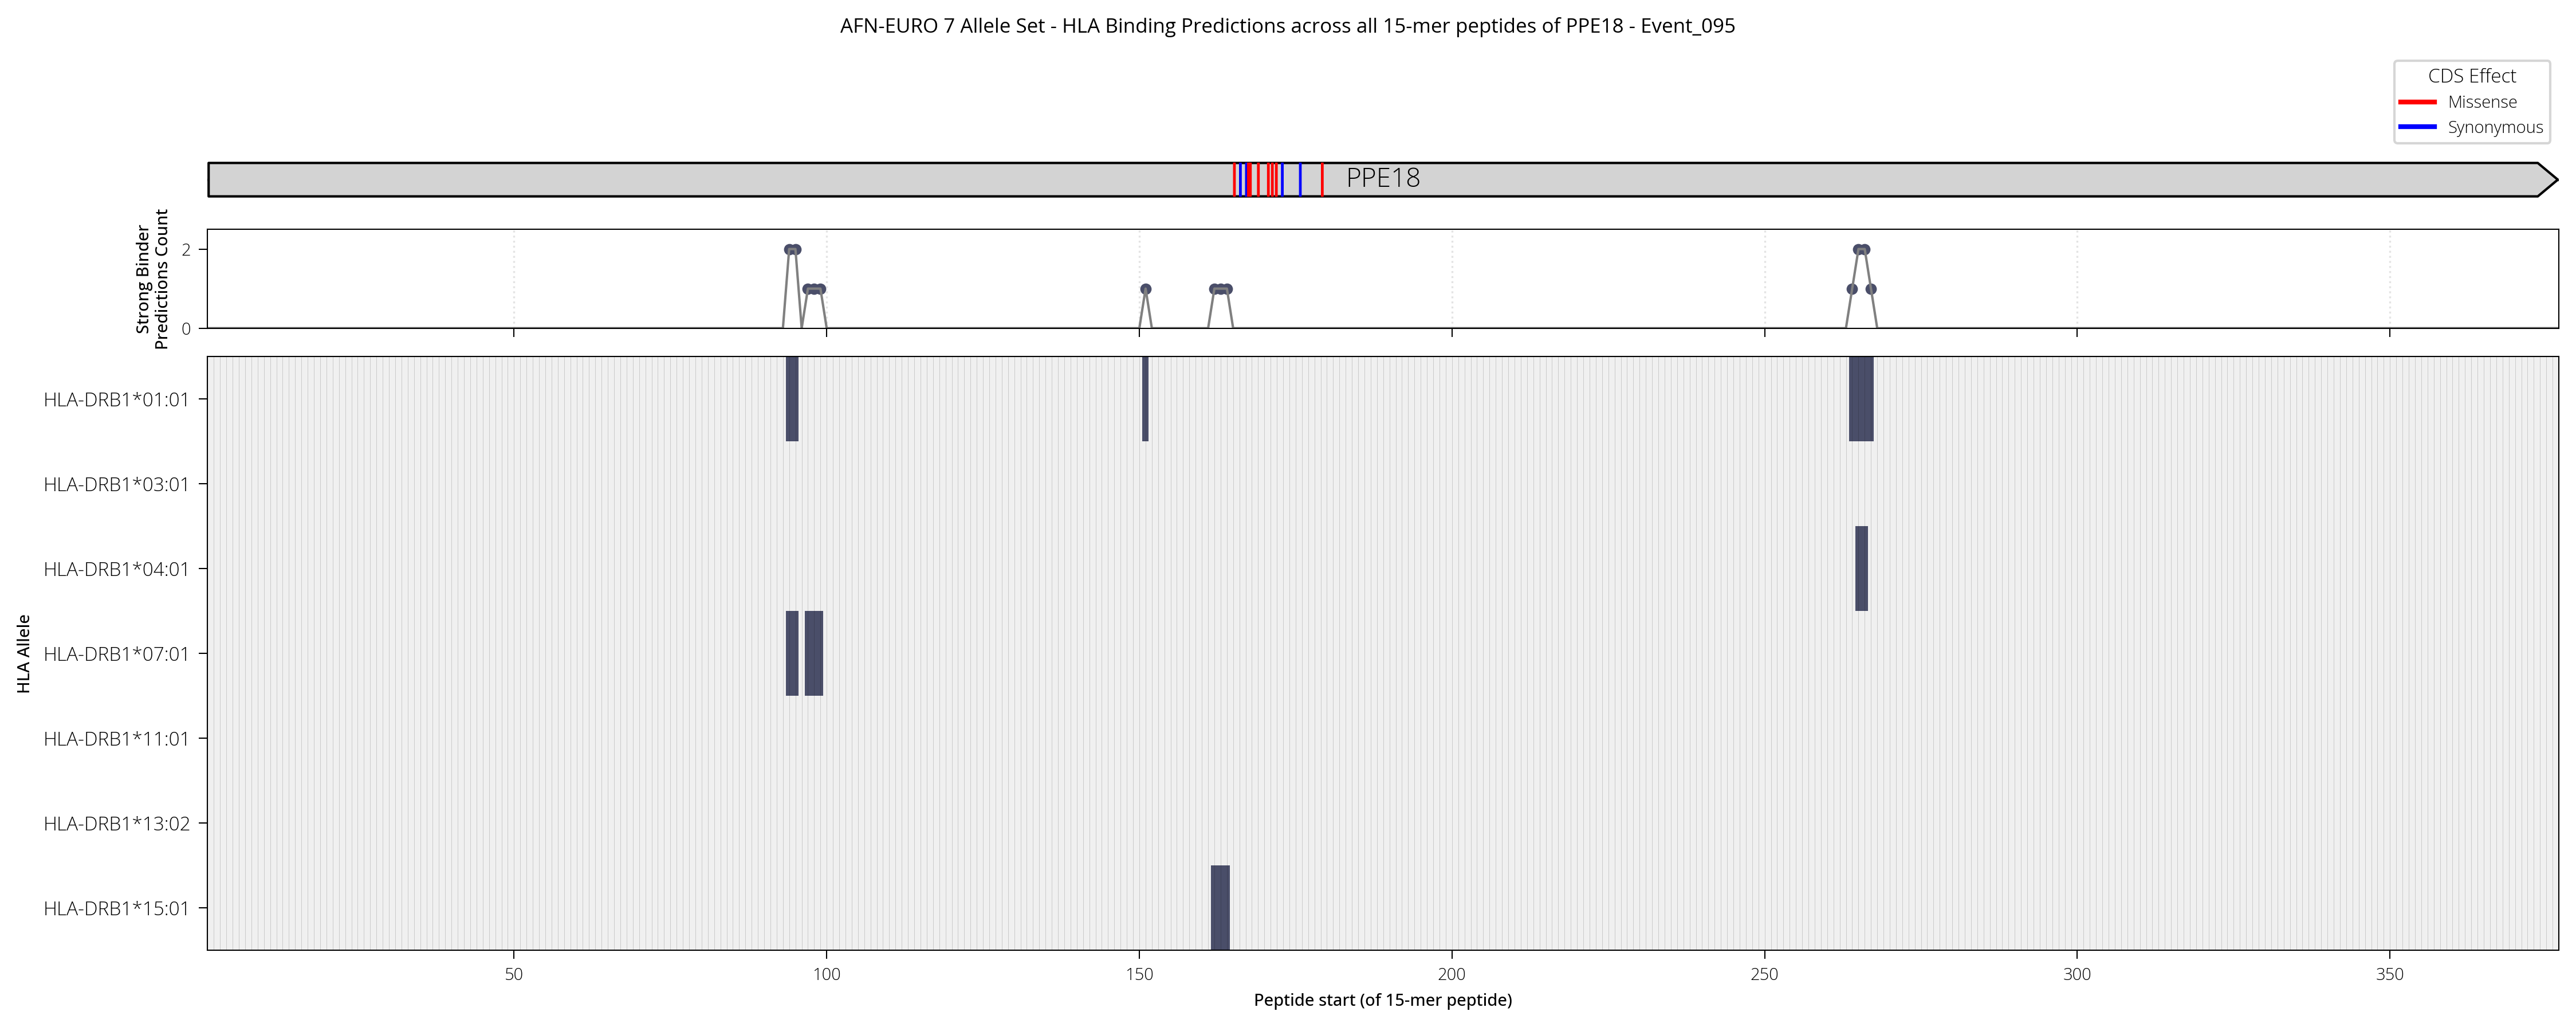

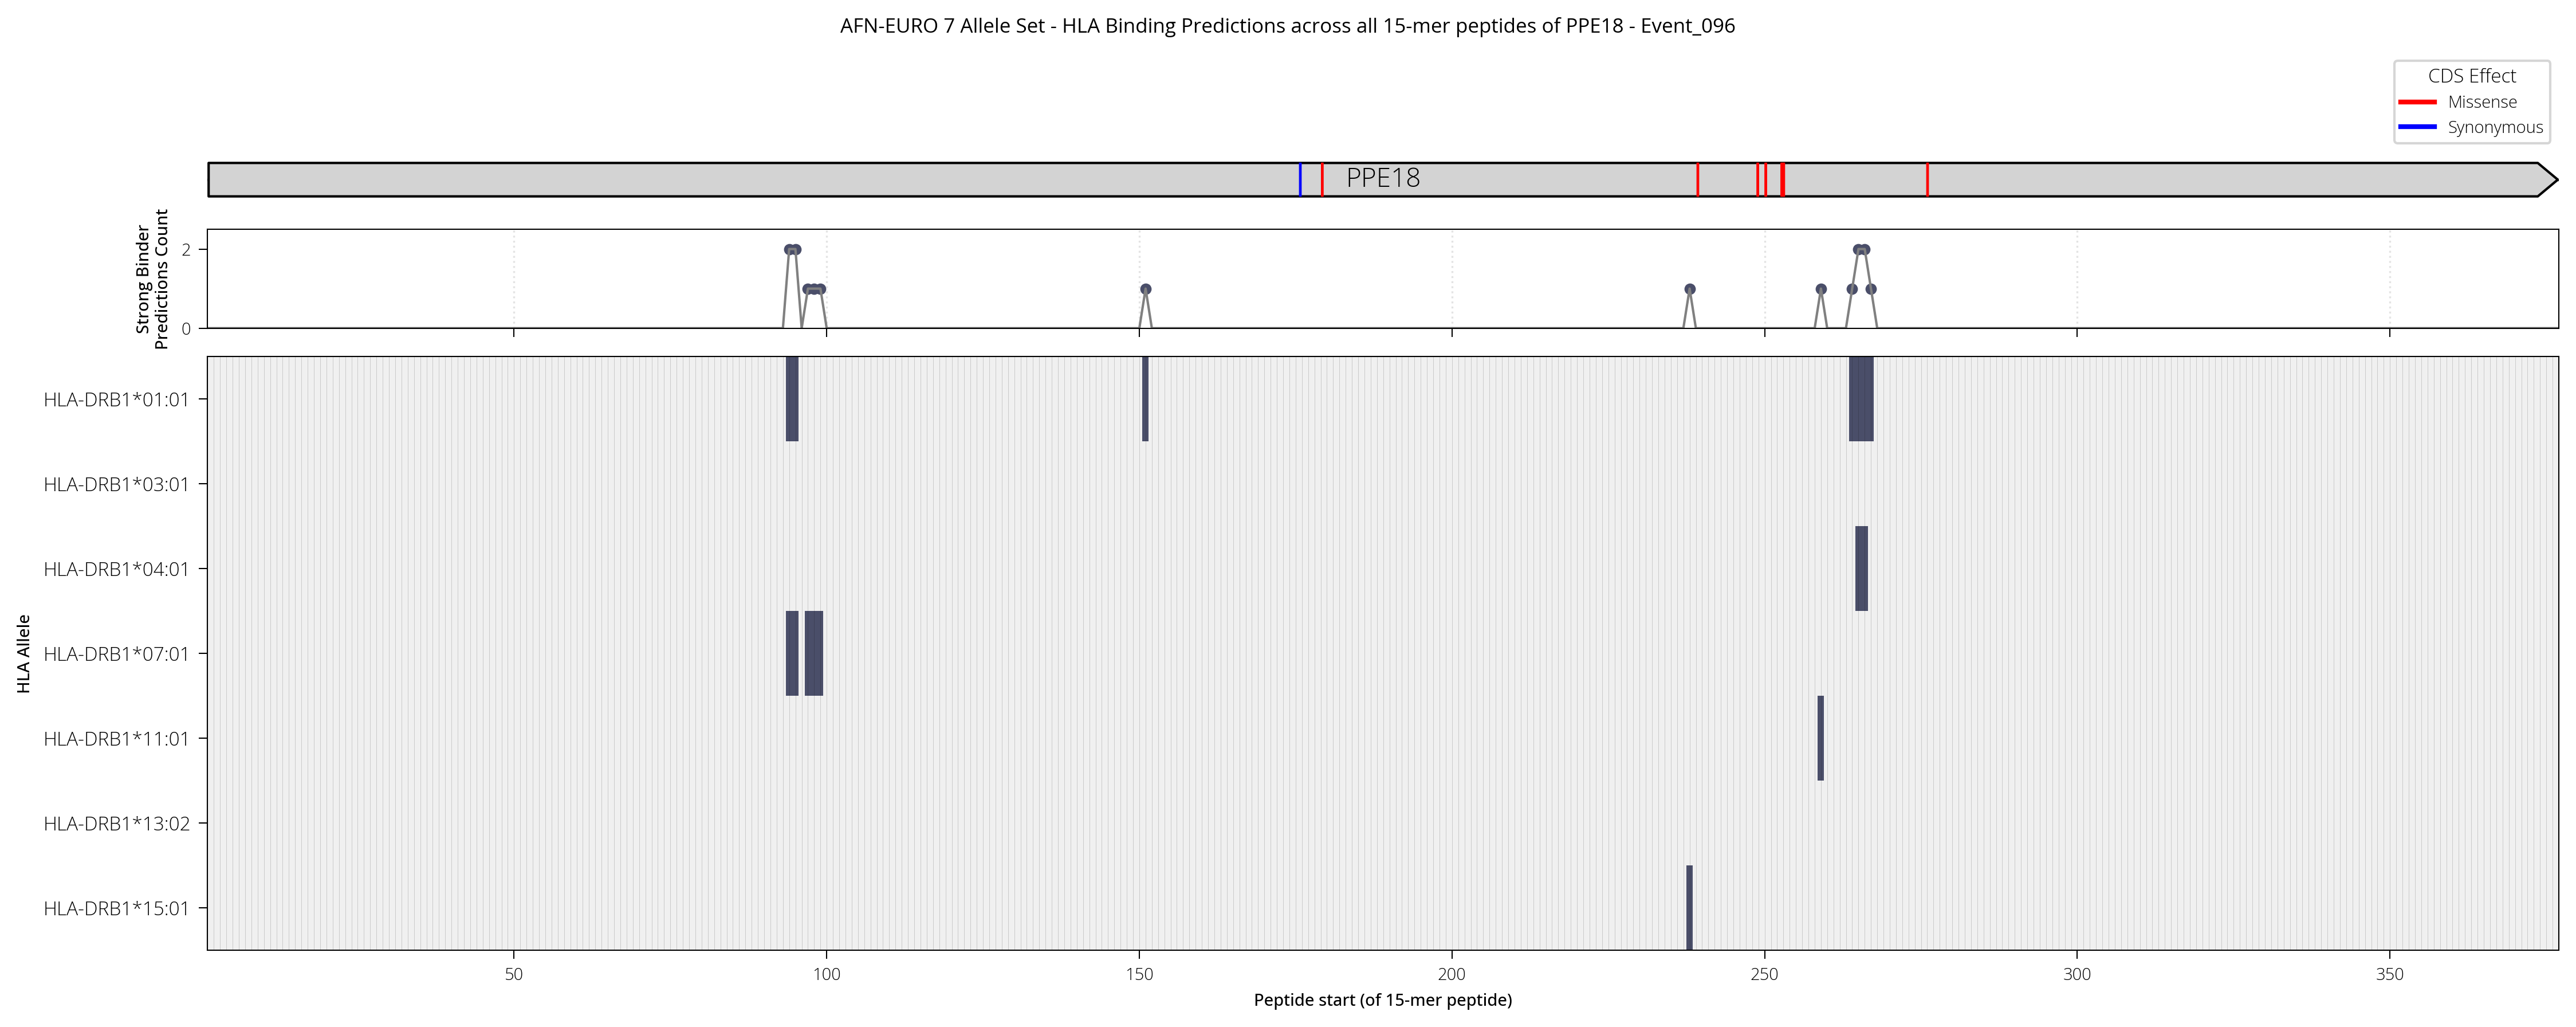

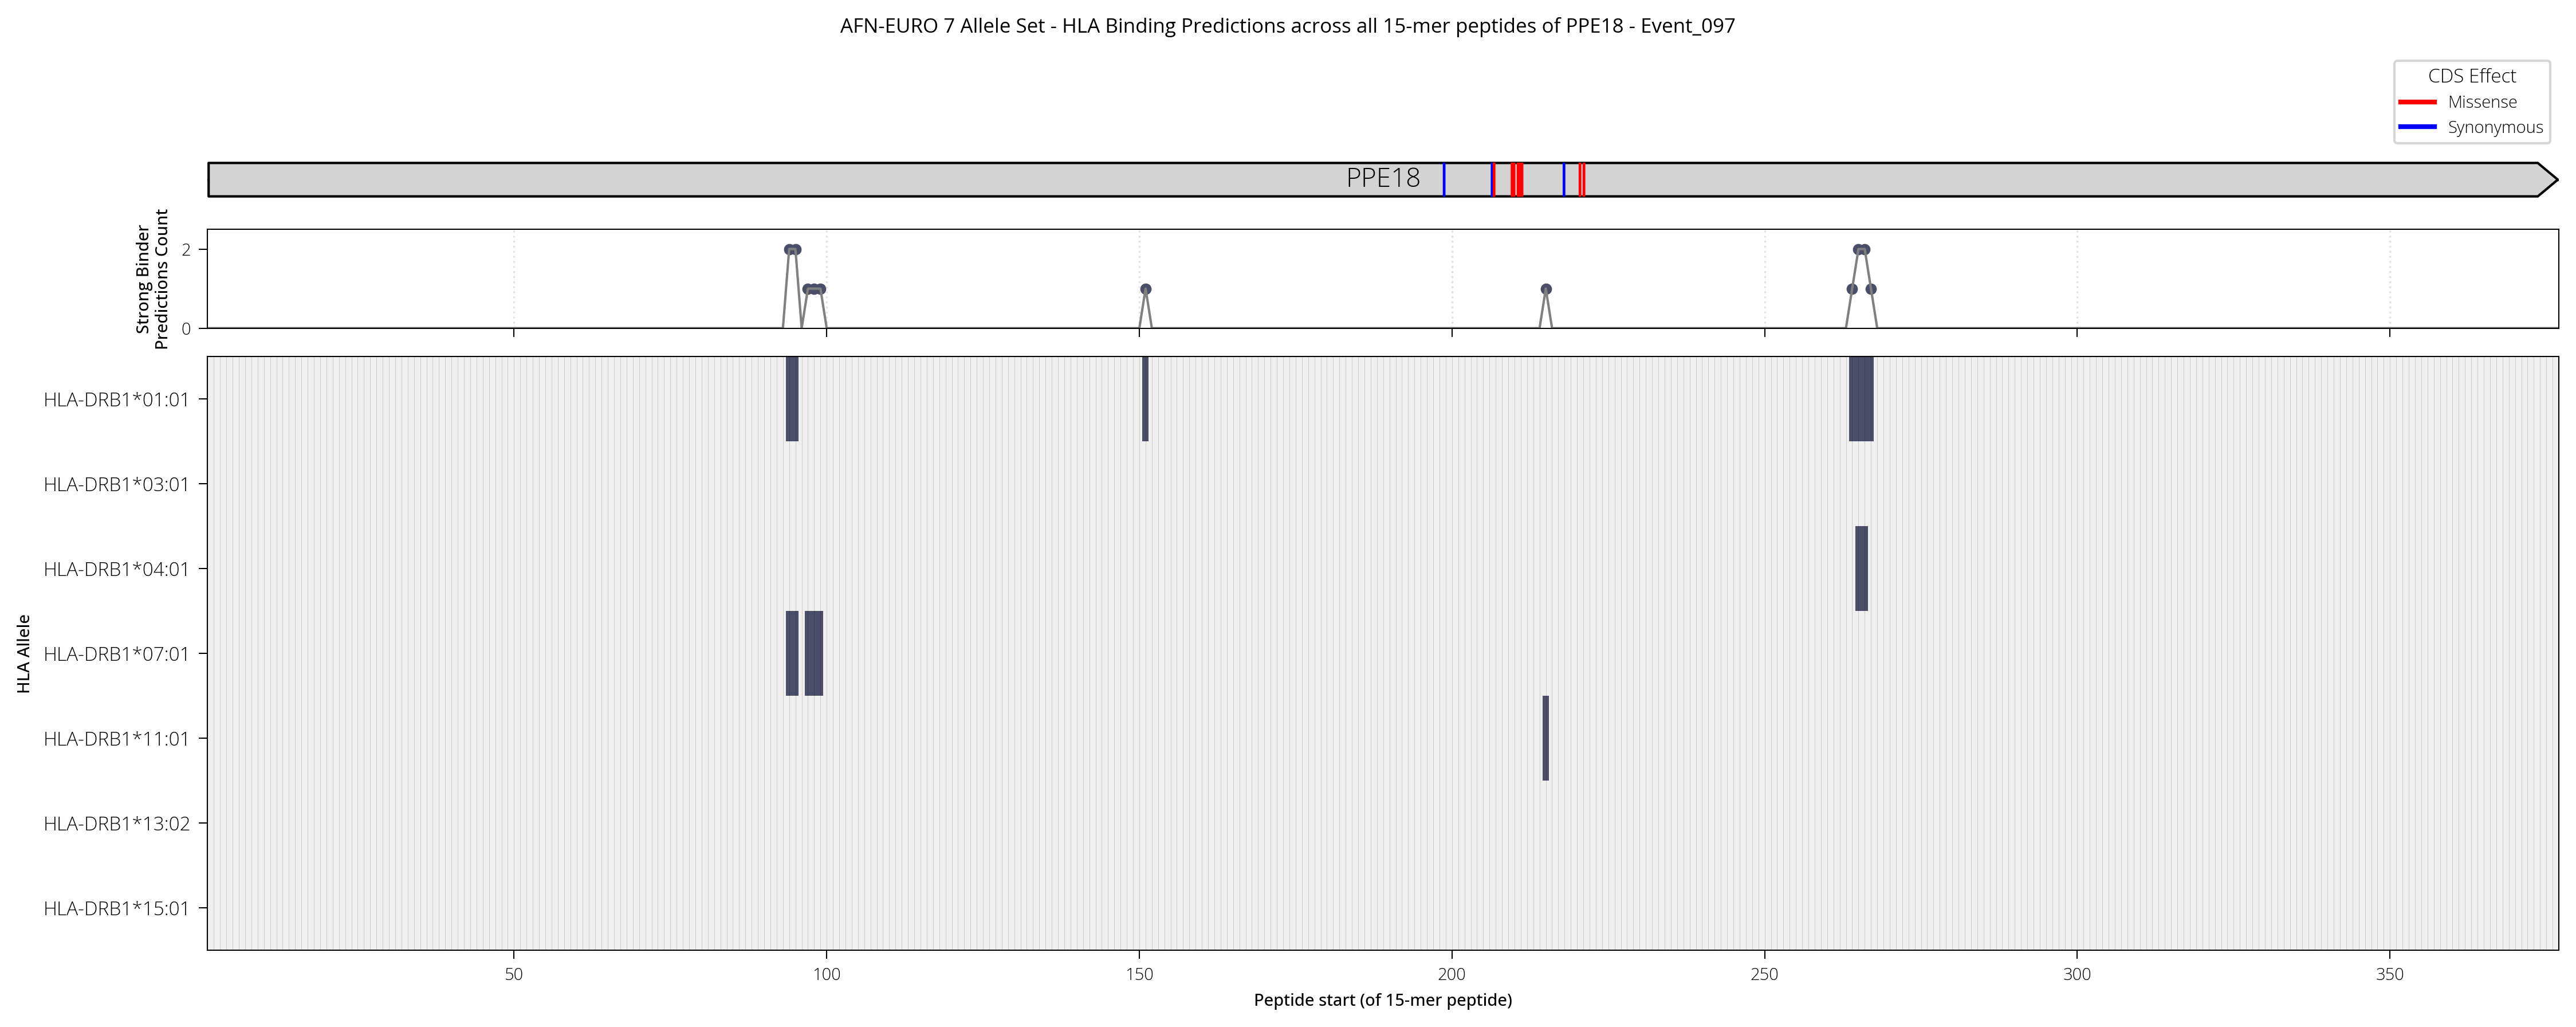

In [230]:

All_SeqAndEventIDs = ['H37Rv', 'Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']

for target_EventID in All_SeqAndEventIDs:

    GCE_Vs_HLABind_Baseline_E091_fig = plot_EventWiAnno_WiSBPred_Baseline_3panel(
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        in_EventID = target_EventID,
        in_GCEvents_All_DF = pGCE_DF,
        in_Gubbins_SNPs_DF = Gub_SNPs_V2_DF,
        i_MainResults_Dict = ResultsDict_AFN_EURO_7A,
        Viz_Start = PPE18_Viz_Start,
        Viz_End = PPE18_Viz_End,
        in_ylim = (-5, 5),
        show_snp_labels=False,
        i_figsize = (15, 6),
        title = f"AFN-EURO 7 Allele Set - HLA Binding Predictions across all 15-mer peptides of PPE18 - {target_EventID}",
        allele_order = HLA2_AFN_Euro_Set_7A,
    )


### `IEDB 27` HLA Alleles

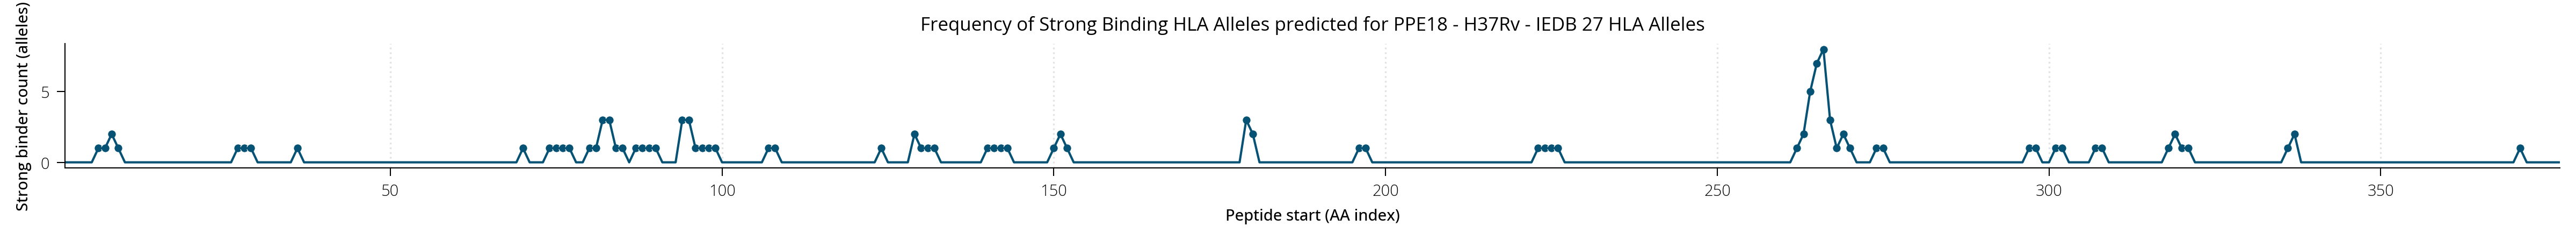

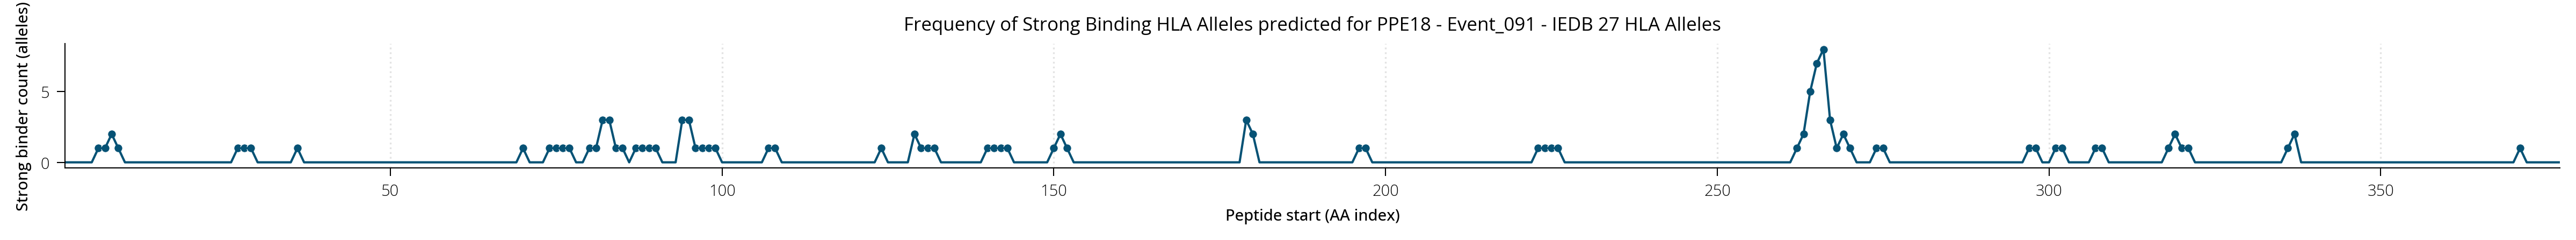

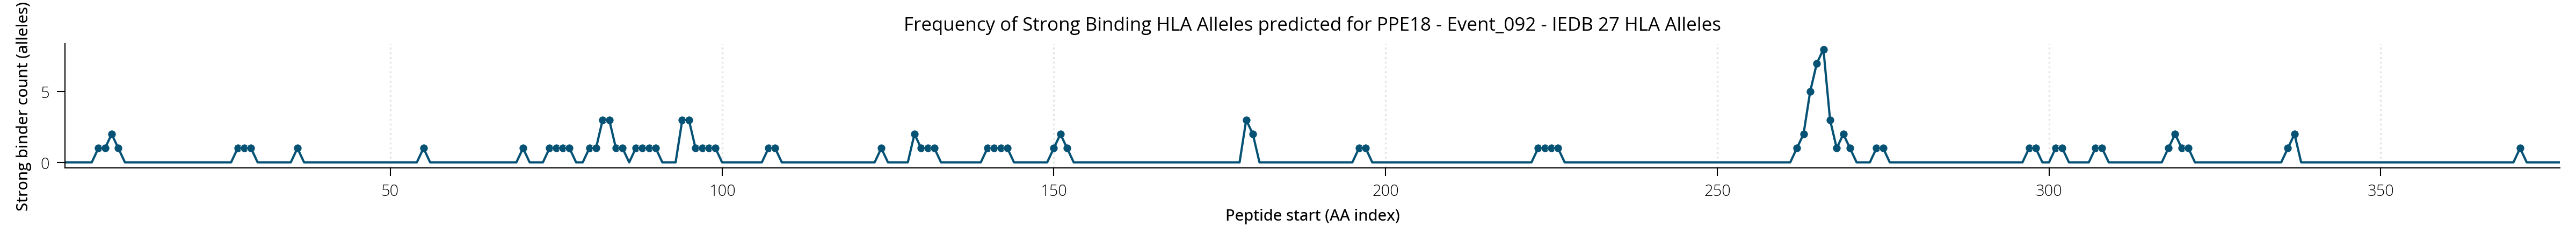

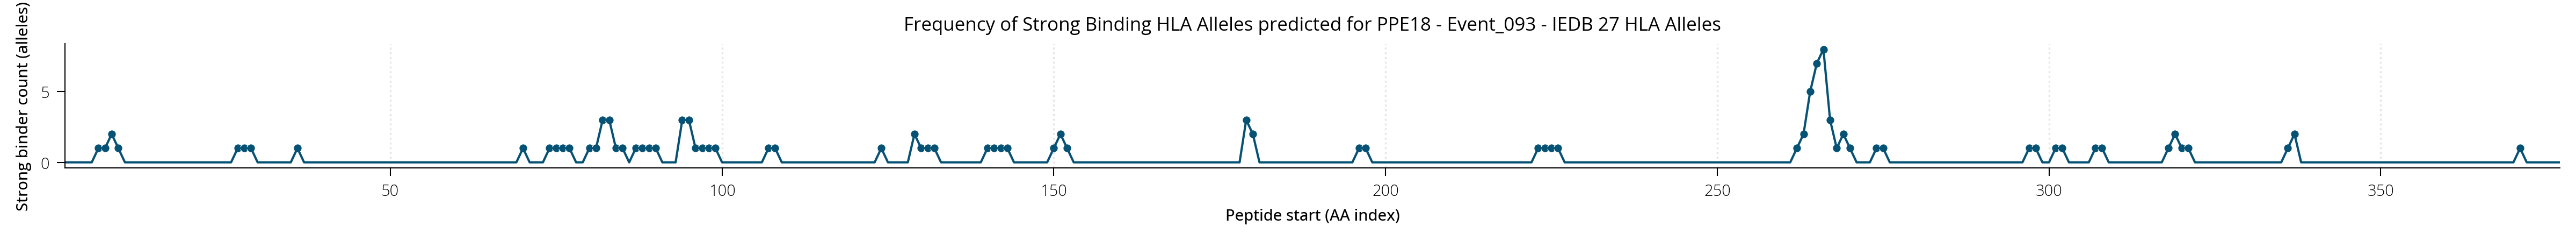

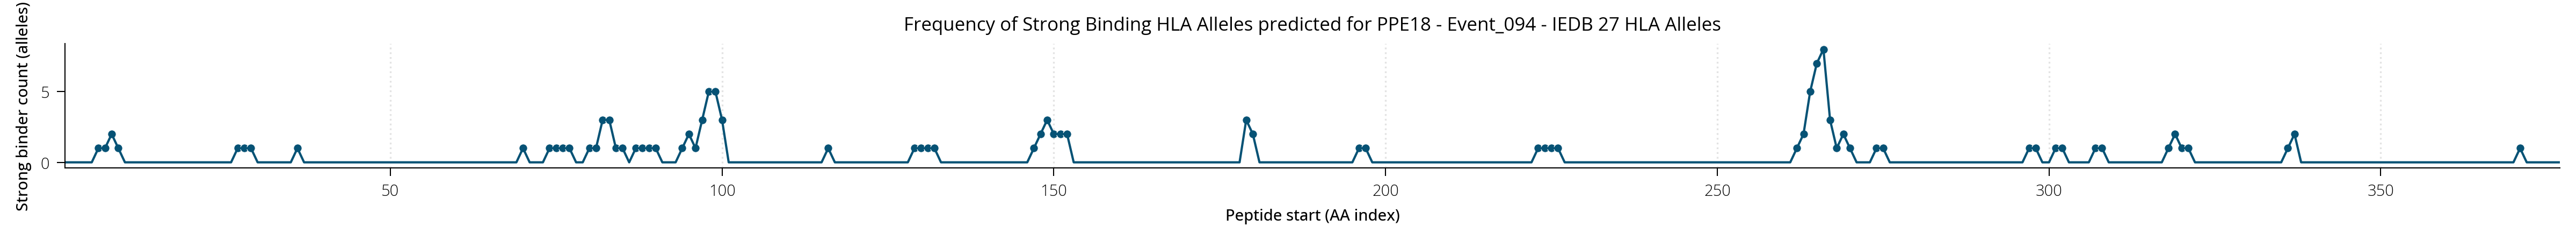

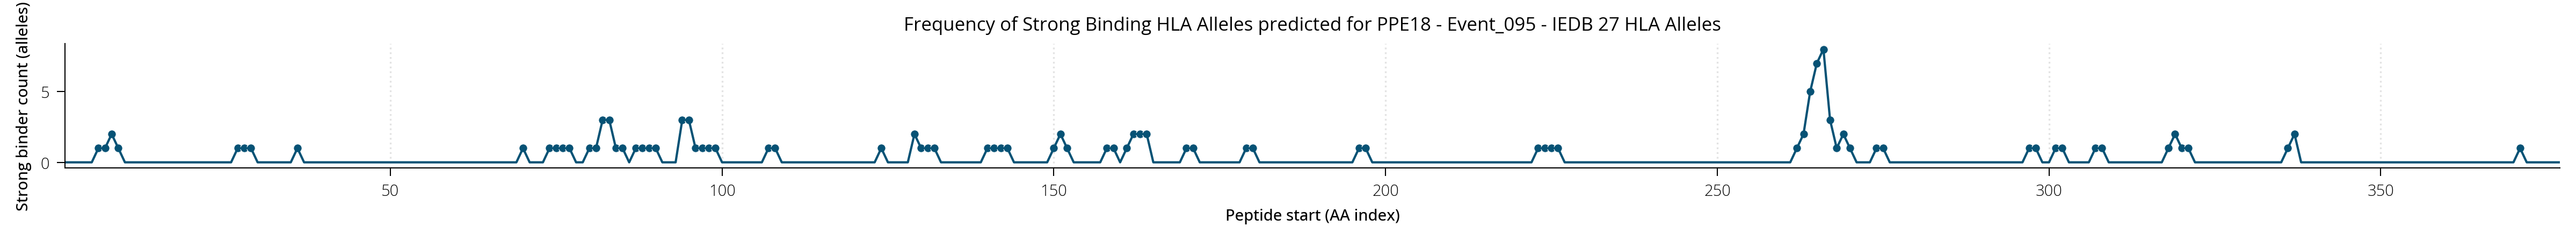

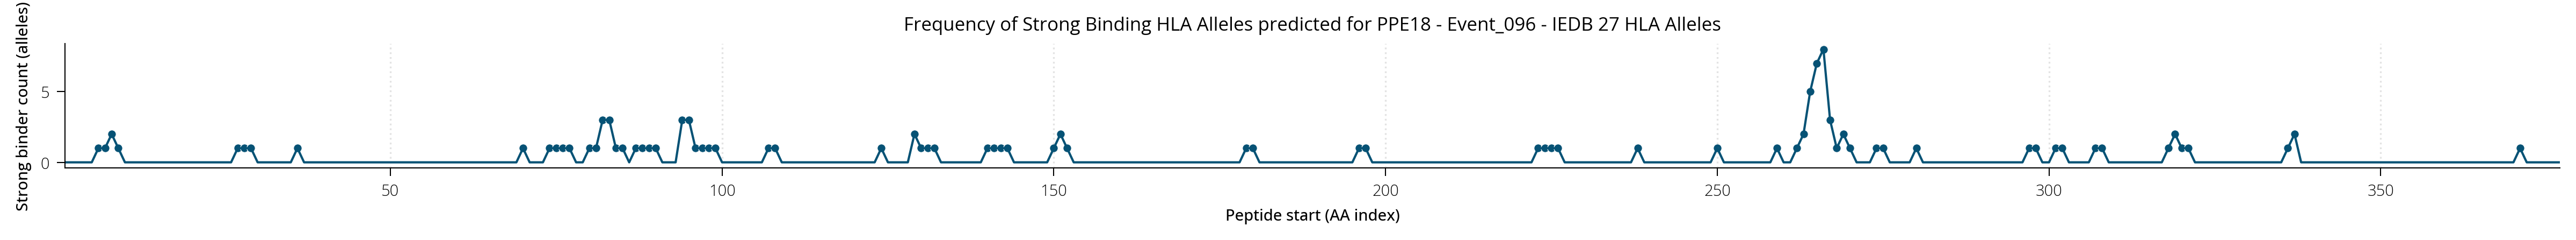

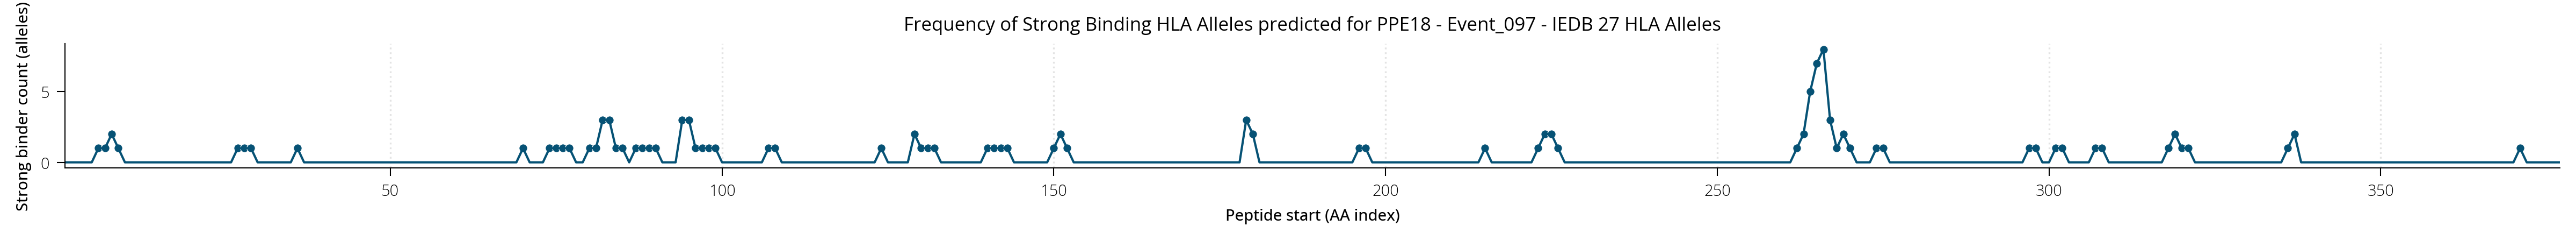

In [231]:

All_SeqAndEventIDs = ['H37Rv', 'Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']

for target_EventID in All_SeqAndEventIDs:

    i_fig, i_ax, i_sb_df = plot_sb_by_pos_singleseq(ResultsDict_IEDB_27A,
                                                    seq_key = target_EventID,
                                                    figsize=(16, 1.5),
                                                    title = f"Frequency of Strong Binding HLA Alleles predicted for PPE18 - {target_EventID} - IEDB 27 HLA Alleles")


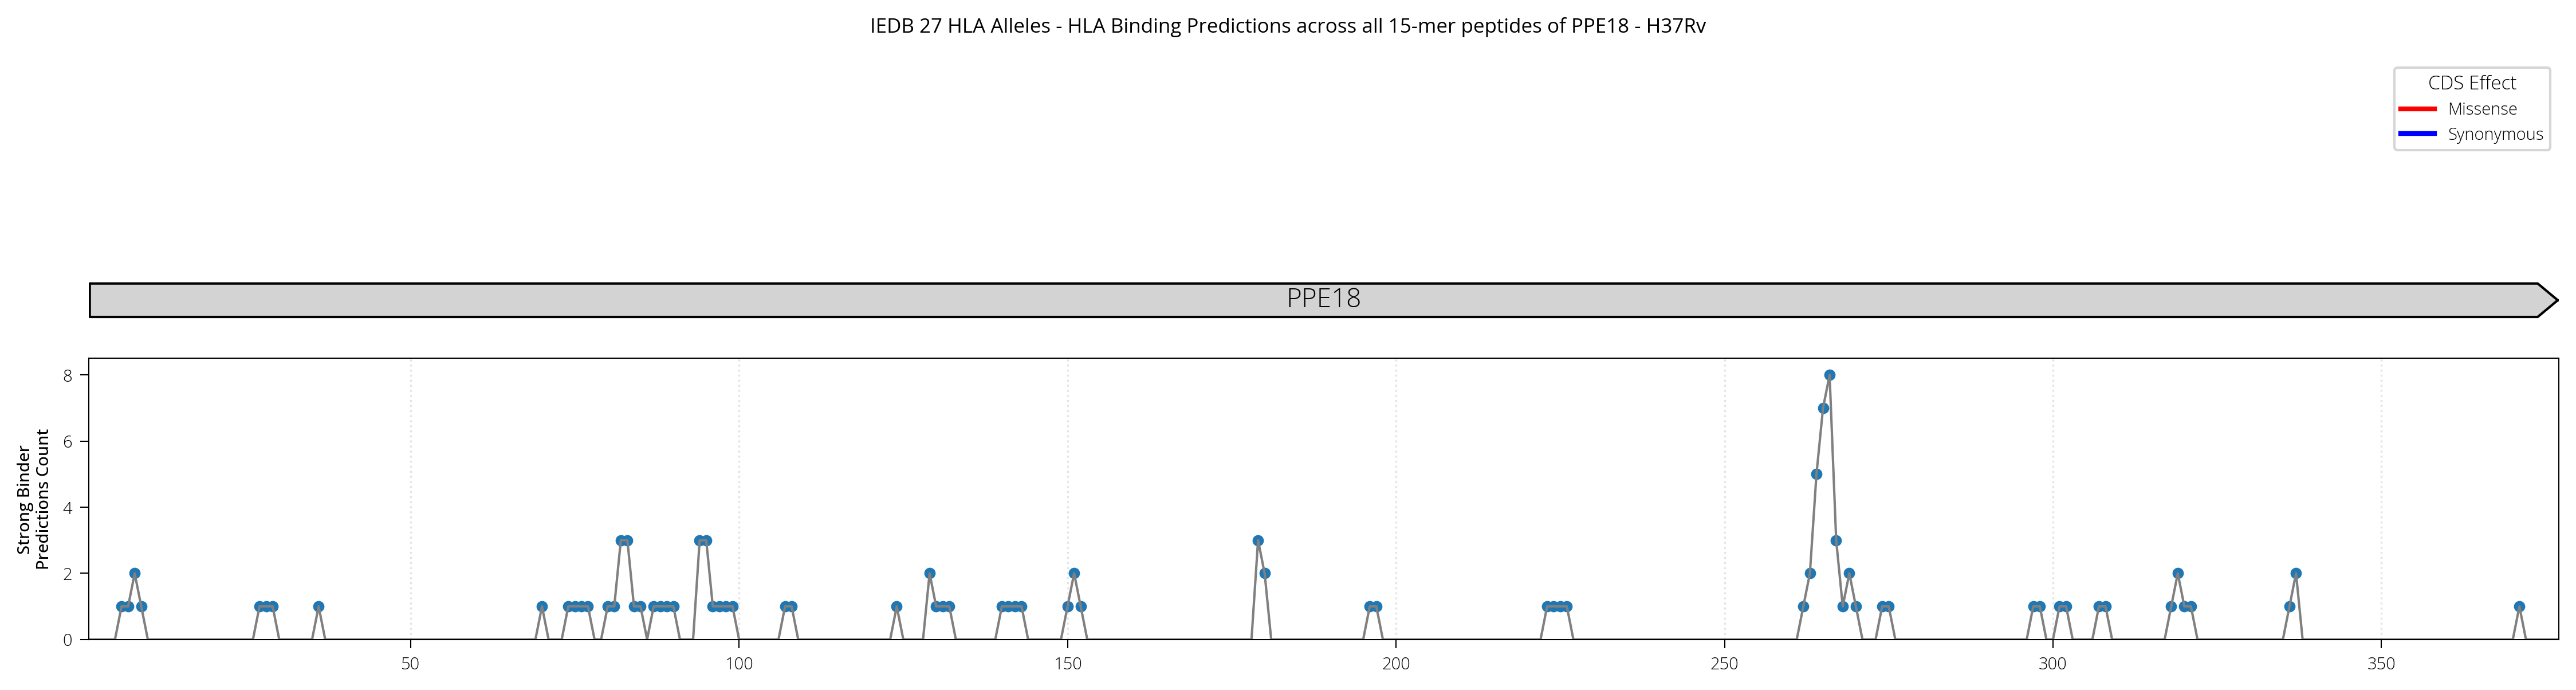

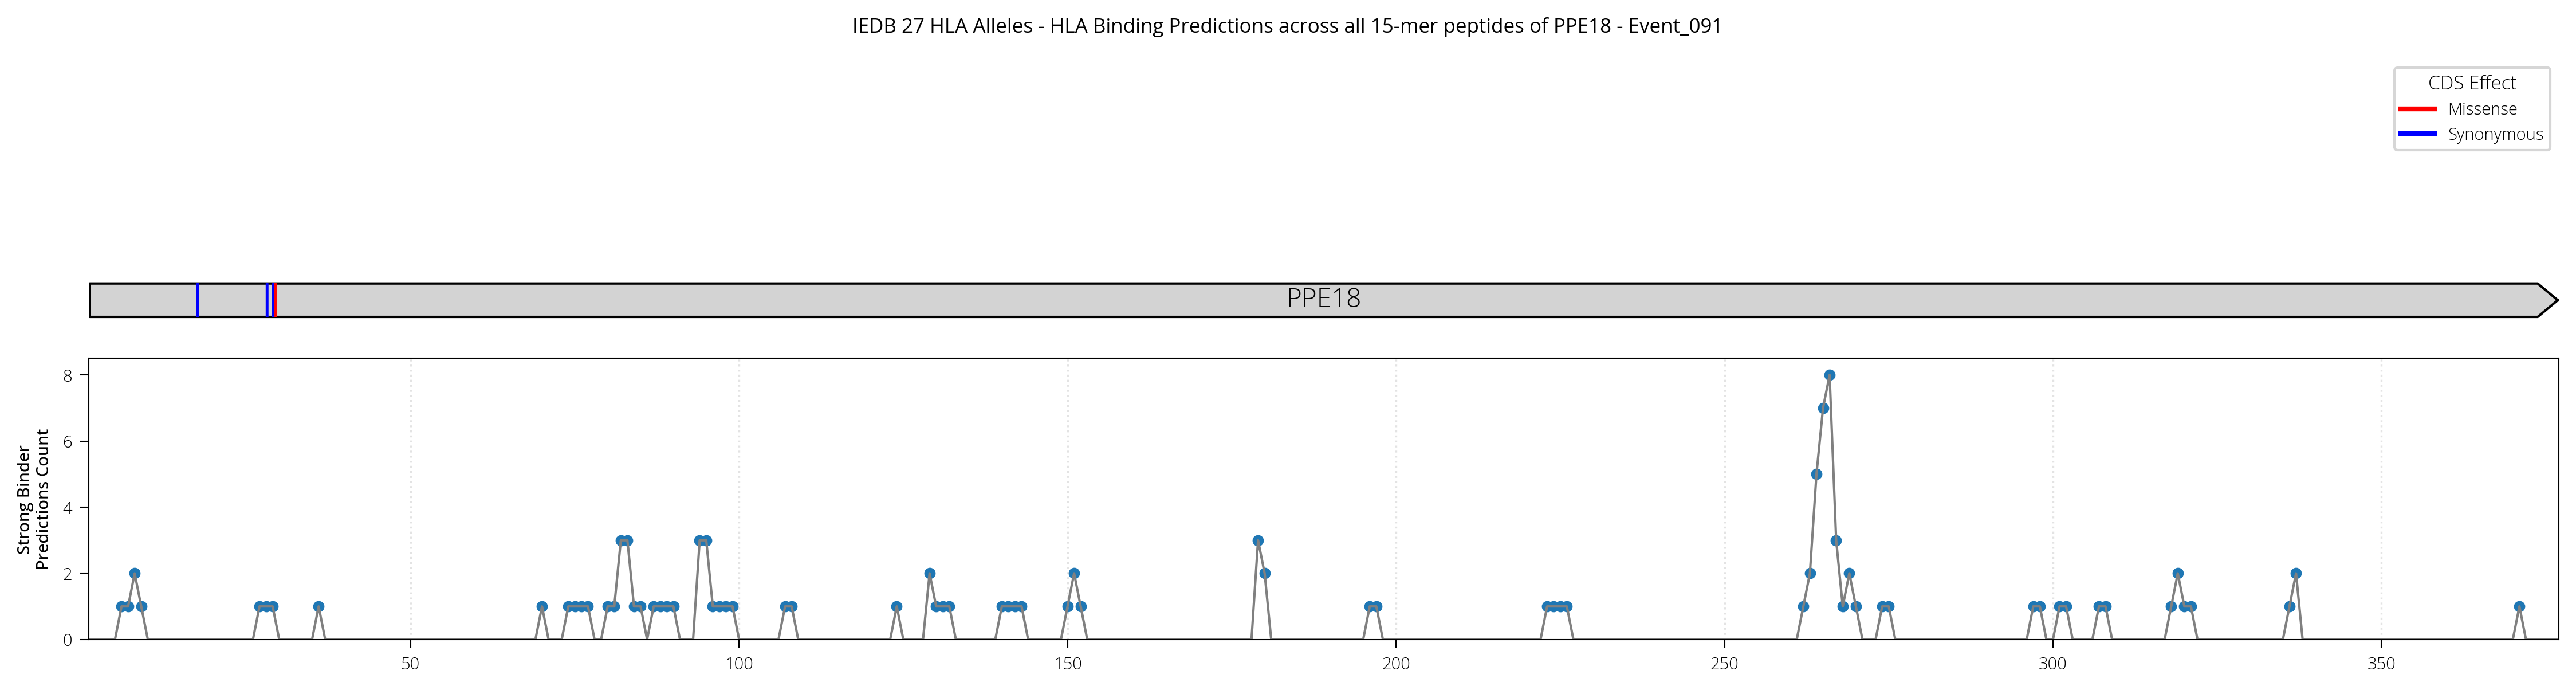

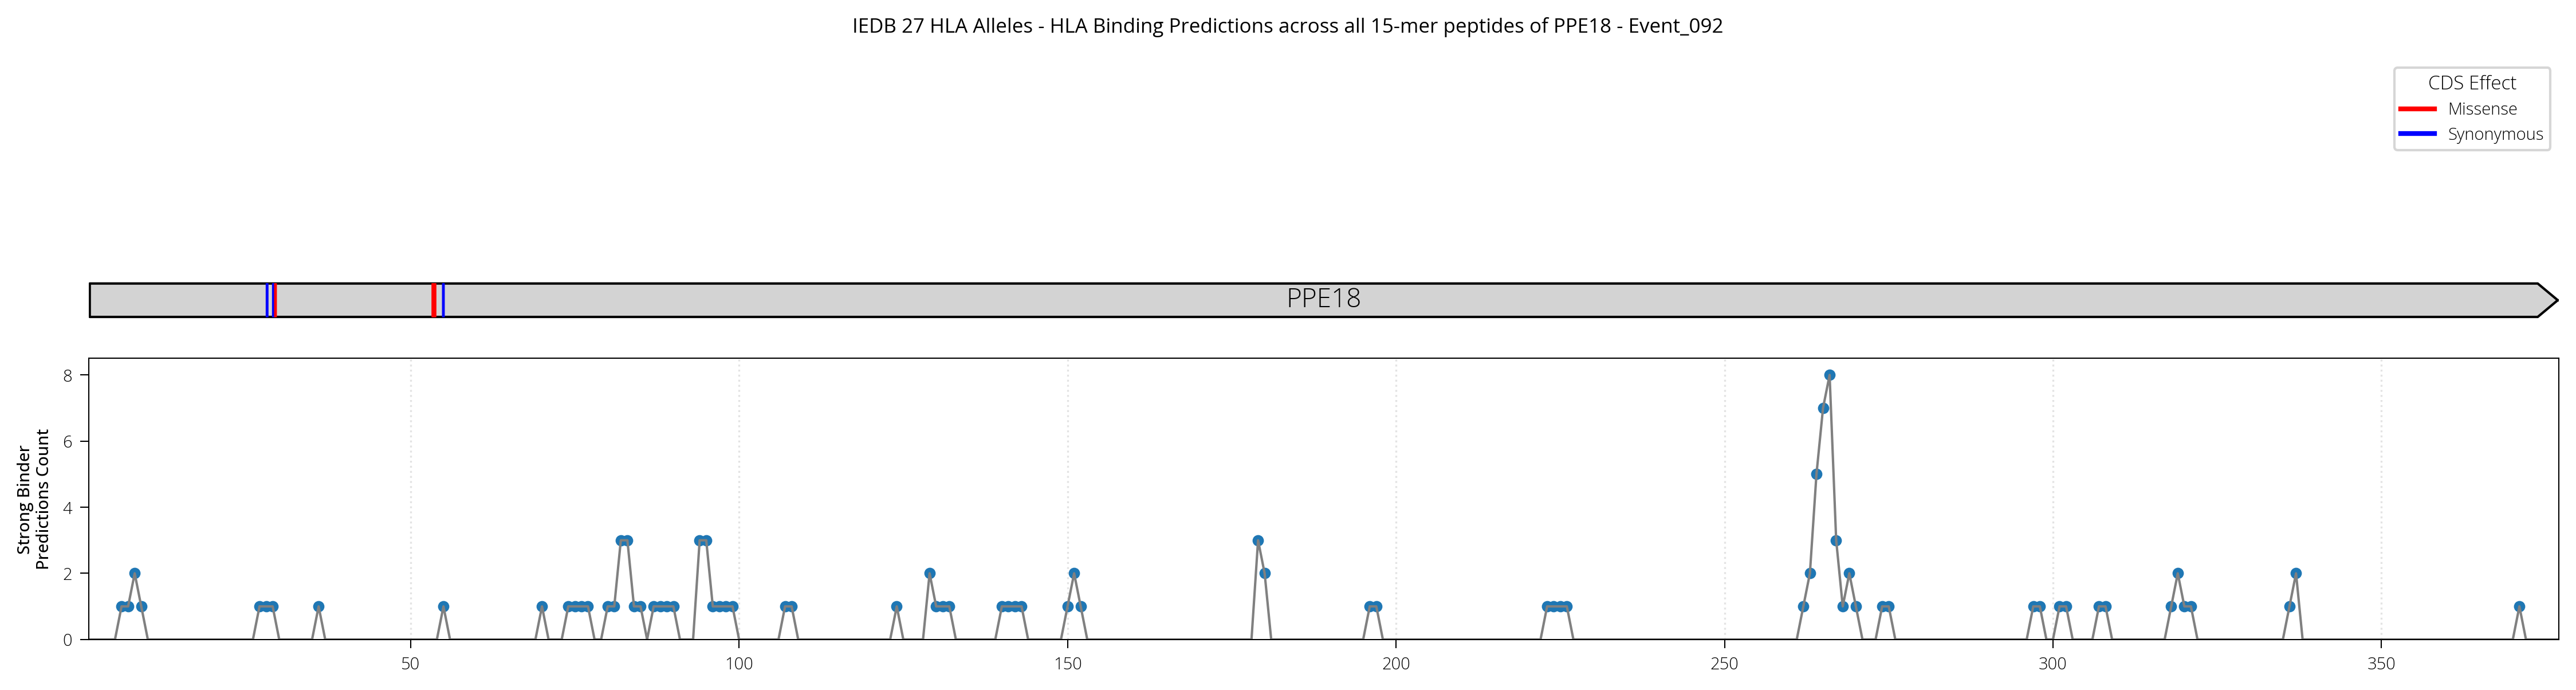

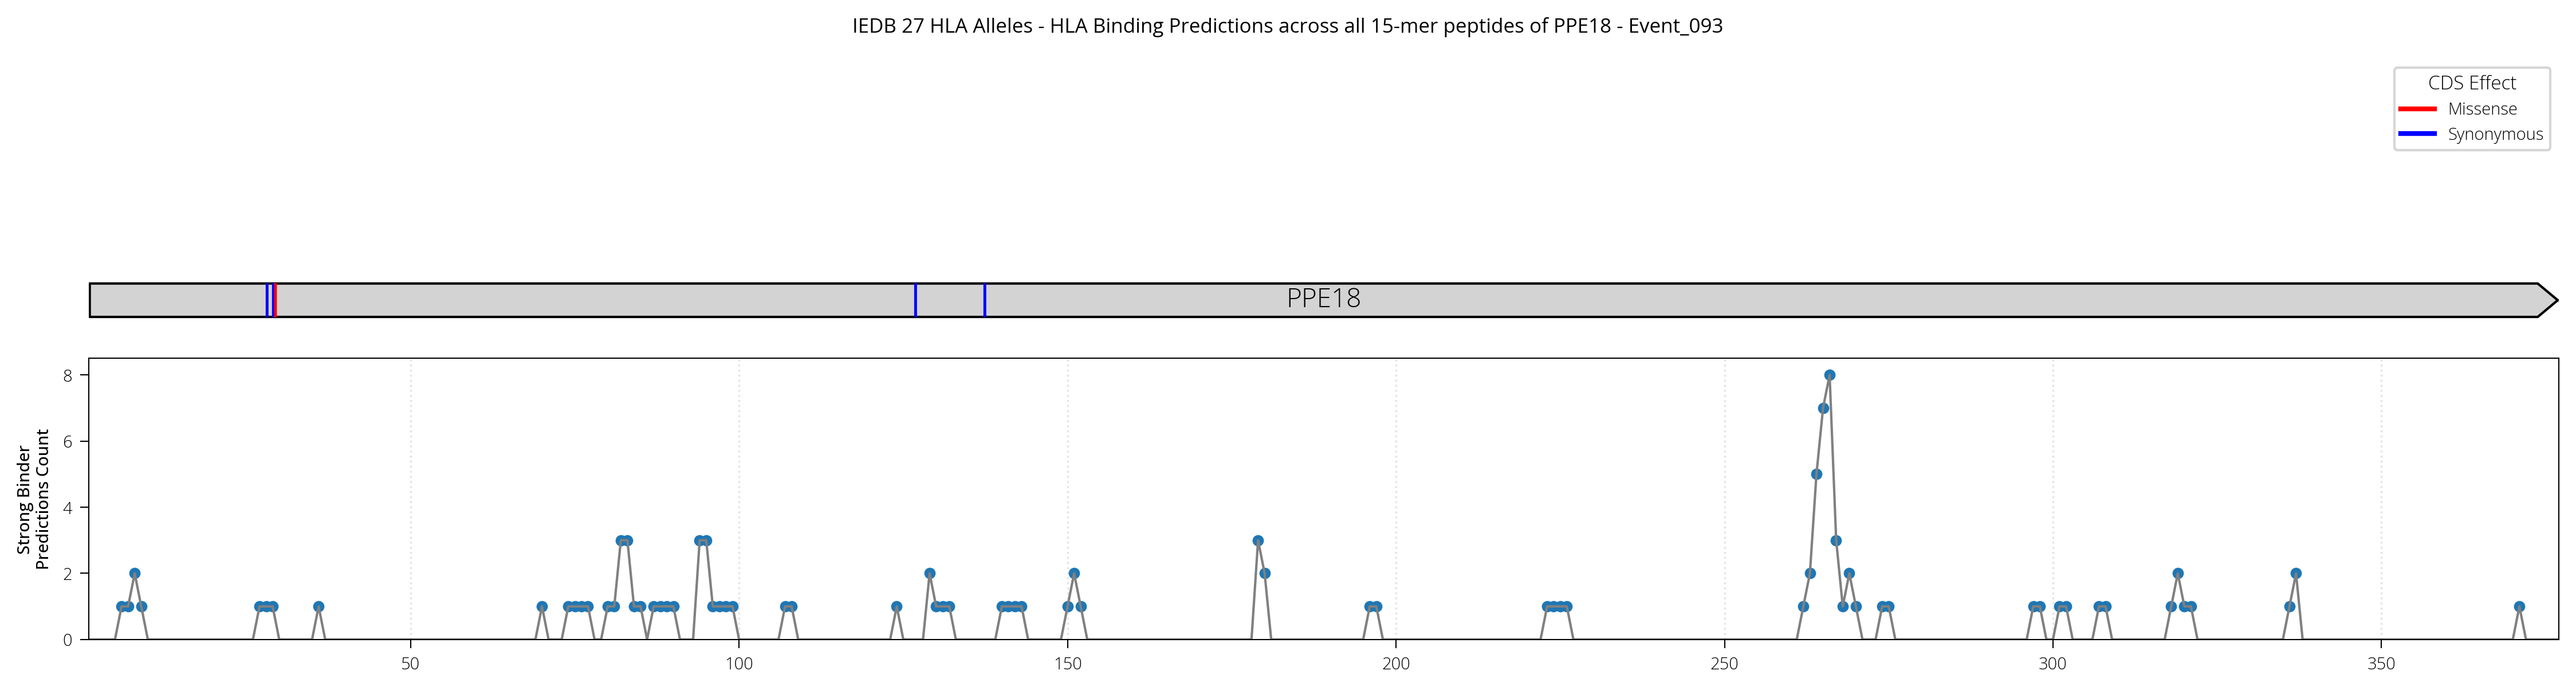

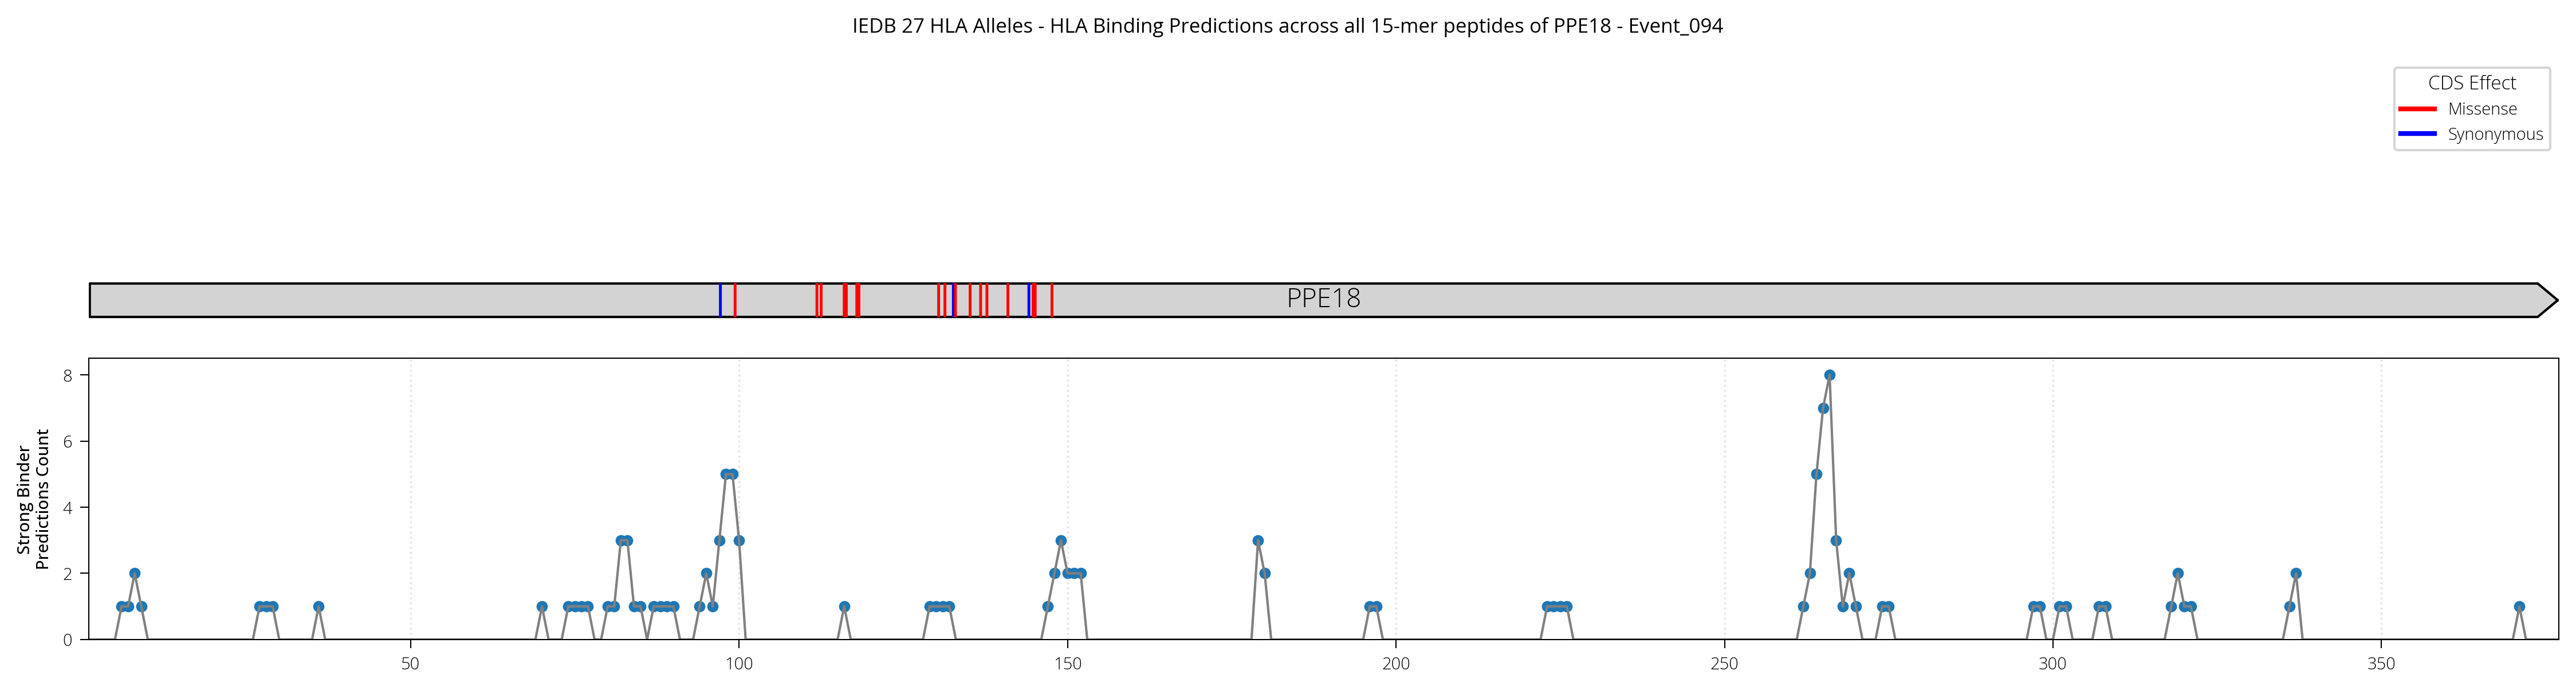

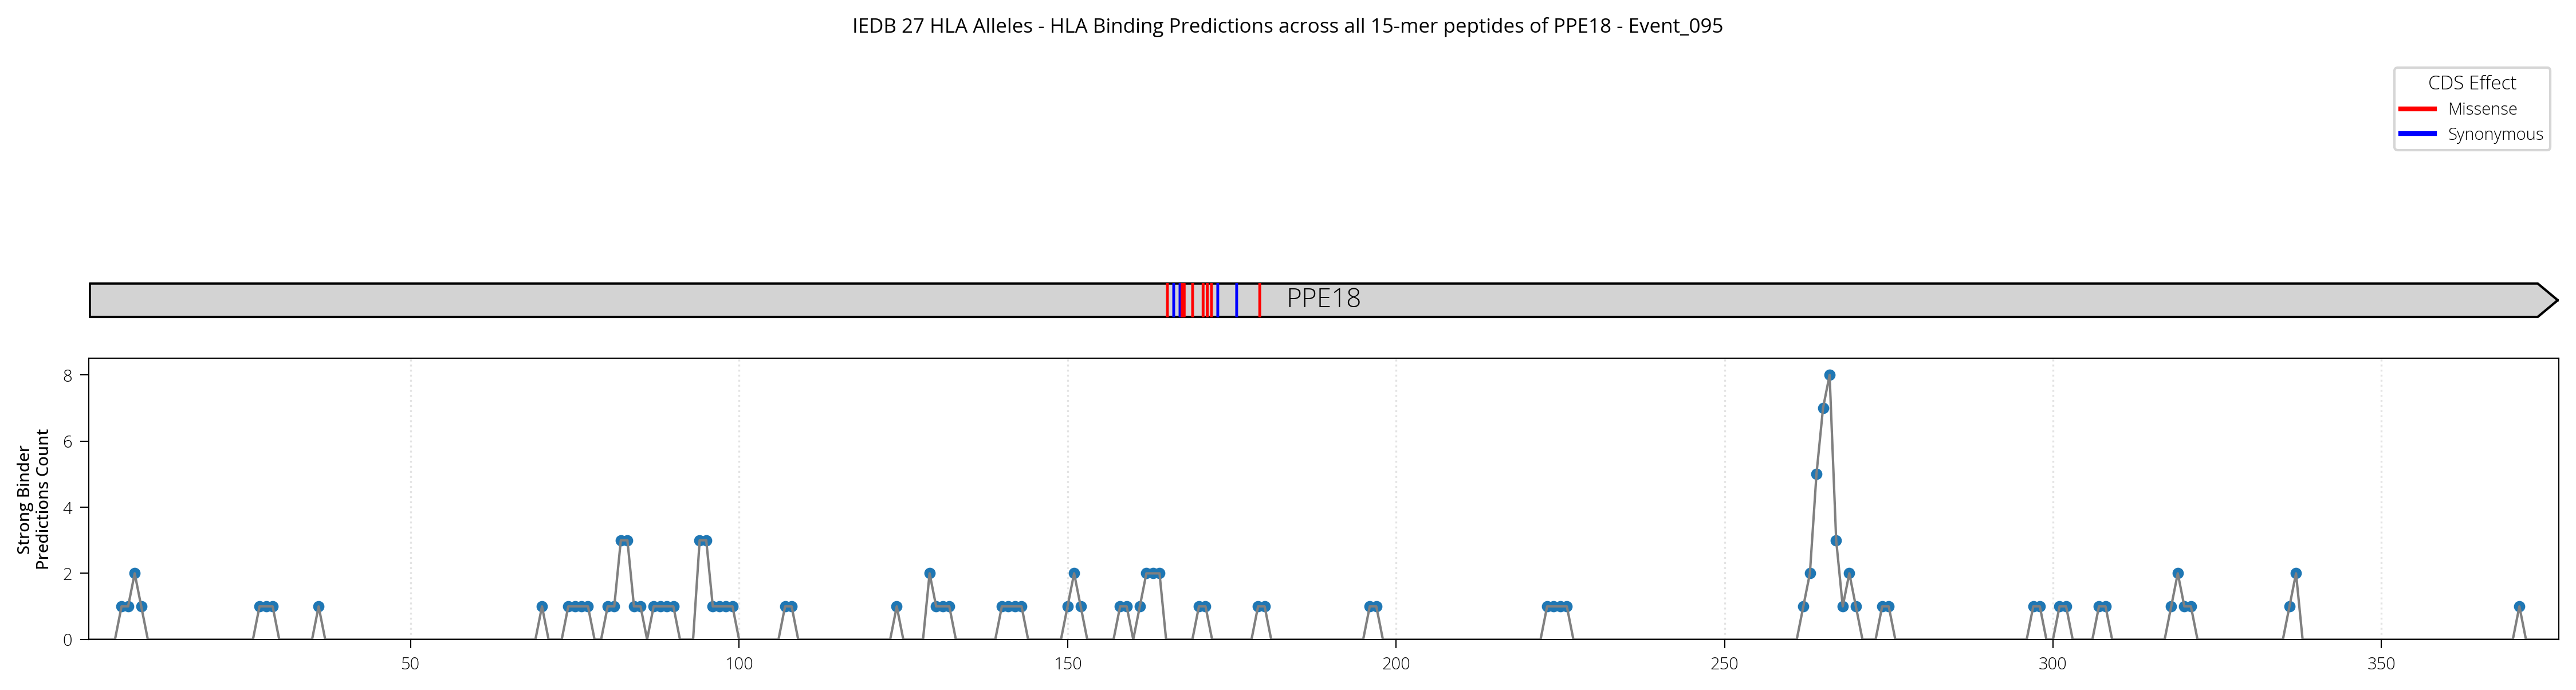

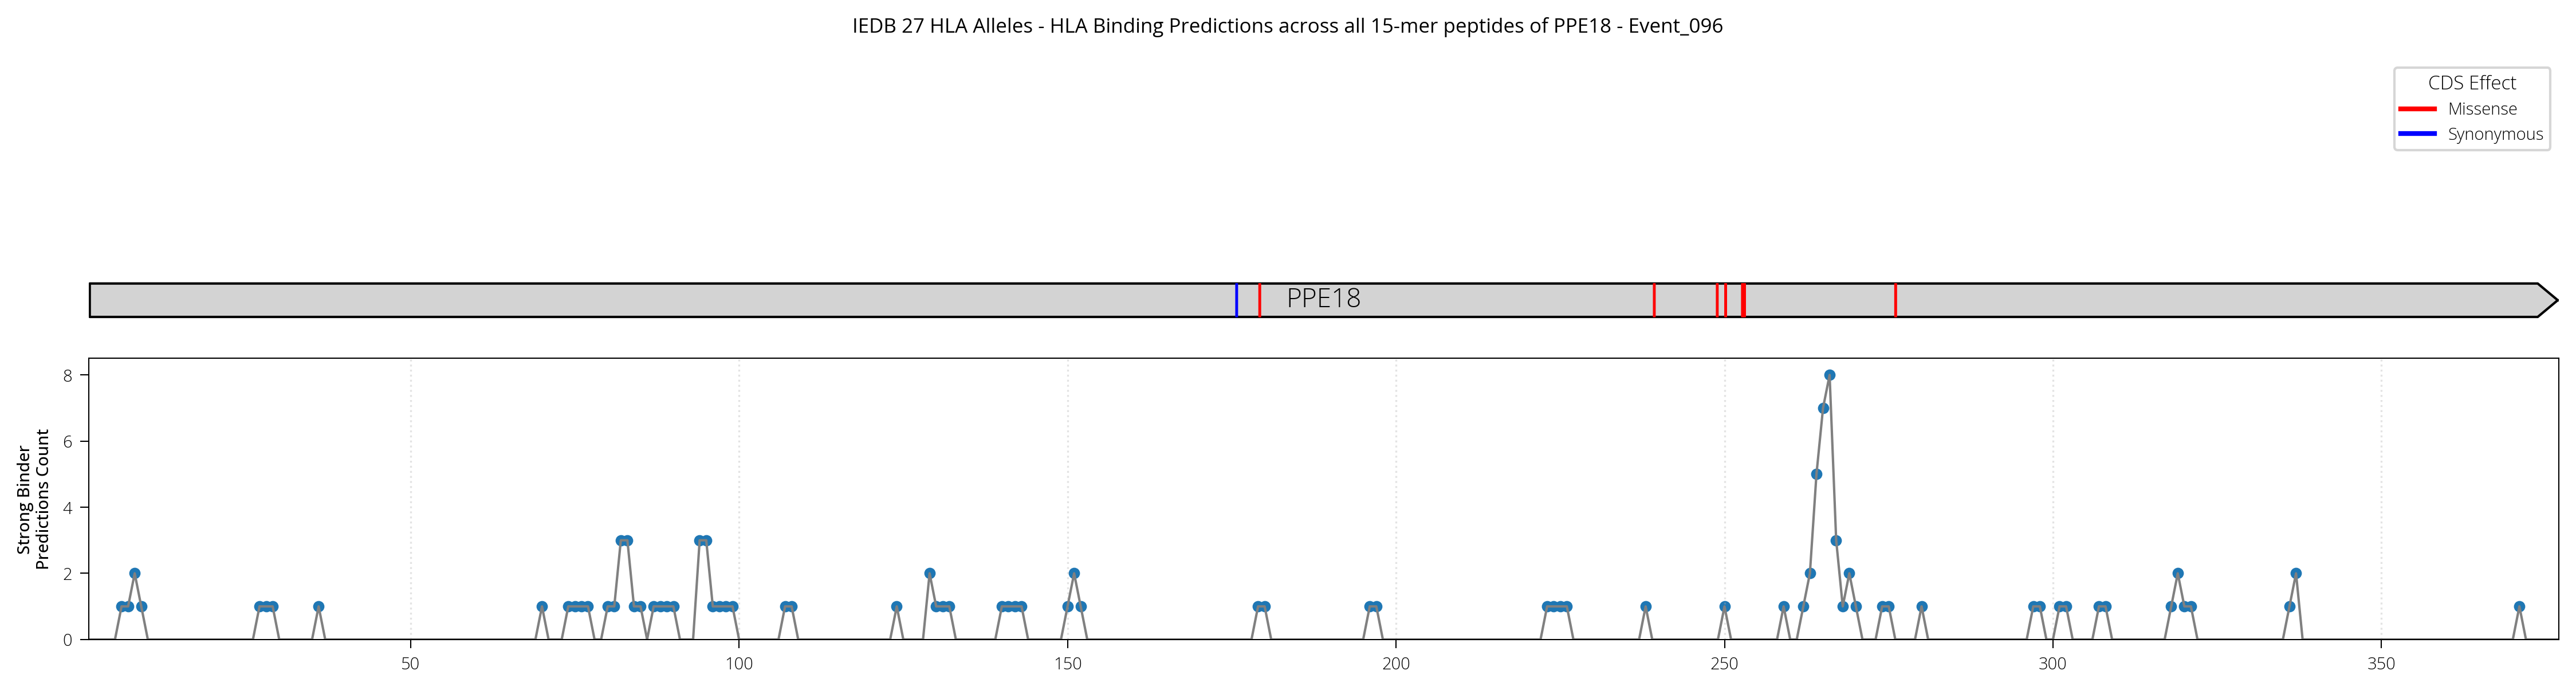

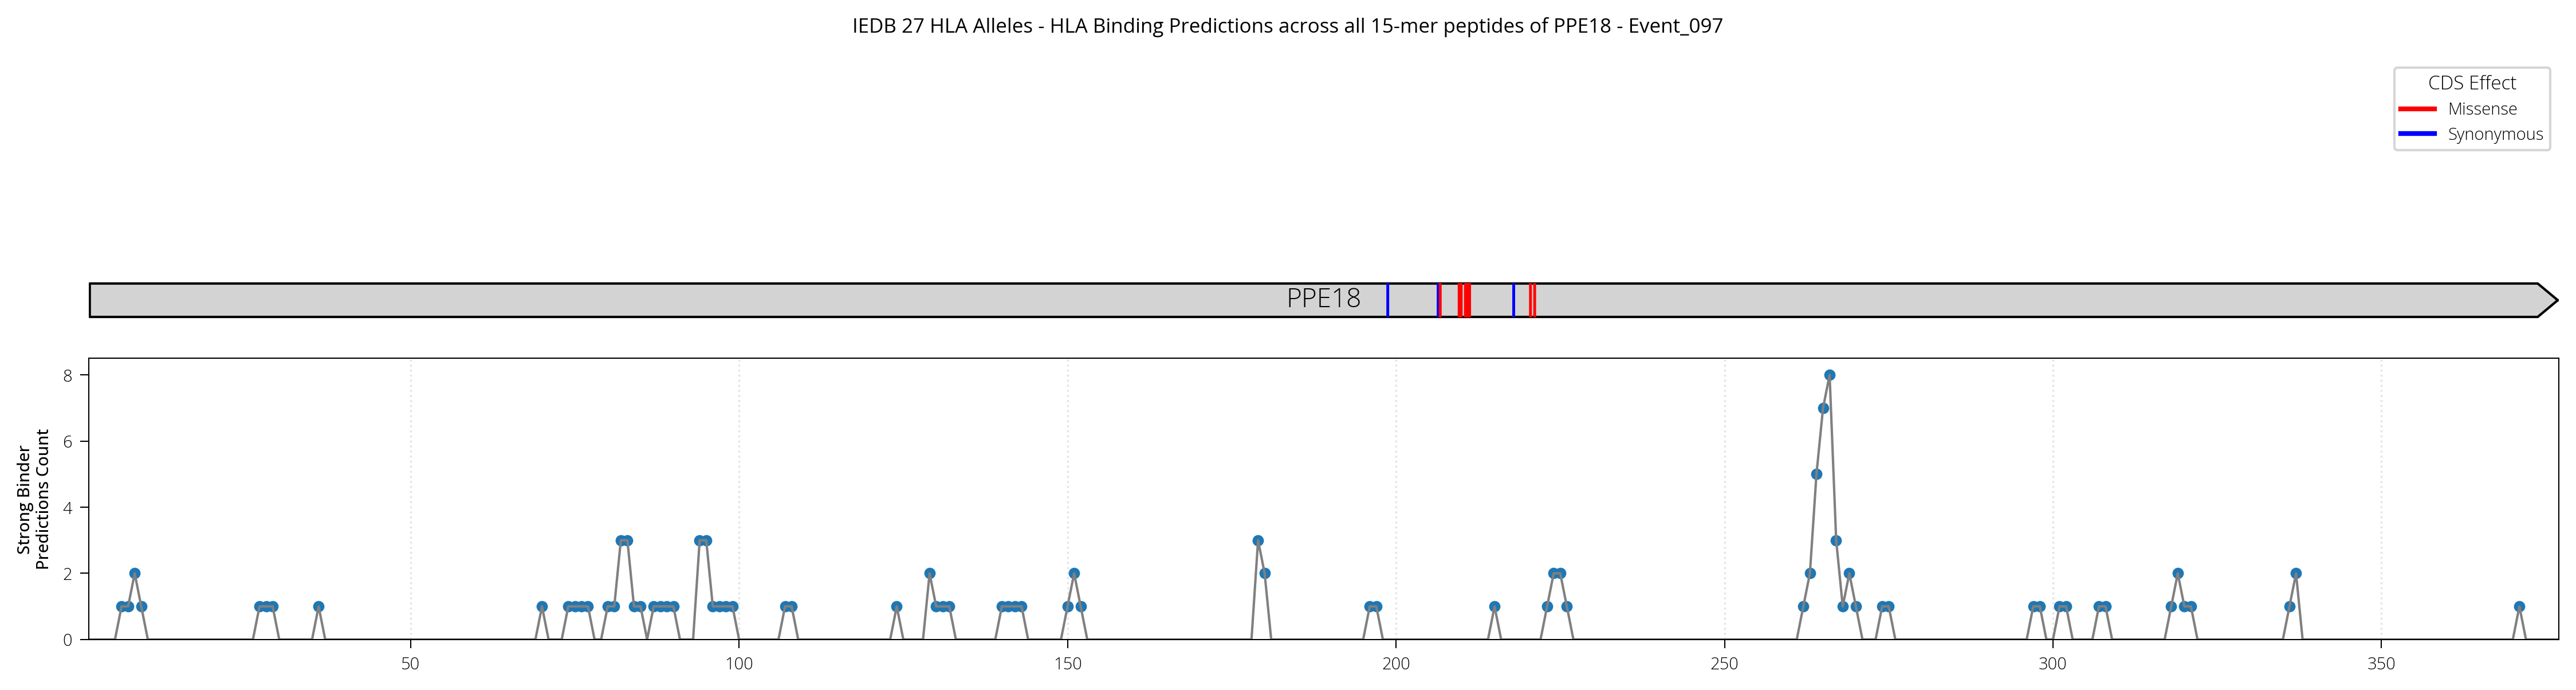

In [232]:

All_SeqAndEventIDs = ['H37Rv', 'Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']

for target_EventID in All_SeqAndEventIDs:

    GCE_Vs_HLABind_Baseline_E091_fig = plot_EventWiAnno_WiSBPred_Baseline_2panel(
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        in_EventID = target_EventID,
        in_GCEvents_All_DF = pGCE_DF,
        in_Gubbins_SNPs_DF = Gub_SNPs_V2_DF,
        i_MainResults_Dict = ResultsDict_IEDB_27A,
        Viz_Start = PPE18_Viz_Start,
        Viz_End = PPE18_Viz_End,
        in_ylim = (-5, 5),
        show_snp_labels=False,
        i_figsize = (15, 4),
        title = f"IEDB 27 HLA Alleles - HLA Binding Predictions across all 15-mer peptides of PPE18 - {target_EventID}",
    )

In [ ]:

All_SeqAndEventIDs = ['H37Rv', 'Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']

for target_EventID in All_SeqAndEventIDs:

    GCE_Vs_HLABind_Baseline_E091_fig = plot_EventWiAnno_WiSBPred_Baseline_3panel(
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        in_EventID = target_EventID,
        in_GCEvents_All_DF = pGCE_DF,
        in_Gubbins_SNPs_DF = Gub_SNPs_V2_DF,
        i_MainResults_Dict = ResultsDict_IEDB_27A,
        Viz_Start = PPE18_Viz_Start,
        Viz_End = PPE18_Viz_End,
        in_ylim = (-5, 5),
        show_snp_labels=False,
        i_figsize = (15, 6),
        title = f"IEDB 27 Allele Set - Strong Binding Predictions across all 15-mer peptides of PPE18 - {target_EventID}",
        allele_order = HLA2_IEDB_RefSet_27A,
    )


# Viz Direction of changes after GC Event in PPE18 - `AFN-EURO 7` HLA Alleles

In [ ]:
HLA_7Allele_outdir = Path("./PPE18.GCEs.AFNEURO_HLA7AlleleViz.Try3")
HLA_7Allele_outdir.mkdir(parents=True, exist_ok=True)

for i_eventid in ['Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']:
    print(i_eventid)

    fig2 = plot_event_WiSBChangeVsRef_2panel(
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        in_EventID               = i_eventid,
        in_GCEvents_All_DF       = pGCE_DF,
        in_Gubbins_SNPs_DF       = Gub_SNPs_V2_DF,
        i_MainResults_Dict       = ResultsDict_AFN_EURO_7A,
        Viz_Start                = PPE18_Viz_Start,
        Viz_End                  = PPE18_Viz_End,
        #in_ylim                  = in_ylim,
        show_snp_labels          = False,
        i_figsize = (10,4),
    )
    
    sns.despine()
    plt.show()

    fig2.savefig(f"{HLA_7Allele_outdir}/{target_EventID}.GCE_HLABindPredictionsViz.2Subplots.Anno.SB_Gain_Loss.AFNEURO_7Allele.V1.png", dpi=300, bbox_inches="tight")
    fig2.savefig(f"{HLA_7Allele_outdir}/{target_EventID}.GCE_HLABindPredictionsViz.2Subplots.Anno.SB_Gain_Loss.AFNEURO_7Allele.V1.svg", bbox_inches="tight")
    
    print("")

# Viz Direction of changes after GC Event in PPE18 - `IEDB 27` HLA Alleles

In [ ]:
HLA_27Allele_outdir = Path("./PPE18.GCEs.IEDB_HLA27AlleleViz.Try3")
HLA_27Allele_outdir.mkdir(parents=True, exist_ok=True)

for i_eventid in ['Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']:

    fig2 = plot_event_WiSBChangeVsRef_2panel(
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        in_EventID               = i_eventid,
        in_GCEvents_All_DF       = pGCE_DF,
        in_Gubbins_SNPs_DF       = Gub_SNPs_V2_DF,
        i_MainResults_Dict       = ResultsDict_IEDB_27A,
        Viz_Start                = PPE18_Viz_Start,
        Viz_End                  = PPE18_Viz_End,
        #in_ylim                  = in_ylim,
        show_snp_labels          = False,
        i_figsize = (10,4),
    )
    
    sns.despine()
    plt.show()

    fig2.savefig(f"{HLA_27Allele_outdir}/{target_EventID}.GCE_HLABindPredictionsViz.2Subplots.Anno.SB_Gain_Loss.IEDB_27Allele.V1.png", dpi=300, bbox_inches="tight")
    fig2.savefig(f"{HLA_27Allele_outdir}/{target_EventID}.GCE_HLABindPredictionsViz.2Subplots.Anno.SB_Gain_Loss.IEDB_27Allele.V1.svg", bbox_inches="tight")
    
    print("")

# Viz Direction of changes after GC Event in PPE18 - `AFN-EURO 7` HLA Alleles

In [ ]:
HLA_7Allele_outdir = Path("./PPE18.GCEs.AFNEURO_HLA7AlleleViz.Try3")
HLA_7Allele_outdir.mkdir(parents=True, exist_ok=True)


for i_eventid in ['Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']:

    fig2 = plot_event_WiSBChangeVsRef_2panel(
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        in_EventID               = i_eventid,
        in_GCEvents_All_DF       = pGCE_DF,
        in_Gubbins_SNPs_DF       = Gub_SNPs_V2_DF,
        i_MainResults_Dict       = ResultsDict_AFN_EURO_7A,
        Viz_Start                = PPE18_Viz_Start,
        Viz_End                  = PPE18_Viz_End,
        #in_ylim                  = in_ylim,
        show_snp_labels          = False,
        i_figsize = (10,4),
    )
    
    sns.despine()
    plt.show()

    fig2.savefig(f"{HLA_27Allele_outdir}/{target_EventID}.GCE_HLABindPredictionsViz.2Subplots.Anno.SB_Gain_Loss.IEDB_27Allele.V1.png", dpi=300, bbox_inches="tight")
    fig2.savefig(f"{HLA_27Allele_outdir}/{target_EventID}.GCE_HLABindPredictionsViz.2Subplots.Anno.SB_Gain_Loss.IEDB_27Allele.V1.svg", bbox_inches="tight")
    
    print("")

# Viz Event Mutations + SB Changes + HLA SB Heatmap - `IEDB 27` HLA Alleles

In [ ]:

All_Events = ['Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']

# All_Events = ['Event_094', ]

in_ylim = (-5, 5)

HLA_27Allele_outdir = Path("./PPE18.GCEs.IEDB_HLA27AlleleViz.Try3")
HLA_27Allele_outdir.mkdir(parents=True, exist_ok=True)

# --- storage for figures ---
figs_3_27Allele_panel = {}

for target_EventID in All_Events:

    # --- 3-panel figure ---
    fig3 = plot_event_WiSBChangeVsRef_3panel(
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        in_EventID               = target_EventID,
        in_GCEvents_All_DF       = pGCE_DF,
        in_Gubbins_SNPs_DF       = Gub_SNPs_V2_DF,
        i_MainResults_Dict       = ResultsDict_IEDB_27A,
        Viz_Start                = PPE18_Viz_Start,
        Viz_End                  = PPE18_Viz_End,
        in_ylim                  = in_ylim,
        show_snp_labels          = False,
        allele_order = HLA2_IEDB_RefSet_27A,
    )
    
    figs_3_27Allele_panel[target_EventID] = fig3

    fig3.savefig(f"{HLA_27Allele_outdir}/{target_EventID}.GCE_HLABindPredictionsViz.3Subplots.Anno.SB_Gain_Loss.SB_Heatmap.27Allele.V1.png", dpi=300, bbox_inches="tight")
    fig3.savefig(f"{HLA_27Allele_outdir}/{target_EventID}.GCE_HLABindPredictionsViz.3Subplots.Anno.SB_Gain_Loss.SB_Heatmap.27Allele.V1.svg", bbox_inches="tight")


# Viz Event Mutations + SB Changes + HLA SB Heatmap - `AFN-EURO 7` HLA Alleles

In [ ]:

# --- inputs you set ---
i_Symbol = "PPE18"
All_Events = ['Event_091', 'Event_092', 'Event_093', 'Event_094', 'Event_095', 'Event_096', 'Event_097']

# All_Events = ['Event_094', ]
in_ylim = (-5, 5)

HLA_7Allele_outdir = Path("./PPE18.GCEs.AFNEURO_HLA7AlleleViz.Try3")
HLA_7Allele_outdir.mkdir(parents=True, exist_ok=True)

# --- storage for figures ---
figs_3_7Allele_panel = {}

for target_EventID in All_Events:

    # --- 3-panel figure ---
    fig3 = plot_event_WiSBChangeVsRef_3panel(
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        in_EventID               = target_EventID,
        in_GCEvents_All_DF       = pGCE_DF,
        in_Gubbins_SNPs_DF       = Gub_SNPs_V2_DF,
        i_MainResults_Dict       = ResultsDict_AFN_EURO_7A,
        Viz_Start                = PPE18_Viz_Start,
        Viz_End                  = PPE18_Viz_End,
        in_ylim                  = in_ylim,
        show_snp_labels          = True,
        allele_order = HLA2_AFN_Euro_Set_7A,
    )
    figs_3_7Allele_panel[target_EventID] = fig3
    
    fig3.savefig(f"{HLA_7Allele_outdir}/{target_EventID}.GCE_HLABindPredictionsViz.3Subplots.Anno.SB_Gain_Loss.SB_Heatmap.7Allele.V1.png", dpi=300, bbox_inches="tight")
    fig3.savefig(f"{HLA_7Allele_outdir}/{target_EventID}.GCE_HLABindPredictionsViz.3Subplots.Anno.SB_Gain_Loss.SB_Heatmap.7Allele.V1.svg", bbox_inches="tight")


# Extras

In [ ]:
# --- 3-panel figure ---
fig_A = plot_event_WiSBChangeVsRef_3panel(
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    in_EventID               = "Event_094",
    in_GCEvents_All_DF       = pGCE_DF,
    in_Gubbins_SNPs_DF       = Gub_SNPs_V2_DF,
    i_MainResults_Dict       = ResultsDict_AFN_EURO_7A,
    Viz_Start                = PPE18_Viz_Start,
    Viz_End                  = PPE18_Viz_End,
    in_ylim                  = in_ylim,
    show_snp_labels          = True,
    allele_order = HLA2_AFN_Euro_Set_7A,
)

In [ ]:

fig_B = plot_EventWiAnno_WiSBPred_Baseline_3panel(
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    in_EventID = 'Event_094',
    in_GCEvents_All_DF = pGCE_DF,
    in_Gubbins_SNPs_DF = Gub_SNPs_V2_DF,
    i_MainResults_Dict = ResultsDict_AFN_EURO_7A,
    Viz_Start = PPE18_Viz_Start,
    Viz_End = PPE18_Viz_End,
    in_ylim = (-5, 5),
    show_snp_labels=False,
    i_figsize = (15, 6),
    title = f"AFN-EURO 7 Allele Set - HLA Binding Predictions across all 15-mer peptides of PPE18 - H37Rv",
    allele_order = HLA2_AFN_Euro_Set_7A,
)


In [ ]:

fig_C = plot_EventWiAnno_WiSBPred_Baseline_3panel(
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    in_EventID = 'H37Rv',
    in_GCEvents_All_DF = pGCE_DF,
    in_Gubbins_SNPs_DF = Gub_SNPs_V2_DF,
    i_MainResults_Dict = ResultsDict_AFN_EURO_7A,
    Viz_Start = PPE18_Viz_Start,
    Viz_End = PPE18_Viz_End,
    in_ylim = (-5, 5),
    show_snp_labels=False,
    i_figsize = (15, 6),
    title = f"AFN-EURO 7 Allele Set - HLA Binding Predictions across all 15-mer peptides of PPE18 - H37Rv",
    allele_order = HLA2_AFN_Euro_Set_7A,
)


# Viz top GC examples

In [ ]:
Gub_SNPs_V2_DF.shape

In [ ]:
Gub_SNPs_NSMutOnly_DF.shape


In [ ]:
Gub_SNPs_NSMutIn_pGCE_DF.shape

In [ ]:
Gub_SNPs_V2_DF.head()

In [ ]:
Gub_SNPs_NSMutIn_pGCE_DF.head()

In [ ]:
pGCE_DF.query("EventID == 'Event_094'")

# Viz each PPE18 event of interest

In [ ]:
FIG_X, AXS_X = process_and_visualize_event("Event_091",
                                            dictOf_FullKmerAnalysis_PerEvent,
                                            Gub_SNPs_V2_DF,
                                            pGCE_DF,
                                            Mtb_H37rv_Graphic_Record)

In [ ]:
FIG_X, AXS_X = process_and_visualize_event("Event_092",
                                            dictOf_FullKmerAnalysis_PerEvent,
                                            Gub_SNPs_V2_DF,
                                            pGCE_DF,
                                            Mtb_H37rv_Graphic_Record)

In [ ]:
FIG_X, AXS_X = process_and_visualize_event("Event_093",
                                            dictOf_FullKmerAnalysis_PerEvent,
                                            Gub_SNPs_V2_DF,
                                            pGCE_DF,
                                            Mtb_H37rv_Graphic_Record)

In [ ]:
FIG_X, AXS_X = process_and_visualize_event("Event_094",
                                            dictOf_FullKmerAnalysis_PerEvent,
                                            Gub_SNPs_V2_DF,
                                            pGCE_DF,
                                            Mtb_H37rv_Graphic_Record)

In [ ]:
FIG_X, AXS_X = process_and_visualize_event("Event_095",
                                            dictOf_FullKmerAnalysis_PerEvent,
                                            Gub_SNPs_V2_DF,
                                            pGCE_DF,
                                            Mtb_H37rv_Graphic_Record)

In [ ]:
FIG_X, AXS_X = process_and_visualize_event("Event_096",
                                            dictOf_FullKmerAnalysis_PerEvent,
                                            Gub_SNPs_V2_DF,
                                            pGCE_DF,
                                            Mtb_H37rv_Graphic_Record)

In [ ]:
FIG_X, AXS_X = process_and_visualize_event("Event_097",
                                            dictOf_FullKmerAnalysis_PerEvent,
                                            Gub_SNPs_V2_DF,
                                            pGCE_DF,
                                            Mtb_H37rv_Graphic_Record)